In [1]:
import os
from typing import Dict, List, Literal, Tuple, Optional
import logging
import math
import pickle
import time
import sys
import argparse

import json
from datetime import datetime
from pathlib import Path
import requests

import category_encoders as ce
from catboost import CatBoostRegressor
import kan
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pycatch22 import catch22_all
from scipy.interpolate import PchipInterpolator
from scipy.special import softmax

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

import xarray as xr
import zarr
import shutil
from glob import glob

from forecasting_module import TimeGPTForecaster, SARIMAXForecaster
from utils import ForecastUtils, Preds, make_sample_splits, read_params
from dataset_loaders import DatasetPreprocessor, ECGLoader, GermanyDataset, WeatherDataset
from lstm_network import LSTMModel, LSTMTrainer

import other_encoders.autoencoders as ae
import other_encoders.train_autoencoders as train_ae
from other_encoders.ts2vec_encoder import TS2VecEncoder
from other_encoders.custom_stuff import Decoder, MLPHead, ProjectionHead, TorchWrapper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Using device: cpu
Using device: cpu


In [2]:
"Setting up params"
interim_data_loc= "../interim_data"
encoders_folder = "other_encoders"

messager_params = read_params("messager.yaml")

params          = read_params("params2.yaml")
desired_dataset = params["basics"]["desired_dataset"]
num_runs        = params["basics"]["runs"]

latent_dims     = params[f"{desired_dataset}"]["latent_dim"]
batch_size      = params[f"{desired_dataset}"]["batch_size"]
train_epochs    = params[f"{desired_dataset}"]["train_epochs"]

predictor_lr       = params[f"{desired_dataset}"]["predictor_lr"]
predictor_epochs   = params[f"{desired_dataset}"]["predictor_epochs"]
predictor_dropout  = params[f"{desired_dataset}"]["predictor_dropout"]
predictor_hidden_sizes = params[f"{desired_dataset}"]["predictor_hidden_sizes"]

# method-specific params
AE_lr       = params["cellsup"]["AE_lr"]
weight_decay= params["cellsup"]["weight_decay"]
dropout     = params["cellsup"]["dropout"]
swav_iters  = params["cellsup"]["swav_iters"]
swav_temp   = params["cellsup"]["swav_temp"]
cluster_min = params["cellsup"]["clustering"]["cluster_min"]
cluster_max = params["cellsup"]["clustering"]["cluster_max"]


In [3]:
"""ECG dataset"""
if desired_dataset == "ecg":
    ECG_data_path = "../public_datasets/3D/ptb-xl-1.0.3"
    loader        = ECGLoader(ECG_data_path)
    X_ecg, y_ecg, sampling_rate, leads = loader.load_dataset(sampling="lr", target="diagnostic_superclass_multi",
                                                            segment_duration_sec=10.0, max_records=100, continuous_target=True)
    print(f"X shape: {X_ecg.shape}, X size (MB): {X_ecg.nbytes / 1024**2:.2f}")   # (patients, time, leads)
    print(f"y shape: {y_ecg.shape}, y size (MB): {y_ecg.nbytes / 1024**2:.4f}")  # (patients, conditions)


In [4]:
"""Argoverse dataset"""

def process_argoverse_parquet(scenario_parquet_path: str):
    """Convert Argoverse Parquet scenario to X (3D) and y (2D)
    Follows these rules:
        1. track_id != focal_track_id AND observed = true → include in X
        2. track_id  = focal_track_id AND observed = true → include in X
        3. track_id  = focal_track_id AND observed = false → include in y only
        4. track_id != focal_track_id AND observed = false → ignore"""
    df       = pd.read_parquet(scenario_parquet_path)
    focal_id = df['focal_track_id'].iloc[0]

    # Remove irrelevant rows (rule 4), but keep focal agent even if unobserved (rule 3)
    df = df[(df['observed'] == True) | (df['track_id'] == focal_id)]

    agent_past_list   = []
    focal_future_list = []

    for track_id, track_data in df.groupby('track_id'):
        xy_pos     = track_data[['position_x', 'position_y']].values
        headings   = track_data['heading'].values
        velocities = track_data[['velocity_x', 'velocity_y']].values
        is_observed= track_data['observed'].values

        agent_past   = []
        focal_future = []

        for t, obs in enumerate(is_observed):
            if obs:  # observed = True → goes into X
                agent_past.append([xy_pos[t][0], xy_pos[t][1],
                                   headings[t], velocities[t][0],
                                   velocities[t][1]])
            elif track_id == focal_id:  # observed = False and focal → goes into y
                focal_future.append(xy_pos[t])  # only x, y
        if agent_past:
            agent_past_list.append(np.array(agent_past))
        if focal_future and track_id == focal_id:
            focal_future_list = np.array(focal_future)

    # pad sequences to longest agent
    max_agent_len   = max(len(p) for p in agent_past_list)
    X_agents_padded = np.array([np.pad(p, ((0, max_agent_len-len(p)), (0,0)), 'constant') for p in agent_past_list])

    return X_agents_padded, np.array(focal_future_list)

if desired_dataset == "argoverse":
    argoverse_data_path = "../public_datasets/3D/argoverse_forecasting"
    folder_name    = "00a0ec58-1fb9-4a2b-bfd7-f4e5da7a9eff"
    file_name      = "scenario_00a0ec58-1fb9-4a2b-bfd7-f4e5da7a9eff.parquet"
    X_argo, y_argo = process_argoverse_parquet(f"{argoverse_data_path}/{folder_name}/{file_name}")
    print(X_argo.shape, y_argo.shape)


In [5]:
"""Weather dataset"""
if desired_dataset == "weather":
    dataset_folder = "../public_datasets/3D/weather_bench"
    variables_X    = ["2m_temperature", "10m_u_component_of_wind", "10m_v_component_of_wind"]
    variables_y    = ["mean_sea_level_pressure", "total_precipitation_6hr"]

    weather        = WeatherDataset(dataset_folder, variables_X, variables_y)
    X_xarr, y_xarr = weather.load_dataset()

    X_3d = weather.prepare_X_features(X_xarr, mode="3d") # (time, channels, lat*lon)
    X_3d = weather.reshape_for_ml(X_3d)                  # (lat*lon, time, channels)

    y_3d = weather.prepare_y_targets(y_xarr, mode="3d")  # (vars, lat, lon)
    y_2d = weather.flatten_y(y_3d)                       # (lat*lon, vars)

    X_weather, y_weather = X_3d, y_2d
    print(X_weather.shape, y_weather.shape)  # (2048, 92044, 3), (2048, 2)
    print(f"X_weather memory: {X_weather.nbytes/1024**2:.2f} MB")


In [6]:
"Germany catchment"
if desired_dataset == "germany_catchment":
    camels_root       = "../public_datasets/3D/camels_de"
    attributes_folder = camels_root
    timeseries_folder = os.path.join(camels_root, "timeseries")
    zarr_path         = os.path.join(camels_root, "camels_de_timeseries.zarr")

    if os.path.exists(zarr_path):
        X_germany = xr.open_zarr(zarr_path)["X"].values
    else:
        X_germany = GermanyDataset.load_X_from_scratch(timeseries_folder, zarr_path)
    y_germany = GermanyDataset.load_y_from_scratch(attributes_folder)

    print(f"X shape: {X_germany.shape} ({X_germany.nbytes / 1024**2:.2f} MB)")
    print(f"y shape: {y_germany.shape} ({y_germany.nbytes / 1024**2:.2f} MB)")


In [7]:
"""India dataset"""

if desired_dataset == "india_catchment":
    data_path      = "../public_datasets/3D/india_catchments"
    forcing_folder = "catchment_mean_forcings"
    clim_file      = "attributes_csv/camels_ind_clim.csv"

    # Load y (climate attributes)
    y_df    = pd.read_csv(f"{data_path}/{clim_file}")
    catchment_ids = y_df.iloc[:,0].astype(int).values
    y_india = y_df.iloc[:, 1:]

    # Load X (forcing time series)
    forcing_files    = sorted(os.listdir(f"{data_path}/{forcing_folder}"))
    X_list, file_ids = [], []

    for f in forcing_files:
        path = os.path.join(f"{data_path}/{forcing_folder}", f)
        df   = pd.read_csv(path)
        X_list.append(df.drop(columns=['year','month','day','pet(mm/day)']).values)
        file_ids.append(int(f.split('.')[0]))

    X       = np.stack(X_list, axis=0)
    order   = [file_ids.index(cid) for cid in catchment_ids]
    X_india = X[order]

    print("X_india shape:", X_india.shape, "y_india shape:", y_india.shape)


In [8]:
"""China Weather 2k data"""

if desired_dataset == "china_weather":
    dataset_location = "../public_datasets/3D/china_weather/weather2k.npy"
    # dataset_location = "/Users/fouadabiad/Downloads/weather2k.npy"
    china_data       = np.load(dataset_location, mmap_mode='r')  # read-only memory map
    china_data       = china_data.transpose(0,2,1) # (stations, timesteps, features)

    y_indices = [4, 5, 6, 7, 10] # [T, mnt, mxt, rh, ws], to remove
    y         = china_data[:, -1, y_indices] # last timestep
    mask      = np.ones(china_data.shape[2], dtype=bool)
    mask[y_indices] = False
    X         = china_data[:, :, mask]

    print(f"X shape: {X.shape} ({X.nbytes / 1024**2:.2f} MB)")  # (patients, conditions)
    print(f"y shape: {y.shape} ({y.nbytes / 1024**2:.2f} MB)")  # (patients, conditions)


In [9]:
"""[RUN ME] Preprocess dataset, as class"""

def load_ecg_data():
    ECG_data_path= "../public_datasets/3D/ptb-xl-1.0.3"
    loader       = ECGLoader(ECG_data_path)
    X, y, _, _   = loader.load_dataset(sampling="lr", target="diagnostic_superclass_multi",
                                       segment_duration_sec=200, max_records=2000,
                                       continuous_target=True)
    # segment_duration_sec: int = 150, max_records: int = 15000
    return X, y

def load_argoverse_data():
    argoverse_data_path = "../public_datasets/3D/argoverse_forecasting"
    folder_name = "00a0ec58-1fb9-4a2b-bfd7-f4e5da7a9eff"
    file_name   = "scenario_00a0ec58-1fb9-4a2b-bfd7-f4e5da7a9eff.parquet"
    return process_argoverse_parquet(f"{argoverse_data_path}/{folder_name}/{file_name}")

def load_weather_data():
    variables_X    = ["2m_temperature", "10m_u_component_of_wind", "10m_v_component_of_wind"]
    variables_y    = ["mean_sea_level_pressure", "total_precipitation_6hr"]
    dataset_folder = "../public_datasets/3D/weather_bench"
    weather        = WeatherDataset(dataset_folder, variables_X, variables_y)
    X_xarr, y_xarr = weather.load_dataset()
    X_3d = weather.prepare_X_features(X_xarr, mode="3d")
    X_3d = weather.reshape_for_ml(X_3d)
    y_3d = weather.prepare_y_targets(y_xarr, mode="3d")
    y_2d = weather.flatten_y(y_3d)
    return X_3d, y_2d

def load_india_data():
    data_path        = "../public_datasets/3D/india_catchments"
    forcing_folder   = "catchment_mean_forcings"
    clim_file        = "attributes_csv/camels_ind_clim.csv"
    y_df             = pd.read_csv(f"{data_path}/{clim_file}")
    catchment_ids    = y_df.iloc[:,0].astype(int).values
    y                = y_df.iloc[:, 1:]
    forcing_files    = sorted(os.listdir(f"{data_path}/{forcing_folder}"))
    X_list, file_ids = [], []
    for f in forcing_files:
        df = pd.read_csv(os.path.join(data_path, forcing_folder, f))
        X_list.append(df.drop(columns=['year','month','day','pet(mm/day)']).values)
        file_ids.append(int(f.split('.')[0]))
    X     = np.stack(X_list, axis=0)
    order = [file_ids.index(cid) for cid in catchment_ids]
    X     = X[order]
    return X, y

def load_germany_data():
    if os.path.exists(zarr_path):
        X = xr.open_zarr(zarr_path)["X"].values
    else:
        X = GermanyDataset.load_X_from_scratch(timeseries_folder, zarr_path)
    y = GermanyDataset.load_y_from_scratch(attributes_folder)
    if np.isnan(X).any():
        X = np.nan_to_num(X)
    if np.isnan(y).any():
        y = np.nan_to_num(y)
    return X, y

def load_china_data():
    dataset_location = "../public_datasets/3D/china_weather" #"/Users/fouadabiad/Downloads/weather2k.npy"
    file_name        = "weather2k.npy"
    china_data       = np.load(os.path.join(dataset_location, file_name), mmap_mode='r')  # read-only memory map
    china_data       = china_data.transpose(0,2,1) # (stations, timesteps, features)
    y_indices        = [4, 5, 6, 7, 10] # [T, mnt, mxt, rh, ws], to remove
    y                = china_data[:, -1, y_indices] # last timestep
    mask             = np.ones(china_data.shape[2], dtype=bool)
    mask[y_indices]  = False
    X                = china_data[:, :, mask]
    return X, y

def load_asm_data():
    X_3d  = np.load("../interim_data/X_3d.npy")
    y_asm = np.load("../interim_data/y_asm.npy")
    return X_3d, y_asm

def load_or_preprocess(desired_dataset: str,
                       random_seed, use_cache: bool = True) -> tuple[np.ndarray, ...]:
    """Load cached preprocessed dataset if available, otherwise preprocess and cache it."""
    page_frac, row_frac = downsampling_dict[desired_dataset]
    new_dir_name        = f"{desired_dataset}_{page_frac}_{row_frac}"
    save_dir            = f"{interim_data_loc}/{new_dir_name}"
    
    X_full, y_full = dataset_loaders_dict[desired_dataset]()

    if use_cache and os.path.exists(save_dir): # Load from cache
        print("Path exists, loading from cache:", save_dir)
        X_train        = np.load(f"{save_dir}/X_train.npz")['data']
        X_test         = np.load(f"{save_dir}/X_test.npz")['data']
        y_train_scaled = np.load(f"{save_dir}/y_train.npz")['data']
        y_test_scaled  = np.load(f"{save_dir}/y_test.npz")['data']

    else: # Preprocess fresh
        print("Path does not exist, preprocessing fresh:", save_dir)
        os.makedirs(save_dir, exist_ok=True)
        preprocessor = DatasetPreprocessor(page_frac=page_frac, row_frac=row_frac, test_size=0.2,
                                           random_seed=random_seed)
        X_train, X_test, y_train_scaled, y_test_scaled = preprocessor.fit_transform(X_full, y_full)

        # Save to cache
        np.savez_compressed(f"{save_dir}/X_train.npz", data=X_train.astype(np.float32))
        np.savez_compressed(f"{save_dir}/X_test.npz", data=X_test.astype(np.float32))
        np.savez_compressed(f"{save_dir}/y_train.npz", data=y_train_scaled.astype(np.float32))
        np.savez_compressed(f"{save_dir}/y_test.npz", data=y_test_scaled.astype(np.float32))
    return X_train, X_test, y_train_scaled, y_test_scaled #, X_small, y_train_small, y_test_small

dataset_loaders_dict = {
    "ecg":               load_ecg_data,
    "argoverse":         load_argoverse_data,
    "weather":           load_weather_data,
    "india_catchment":   load_india_data,
    "germany_catchment": load_germany_data,
    "china_weather":     load_china_data,
    "asm":               load_asm_data}

downsampling_dict = {"ecg":               (0.05, 0.08),
                     "argoverse":         (0.3, 0.1),
                     "weather":           (0.3, 0.01),
                     "india_catchment":   (0.3, 0.08),
                     "germany_catchment": (0.3, 0.015),
                     "china_weather":     (0.25, 0.05),
                     "asm":               (1, 0.005)} # measures every 0.05s

seed_range = np.arange(42, 42 + num_runs*num_runs)
seed       = int(np.random.choice(seed_range))

X_train, X_test, y_train_scaled, y_test_scaled = load_or_preprocess(desired_dataset, random_seed=seed, use_cache=False)
page_frac, row_frac = downsampling_dict[desired_dataset]

print(f"Random seed: {seed}")
print(f"X_train: {X_train.shape} ({X_train.nbytes/1024**2:.1f} MB), X_test: {X_test.shape} ({X_test.nbytes/1024**2:.1f} MB)")
print(X_train.mean(), X_test.mean(), y_train_scaled.mean(), y_test_scaled.mean())



Path does not exist, preprocessing fresh: ../interim_data/asm_1_0.005
Random seed: 51
X_train: (138, 80, 595) (50.1 MB), X_test: (34, 80, 595) (12.3 MB)
9.190066805227456e-18 0.16024619659216408 7.557960226141206e-17 0.003830739996921997


In [10]:
"[RUN ME] Setup step"
label_frac     = params["basics"]["label_frac"]
data_splitting = params["basics"]["data_splitting"]

n_samples = int(label_frac * len(X_train))
indices   = np.random.permutation(len(X_train))
X_L       = X_train[indices[:n_samples]]
y_L       = y_train_scaled[indices[:n_samples]]

if data_splitting == "normal": # [normal] keep ALL X, and part of y
    X_U       = X_train[indices[n_samples:]] # optional unlabeled
    y_U       = y_train_scaled[indices[n_samples:]] # needed for semi-supervised
    X_tensor  = torch.tensor(X_train, dtype=torch.float32, device=device).reshape(len(X_train), -1)
elif data_splitting == "reduced_data": # [less data] take % of ALL dataset only
    X_U       = np.empty((0, *X_L.shape[1:]), dtype=X_L.dtype)
    y_U       = np.empty((0, *y_L.shape[1:]), dtype=y_L.dtype)
    X_tensor  = torch.tensor(X_L, dtype=torch.float32, device=device).reshape(len(X_L), -1)

X_train = X_L
y_train_scaled = y_L
X_small = np.concatenate([X_train, X_test], axis=0)
y_small = np.concatenate([y_train_scaled, y_test_scaled], axis=0)
print(f"{data_splitting=}, {label_frac=}")

if params["run_console"]["timevae"] == True:
    os.makedirs(interim_data_loc, exist_ok=True)
    timevae_file_name = f"{desired_dataset}_frac{label_frac}_{page_frac}_{row_frac}"
    np.savez_compressed(f"../../timeVAE/data/{timevae_file_name}.npz", data=np.array(X_small, dtype=np.float32))
    print(f"Saved {timevae_file_name} to TimeVAE repo")

print(np.mean(X_train), np.mean(X_test))
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}, X_small (TimeVAE): {X_small.shape}")


data_splitting='reduced_data', label_frac=1
1.0427524011581059e-17 0.16024619659216408
X_train: (138, 80, 595), X_test: (34, 80, 595), X_small (TimeVAE): (172, 80, 595)


In [11]:
"[RUN ME] functions for Headsup/cellsup"

# class CellsupHelpers:

# class GeneralHelpers:

def make_augmentations(X: torch.Tensor,  augment_type: str, device, scale_factor: float = 0.1) -> torch.Tensor:
    """Apply a chosen augmentation to a 3D time series batch.
    - X: Input array of shape (batch, time, channels).
    - augment_type: Type of augmentation to apply.
    - scale_factor: Magnitude factor controlling strength of augmentation.
    returns augmented array with the same shape as X (except cropping)"""
    batches, timesteps, cols = X.shape
    X = X.to(device)
    if augment_type == "jitter":
        noise = torch.randn_like(X) * float(scale_factor)
        return X + noise
    if augment_type == "scaling":
        # per-sample, per-channel scaling factor
        factor = torch.randn(batches, 1, cols, device=device) * scale_factor + 1.0
        return X * factor
    if augment_type == "mag_warp":
        mag = torch.empty(batches, 1, 1, device=device).uniform_(1 - scale_factor, 1 + scale_factor)
        return X * mag
    if augment_type == "time_warp":
        B, T, C = X.shape
        # random smooth warp along time
        tt = torch.linspace(-1, 1, T, device=device).unsqueeze(0).repeat(B, 1)  # (B,T)
        warp = tt + scale_factor * torch.randn(B, T, device=device)  # jittered time coords
        warp = warp.clamp(-1, 1)

        # make grid: need 2 coords (x,y), here y is dummy zero
        grid = torch.stack([warp, torch.zeros_like(warp)], dim=-1)  # (B,T,2)
        grid = grid.unsqueeze(2)  # (B,T,1,2)

        X_reshaped = X.permute(0, 2, 1).unsqueeze(-1)  # (B,C,T,1)
        X_warped   = F.grid_sample(X_reshaped, grid, mode="bilinear",
                                padding_mode="border", align_corners=True)
        return X_warped.squeeze(-1).permute(0, 2, 1)  # back to (B,T,C)
    if augment_type == "permutation":
        X_aug = torch.empty_like(X)
        # per-sample random segmentation + permutation
        for b in range(batches):
            n_segs   = int(torch.randint(2, 5, (1,)).item())
            pts      = np.linspace(0, timesteps, n_segs + 1, dtype=int)
            perm     = np.random.permutation(n_segs)
            pieces   = [X[b, pts[i]:pts[i+1], :] for i in perm]
            X_aug[b] = torch.cat(pieces, dim=0)
        return X_aug
    if augment_type == "cropping":
        keep    = int(timesteps * (1 - scale_factor))
        start   = int(torch.randint(0, timesteps - keep + 1, (1,)).item())
        cropped = X[:, start:start + keep, :]
        # pad or trim to keep shape (B, T, C)
        if cropped.shape[1] < timesteps:
            pad = torch.zeros(batches, timesteps - cropped.shape[1], cols, device=device)
            return torch.cat([cropped, pad], dim=1)
        else:
            return cropped
    if augment_type == "masking":
        mask  = (torch.rand(batches, timesteps, cols, device=device) < scale_factor)
        X_aug = X.clone()
        X_aug[mask] = 0.0
        return X_aug
    if augment_type == "drift":
        drift = torch.linspace(0, float(scale_factor), timesteps, device=device).view(1, timesteps, 1)
        sign  = 1.0 if torch.rand(1, device=device) < 0.5 else -1.0
        return X + sign * drift
    raise ValueError(f"Unknown augment type {augment_type}")

def _interpolate_to_length(x: torch.Tensor, target_len: int) -> torch.Tensor:
    """Interpolate along time dimension to match target length."""
    b, t, c = x.shape
    x = x.permute(0, 2, 1).unsqueeze(-1)  # (B, C, T, 1)
    x = F.interpolate(x, size=(target_len, 1), mode="linear", align_corners=True)
    return x.squeeze(-1).permute(0, 2, 1)  # (B, target_len, C)

def make_two_views_augmentation(X: torch.Tensor, device, scale: float = 0.1):
    aug_types = ["jitter", "scaling", "masking", "cropping", "time_warp"]
    a1, a2 = np.random.choice(aug_types, 2, replace=False)
    v1, v2 = make_augmentations(X, a1, device, scale), make_augmentations(X, a2, device, scale)
    # if cropping shortened, interpolate back
    if v1.shape[1] != X.shape[1]:
        v1 = _interpolate_to_length(v1, X.shape[1])
    if v2.shape[1] != X.shape[1]:
        v2 = _interpolate_to_length(v2, X.shape[1])
    return v1, v2

def compute_byol_loss(p_online: torch.Tensor, z_target: torch.Tensor) -> torch.Tensor:
    """Minimal BYOL loss: MSE between online predictions and target projections, adapted from the BYOL paper.
    Args:
        p_online: prediction from online network (batch, dim)
        z_target: projection from target network (batch, dim)
    Returns: Scalar loss"""
    # normalize for stability (optional but standard)
    p_online = F.normalize(p_online, dim=1)
    z_target = F.normalize(z_target, dim=1)

    z_target = z_target.detach() # stop gradients on target
    return 2 - 2 * (p_online * z_target).sum(dim=1).mean() # loss = MSE = 2 - 2 * cosine_sim

# to remove (maybe)
def update_target_encoding_ema(target_encoder: torch.nn.Module, online_encoder: torch.nn.Module, decay: float):
    """In-place EMA update of target params: target = decay*target + (1-decay)*online"""
    # return decay * target_encoding + (1 - decay) * new_values

    with torch.no_grad():
        for t_param, o_param in zip(target_encoder.parameters(), online_encoder.parameters()):
            t_param.data.mul_(decay).add_(o_param.data * (1.0 - decay))

def get_loss_weights(step, warmup_steps, max_steps): #can have schedule as linear OR cosine
    if step < warmup_steps:
        return dict(recon=1.0, contrast=0.0, pred=0.0)
    else:
        t = (step - warmup_steps) / (max_steps - warmup_steps)
        return dict(
            recon=max(0.1, 1.0 - t),   # decay recon to 0.1
            contrast=min(0.5, t),      # grow contrast to 0.5
            pred=min(1.0, t))           # grow pred to 1.0

def schedule_learning_rate(step, max_steps, lr_0=1e-3, lr_end=1e-5, schedule_type="linear"):
    """Compute learning rate at given step with linear or cosine decay from lr0 to lr_end."""
    if schedule_type == "linear":
        return lr_0 - (lr_0 - lr_end) * (step / max_steps)
    elif schedule_type == "cosine":
        cosine_decay = 0.5 * (1 + math.cos(math.pi * step / max_steps))
        return lr_end + (lr_0 - lr_end) * cosine_decay
    else:
        raise ValueError(f"Unknown schedule type: {schedule_type}")

def set_all_seeds(seed: int):
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def nt_xent_loss(z1, z2, temperature=0.5):
    """Normalized temperature-scaled cross entropy loss"""
    B   = z1.size(0)   # dynamically set batch size
    z1  = F.normalize(z1, dim=1)
    z2  = F.normalize(z2, dim=1)
    z   = torch.cat([z1, z2], dim=0)  # (2B, dim)

    sim = torch.matmul(z, z.T) / temperature
    mask= torch.eye(2*B, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -9e15)

    labels = torch.cat([torch.arange(B) + B, torch.arange(B)], dim=0).to(z.device)
    return F.cross_entropy(sim, labels)

# to remove
def infer_catboost_multioutput(model: Optional[MultiOutputRegressor],
                               X_test: np.ndarray,
                               non_constant_idx: List[int],
                               n_targets: int,
                               fallback_values: Optional[np.ndarray] = None) -> np.ndarray:
    """Inference for multi-output CatBoost with support for constant targets."""
    y_pred = np.zeros((len(X_test), n_targets), dtype=float)

    if model is not None:
        preds = model.predict(X_test)
        y_pred[:, non_constant_idx] = preds

    if fallback_values is not None:
        for i in range(n_targets):
            if i not in non_constant_idx:  # constant column
                y_pred[:, i] = fallback_values[i]
    return y_pred

class LogRunResults:
    @staticmethod
    def log_run_in_csv(params: dict, results: dict, log_file: Path):
        """Logs a single experiment run.
        params: dictionary of all hyperparameters
        results: dictionary of evaluation metrics
        log_file: path to parquet or csv file"""
        row = {**params, **results, "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M")}
        
        if log_file.exists():
            df = pd.read_parquet(log_file) if log_file.suffix==".parquet" else pd.read_csv(log_file)
            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
        else:
            df = pd.DataFrame([row])
        
        if log_file.suffix==".parquet":
            df.to_parquet(log_file, index=False)
        else:
            df.to_csv(log_file, index=False)

    @staticmethod
    def log_run_json(params: dict, results_dict: dict, top_metrics: dict, log_file: Path):
        """Logs one experiment run as a JSON object with auto-incremented run_id.
        'results' contains both fraction results and top-level metrics, rounded to 4 decimals"""
        if log_file.exists():
            with open(log_file, "r") as f:
                run_id = sum(1 for _ in f) + 1
        else:
            run_id = 1

        # Merge fraction results and top-level metrics
        merged_results = {**{str(k): round(v, 4) for k, v in results_dict.items()},
                        **{k: round(v, 4) for k, v in top_metrics.items()}}
        run_data = {"run_id": run_id,
                     **params,
                     "results": merged_results,
                     "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M")}
        log_file.parent.mkdir(parents=True, exist_ok=True)
        with open(log_file, "a") as f:
            f.write(json.dumps(run_data, indent=4) + "\n")




In [12]:
"""TimeVAE"""
if params["run_console"]["timevae"] == True:
    from tensorflow.keras.models import load_model
    sys.path.append("/Users/fouadabiad/Projects/timeVAE/src") # folder in parent repo containing vae/
    from vae.vae_base import Sampling
    from vae_pipeline import run_vae_pipeline

    model_name           = "timeVAE"
    timevae_encoder_name = f"timevae_encoder_{timevae_file_name}.keras"
    timevae_encoder_loc  = f"{interim_data_loc}/timevae/{timevae_encoder_name}"

    if 1>2:#os.path.exists(timevae_encoder_loc):
        print(f"Found existing TimeVAE model at {timevae_encoder_loc}, loading...")
    else:
        print(f"No existing TimeVAE model found at {timevae_encoder_loc}, training new model...")
        start = time.time()
        run_vae_pipeline(timevae_file_name, model_name) # running main timeVAE code
        end   = time.time()
        print(f"Training time for {train_epochs} epochs: {(end - start):.2f} s")

    timevae_model = load_model(timevae_encoder_loc, compile=False)
    print(type(timevae_model))

    z_mean_train, z_log_var_train, z_train = timevae_model.predict(X_train)
    z_mean_test, z_log_var_test, z_test    = timevae_model.predict(X_test)

    # z_train     = np.load(f"{interim_data_loc}/z_train_{desired_dataset}.npy")
    # z_valid     = np.load(f"{interim_data_loc}/z_valid_{desired_dataset}.npy")
    # z_test      = np.load(f"{interim_data_loc}/z_test_{desired_dataset}.npy")
    # z_train     = np.load(f"{interim_data_loc}/z_train_germany_catchment_0.3_0.015.npy")
    # z_valid     = np.load(f"{interim_data_loc}/z_valid_germany_catchment_0.3_0.015.npy")
    # z_test      = np.load(f"{interim_data_loc}/z_test_germany_catchment_0.3_0.015.npy")

    if 'z_valid' in locals():
        print(f"z_train: {z_train.shape}, z_valid: {z_valid.shape}, z_train_val: {z_train_val.shape}, z_test: {z_test.shape}")
    else:
        z_valid     = np.empty((0, z_train.shape[1]), dtype=z_train.dtype)
        z_train_val = np.concatenate([z_train, z_valid], axis=0) #concat z_train and val to = y shape
    print(f"y_train_scaled: {y_train_scaled.shape}, y_test_scaled: {y_test_scaled.shape}")

    # # Train NN predictor
    # predictor_lr      = params["timevae"]["predictor_lr"]
    # predictor_epochs  = params["timevae"]["predictor_epochs"]
    # predictor_dropout = params["timevae"]["predictor_dropout"]
    # predictor_hidden_sizes = params["timevae"]["predictor_hidden_sizes"]

    # nn_predictor = MLPHead(input_dim=z_train.shape[1], output_dim=y_train_scaled.shape[1],
    #                        hidden_sizes=predictor_hidden_sizes, lr=predictor_lr,
    #                        epochs=predictor_epochs, dropout=predictor_dropout, device=device)
    # nn_predictor.train(z_train_val, y_train_scaled, z_test, y_test_scaled)
    # nn_rmse = nn_predictor.evaluate(z_test, y_test_scaled)

    timevae_losses = Preds.evaluate_models_on_dataset(z_train_val, y_train_scaled,
                                                      z_test, y_test_scaled)
    print(f"dataset: {desired_dataset}, method: timevae")
    print( "    RMSE      | LinReg | CatBoost | RForest")# | NN
    print(f"& Z (timevae) & {timevae_losses[0]:.4f} & {timevae_losses[1]:.4f}  & {timevae_losses[2]:.4f}")# & {nn_rmse:.4f} \\ ")


In [13]:
"""TS2Vec"""
if params["run_console"]["ts2vec"] == True:
    z_pooling_method   = params["ts2vec"]["z_pooling_method"]
    ts2vec_hidden_dims = params["ts2vec"]["ts2vec_hidden_dims"]
    ts2vec_depth       = params["ts2vec"]["ts2vec_depth"]

    # 1️⃣ Fit TS2Vec
    ts2vec_encoder = TS2VecEncoder(z_pooling=z_pooling_method, device=device, patience=50)  # keep patience
    start = time.time()
    ts2vec_encoder.fit(X_train, hidden_dims=ts2vec_hidden_dims, output_dims=latent_dims,
                       depth=ts2vec_depth, batch_size=batch_size, n_epochs=train_epochs)
    end   = time.time()
    print(f"Training time for {train_epochs} epochs: {(end - start):.2f} s")

    if ts2vec_encoder._stop_early:
        print("Training stopped early due to no improvement.")
    z_train = ts2vec_encoder.encode(X_train)
    z_test  = ts2vec_encoder.encode(X_test)

    # # 2️⃣ Train NN predictor
    # nn_predictor = MLPHead(input_dim=z_train.shape[1], output_dim=y_train_scaled.shape[1],
    #                     hidden_sizes=predictor_hidden_sizes, lr=predictor_lr,
    #                     epochs=predictor_epochs, dropout=predictor_dropout, device=device)
    # nn_predictor.train(z_train, y_train_scaled, z_test, y_test_scaled)
    # nn_rmse = nn_predictor.evaluate(z_test, y_test_scaled)

    # ====== plain predictors ======
    ts2vec_losses = Preds.evaluate_models_on_dataset(z_train, y_train_scaled, z_test, y_test_scaled)
    print(f"dataset: {desired_dataset}, method: ts2vec")
    print("    RMSE   | LinReg | CatBoost | RForest | NN")
    print(f"& Z (ts2vec) & {ts2vec_losses[0]:.4f} & {ts2vec_losses[1]:.4f} & {ts2vec_losses[2]:.4f}")# & {nn_rmse:.4f} \\ ")


In [14]:
"""MOMENT"""
if params["run_console"]["moment"] == True:
    from momentfm import MOMENTPipeline
    model_type        = params["moment"]["model_type"] # options: classification (= regression), repres_learning
    model_name        = params["moment"]["model_name"] #"MOMENT-1-large"
    reload_model      = params["moment"]["reload_model"]

    if reload_model == True:
        if model_type == "classification": # classification/regression
            classes_in_y = len(np.unique(y_train_scaled))
            moment_model = MOMENTPipeline.from_pretrained(f"AutonLab/{model_name}", 
                                                        model_kwargs={'task_name': 'classification',
                                                                      'n_channels': X_train.shape[2], 'num_class': classes_in_y},)
        elif model_type == "repres_learning": # representation learning
            moment_model = MOMENTPipeline.from_pretrained(f"AutonLab/{model_name}", 
                                                          model_kwargs={"task_name": "embedding"},)
        print(f"Doing {model_type} with {model_name}!")
        moment_model.init()
        moment_model.eval()

    # 1️⃣ Encode train and test separately (NOTE: model expects data as [batch, channels, seq_len] )
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
    X_test_tensor  = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)

    with torch.no_grad():
        train_outputs = moment_model(x_enc=X_train_tensor)
        test_outputs  = moment_model(x_enc=X_test_tensor)

    z_train = train_outputs.embeddings.cpu().numpy()
    z_test  = test_outputs.embeddings.cpu().numpy()

    if model_type == "classification":
        z_train = z_train.mean(axis=1)  # or max(axis=1)
        z_test  = z_test.mean(axis=1)
    print(X_train.shape, z_train.shape)

    # 2️⃣ Train downstream NN predictor
    # nn_predictor = MLPHead(input_dim=z_train.shape[1], output_dim=y_train_scaled.shape[1],
    #                         hidden_sizes=predictor_hidden_sizes, lr=predictor_lr,
    #                         epochs=predictor_epochs, dropout=predictor_dropout, device=device)
    # nn_predictor.train(z_train, y_train_scaled, z_test, y_test_scaled)
    # nn_rmse = nn_predictor.evaluate(z_test, y_test_scaled)

    # ====== plain predictors ======
    moment_losses = Preds.evaluate_models_on_dataset(z_train, y_train_scaled, z_test, y_test_scaled)
    print(f"dataset: {desired_dataset}, method: moment")
    print( "    RMSE   | LinReg | CatBoost | RForest | NN")
    print(f"& Z ({model_type}) & {moment_losses[0]:.4f} & {moment_losses[1]:.4f} & {moment_losses[2]:.4f}")# \
        #   & {nn_rmse:.4f} \\\\ ")


In [15]:
"params for running Headsup"
# ===== TS2Vec params ======
z_pooling_method   = "mean"
ts2vec_hidden_dims = 16 # units in each layer (> than latent dim)
ts2vec_latent_dims = 8 # latent dim
ts2vec_depth       = 3 # num layers
ts2vec_batch_size  = 32
ts2vec_epochs      = 5 #20
ts2vec_patience    = 25

# predictor_lr           = 0.009
# predictor_epochs       = 50
predictor_dropout      = 0.05
predictor_hidden_sizes = [32, 48, 64] # latent to y output

# ===== Headsup pretrain/train params =====
set_all_seeds(42)
batch_size_pretrain  = 16
batch_size_train     = 16

decoder_hidden_dims  = [16, 64, 128]
projection_dim       = 16
lr_pretrain          = 1e-3
lr_train             = 1e-4 #1e-3

patience_pretrain    = 15
patience_train       = 6

train_epochs_pretrain= 8
train_epochs_finetune= 3 # aim for 30-50
warmup_frac_pretrain = 0.05 # 5-10% of pretrain steps
warmup_frac_train    = 0.05 # 5-10% of train steps

weights_pretrain     = {"recon":0.1,"contrast":1.0}
weights_train_100    = {"pred": 1.0, "recon": 0.5, "contrast": 0.5} # 100 is the label_fraction
weights_train_50     = {"pred": 1.0, "recon": 0.1, "contrast": 0.1} # 50 is the label_fraction
weights_train_other  = {"pred": 2.0, "recon": 0.0, "contrast": 0.0}

label_fractions = [1.0, 0.5, 0.25, 0.1]

# === augmentations ===
aug1          = "jitter"
aug1_strength = 0.2
aug2          = "mag_warp"
aug2_strength = 0.1

# === files and names ===
TS2VEC_ENCODER_NAME   = f"ts2vec_encoder_{desired_dataset}_{ts2vec_hidden_dims}hiddendims_{ts2vec_depth}layers_{ts2vec_latent_dims}dims_{ts2vec_batch_size}batch_{ts2vec_epochs}epoch.pkl"
TS2VEC_ENCODER_FILE   = os.path.join(interim_data_loc, "ts2vec_encoders", TS2VEC_ENCODER_NAME)

PRETRAIN_ENCODER_NAME = (f'pretrained_encoder_{desired_dataset}_lr{lr_pretrain}_epochs{train_epochs_pretrain}_batch{batch_size_pretrain}'
                         f'_enc{ts2vec_latent_dims}dims_{ts2vec_depth}layers_dec{decoder_hidden_dims}_proj{projection_dim}'
                         f'_warmup{warmup_frac_pretrain}_frac{"_".join(map(str, label_fractions))}.pth')
PRETRAIN_ENCODER_FILE = os.path.join(interim_data_loc, "pretrained_encoders", PRETRAIN_ENCODER_NAME)

EMBEDDING_FILE_NAME   = (f"cached_embeddings_{desired_dataset}_{desired_dataset}_lr{lr_train}_epochs{train_epochs_finetune}_batch{batch_size_train}"
                         f'_enc{ts2vec_latent_dims}dims_{ts2vec_depth}layers_dec{decoder_hidden_dims}_proj{projection_dim}'
                         f'_warmup{warmup_frac_train}.pth')
EMBEDDING_CACHE_FILE  = os.path.join(interim_data_loc, "trained_encoders", EMBEDDING_FILE_NAME)


In [16]:
"""Cellsup functions"""
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def get_latent_from_encoder(encoder, X, device="cpu") -> np.ndarray:
    """Return latent z for any encoder type with shape (N, latent_dim)."""
    if isinstance(encoder, nn.Module):
        X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
        if X_tensor.ndim > 2:
            X_tensor = X_tensor.reshape(len(X_tensor), -1)
        if type(encoder).__name__ == "VAE":
            mu, _ = encoder.encode(X_tensor)
            z     = mu.detach().cpu().numpy()
        else: # AE / DAE: return latent layer instead of reconstruction
            z = encoder.encode(X_tensor).detach().cpu().numpy()
    elif type(encoder).__name__ == "TS2VecEncoder":
        z = encoder.encode(X)  # returns (N, T, latent_dim)
        z = z.mean(axis=1)      # temporal pooling
    else:
        raise ValueError(f"Unknown encoder type: {type(encoder).__name__}")
    return z

def bootstrap_sample(X, sample_frac=0.8):
    """Draw a bootstrap sample from X with replacement. Used to approximate sampling variability when the
    true population dist is unknown
        - X: Input array of shape (n_samples, ...).
        - sample_frac: Fraction of samples to draw (default=0.8).
        - returns: bootstrap sample array of shape (int(n_samples * sample_frac), ...)"""
    idx = np.random.choice(len(X), size=int(len(X)*sample_frac), replace=True)
    return X[idx]

def train_ae_with_bootstraps(model, X_train, num_epochs=5, lr=1e-3, sample_frac=0.8, weight_decay=0.0, device="cpu"):
    """Train AE with bootstrap sampling."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    X_tensor_full = torch.tensor(X_train, dtype=torch.float32, device=device).reshape(len(X_train), -1)
    
    for epoch in range(num_epochs):
        X_boot = bootstrap_sample(X_train, sample_frac)
        X_tensor_boot = torch.tensor(X_boot, dtype=torch.float32, device=device).reshape(len(X_boot), -1)
        optimizer.zero_grad()
        X_recon = model(X_tensor_boot)
        loss = F.mse_loss(X_recon, X_tensor_boot)
        loss.backward()
        optimizer.step()
    return model

def flatten_X(X: np.ndarray) -> np.ndarray:
    """Flatten 2D or 3D X to (N, D) for torch feeding."""
    if X.ndim > 2:
        return X.reshape(len(X), -1)
    return X

def get_latent_tensor(encoder, X, train_encoder=False, device="cpu") -> torch.Tensor:
    """Return 2D tensor (N, latent_dim) for SupHead/CatBoost."""
    if train_encoder and isinstance(encoder, nn.Module):
        encoder.train()
        X_tensor = torch.tensor(flatten_X(X), dtype=torch.float32, device=device)
        z = encoder.encode(X_tensor)
        if isinstance(z, tuple):  # for VAE
            z = z[0]
        if z.ndim > 2:
            z = z.mean(dim=1)
        return z
    else:
        z = get_latent_from_encoder(encoder, X, device=device)
        if z.ndim > 2:
            z = z.mean(axis=1)
        return torch.tensor(z, dtype=torch.float32, device=device) if isinstance(z, np.ndarray) else z

def _get_orthogonality_penalty(encoders, X_batch, device):
    """Compute sum of squared correlations between encoder latent batches.
       encoders: dict[name]->encoder; X_batch: same X for all encoders (or views applied externally)"""
    z_list = []
    for enc in encoders.values():
        z = get_latent_tensor(enc, X_batch, train_encoder=False, device=device)  # (B, d)
        z = z - z.mean(0)
        # l2-normalize per feature to reduce scale issues
        z = z / (z.std(0) + 1e-8)
        z_list.append(z)  # torch tensors
    # compute pairwise dot products of mean latent vectors (or flattened)
    penalty = 0.0
    for i in range(len(z_list)):
        for j in range(i+1, len(z_list)):
            # compute covariance between latent dims (sum of squared correlations)
            C = (z_list[i].T @ z_list[j]) / z_list[i].shape[0]  # (d_i, d_j)
            penalty = penalty + (C ** 2).sum()
    return penalty

def train_sup_head_per_encoder(encoder, X_L, y_L, X_test, y_test, dropout, train_encoder=True,
                               all_encoders=None, reg_ortho=5e-4,   # tune this
                               device="cpu", epochs=5, hidden_sizes=[64,32]):
    """Train a small supervised MLP head on top of EACH encoder's z.
    Args:
        encoder: AE/VAE/DAE/TS2Vec encoder
        X_L, y_L: labelled training data
        X_test, y_test: test data
        train_encoder: whether to finetune encoder
        device: "cpu"/"cuda"
        epochs: training epochs
        hidden_sizes: list of hidden layer sizes
    Returns:
        rmse on test set"""
    encoder_type  = type(encoder).__name__
    train_encoder = train_encoder and isinstance(encoder, nn.Module) and encoder_type in ["FlexibleAutoencoder","AE","VAE","DenoisingAE"]

    encoder.eval()
    z_sample   = get_latent_tensor(encoder, X_L[:2], train_encoder=False, device=device)
    latent_dim = z_sample.shape[-1]
    sup_head   = SupHead(latent_dim, y_L.shape[1], hidden_sizes, dropout).to(device)
    params     = list(sup_head.parameters())
    if train_encoder:
        params += list(encoder.parameters())
        # =========
        for other_name, other_enc in all_encoders.items():
            if other_enc is not encoder:
                params += list(other_enc.parameters())
        # =========
    optimizer  = torch.optim.AdamW(params, lr=1e-3)
    y_tensor   = torch.tensor(y_L, dtype=torch.float32, device=device)
    
    for _ in range(epochs):
        sup_head.train()
        if train_encoder:
            encoder.train()
        z      = get_latent_tensor(encoder, X_L, train_encoder=train_encoder, device=device)
        y_pred = sup_head(z)
        loss   = F.mse_loss(y_pred, y_tensor)

        # ====== add orthogonality penalty across encoder ensemble (very cheap)
        if all_encoders is not None and reg_ortho > 0:
            # use a small random batch for speed
            idx       = np.random.choice(len(X_L), size=min(128, len(X_L)), replace=False)
            X_batch   = X_L[idx]
            ortho_pen = _get_orthogonality_penalty(all_encoders, X_batch, device=device)
            loss      = loss + reg_ortho * ortho_pen
        # ======

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    sup_head.eval()
    with torch.no_grad():
        z_test      = get_latent_tensor(encoder, X_test, train_encoder=False, device=device)
        y_pred_test = sup_head(z_test).cpu().numpy()
    return root_mean_squared_error(y_test, y_pred_test)

def train_sup_heads_joint(encoders_dict, X_train, y_train, X_val, y_val,
                          hidden_sizes=[64], lr=0.001, epochs=50, device="cpu",
                          reg_ortho=1e-3, train_encoders=True, batch_size=128):
    """Jointly train supervised heads for each encoder with optional finetuning and orthogonality.
    Updates encoders_dict in-place with finetuned encoders.
    Returns dict of RMSE metrics."""
    metrics = {}
    for name, encoder in encoders_dict.items():
        rmse = train_sup_head_per_encoder(
            encoder, X_train, y_train, X_val, y_val,
            dropout=0.1, train_encoder=train_encoders,
            all_encoders=encoders_dict, reg_ortho=reg_ortho,
            device=device, epochs=epochs, hidden_sizes=hidden_sizes)
        metrics[name] = rmse
    return metrics

def train_and_eval_catboost(X_train, y_train, X_test, y_test):
    """Train MultiOutput CatBoost, handle constant columns, return predictions and RMSE."""
    mask       = [i for i in range(y_train.shape[1]) if not np.all(y_train[:, i] == y_train[0,i])]
    const_vals = {i: y_train[0,i] for i in range(y_train.shape[1]) if i not in mask}

    y_pred = np.zeros_like(y_test)
    if mask:
        model = MultiOutputRegressor(CatBoostRegressor(iterations=500, learning_rate=0.1, depth=4,
                                                       random_seed=42, verbose=0))
        model.fit(X_train[:, :], y_train[:, mask])
        y_pred[:, mask] = model.predict(X_test)

    for i, v in const_vals.items():
        y_pred[:, i] = v

    rmse = root_mean_squared_error(y_test, y_pred)
    return y_pred, rmse

def assign_encoder_weights(encoders_dict: dict, sup_head_rmse, weight_encoding_method: str = "uniform"):
    """Compute normalized encoder weights using one of three methods:
        - "uniform": equal weights
        - "inverse_rmse": proportional to 1/RMSE
        - "softmax": softmax over 1/RMSE"""
    if weight_encoding_method == "uniform":
        encoder_weights = {name: 1.0 for name in encoders_dict.keys()}
        total           = sum(encoder_weights.values())
        encoder_weights = {k: v / total for k, v in encoder_weights.items()}
    elif weight_encoding_method == "inverse_rmse": # RMSE-based weights: better encoders get higher weight
        encoder_weights = {name: 1/rmse for name, rmse in sup_head_rmse.items()}
        total           = sum(encoder_weights.values())
        encoder_weights = {k: v/total for k,v in encoder_weights.items()}
    elif weight_encoding_method == "softmax": # softmax-based weights
        inv_rmse        = np.array([1/r for r in sup_head_rmse.values()])
        weights_softmax = np.exp(inv_rmse) / np.sum(np.exp(inv_rmse))
        encoder_weights = {name: w for name, w in zip(sup_head_rmse.keys(), weights_softmax)}
    return encoder_weights

def target_distribution(q: np.ndarray) -> np.ndarray:
    """Sharpen soft assignments q -> p (DEC target distribution)."""
    weight = (q ** 2) / q.sum(axis=0)
    return (weight.T / weight.sum(axis=1)).T


class SupHead(nn.Module):
    """Small supervised head: maps latent z -> target y"""
    def __init__(self, input_dim: int, output_dim: int, hidden_sizes=[64, 32], dropout=1e-3):
        super().__init__()
        layers, prev_dim = [], input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

class Cellsup:
    """Ensemble clustering across multiple encoders."""
    def __init__(self, encoders_dict: dict, n_clusters: int = 5, device: str = "cpu",
                 cluster_assignment: str = "soft", cluster_metric: str = "ch", random_state: int = 42):
        self.encoders_dict      = encoders_dict
        self.n_clusters         = n_clusters
        self.device             = device
        self.cluster_assignment = cluster_assignment
        self.cluster_prob_matrix= None
        self.cluster_metric     = cluster_metric.lower()
        self.rng                = np.random.RandomState(random_state)
        self.clusterers         = {}  # stores KMeans per encoder

    def score_clusters(self, z: np.ndarray, labels: np.ndarray) -> float:
        """Return clustering quality score depending on metric."""
        try:
            if self.cluster_metric == "silhouette":
                return silhouette_score(z, labels)
            elif self.cluster_metric == "ch":
                return calinski_harabasz_score(z, labels)
            elif self.cluster_metric == "db":
                return -davies_bouldin_score(z, labels)  # negate so higher = better
            else:
                raise ValueError(f"Unknown metric {self.cluster_metric}")
        except ValueError:
            return -1  # invalid clustering (e.g. only 1 cluster found)

    def _fit_best_kmeans_for_latent(self, z: np.ndarray, cluster_range: tuple[int,int], n_restarts: int = 5) -> KMeans:
        """Fit KMeans on latent `z` using separate best-k selection per encoder.
        1) Tune best cluster number k (average score over n_restarts)
        2) Fit KMeans with n_restarts for that k to select the best initialization
        Args:
            z (np.ndarray): Latent representations, shape (N, D)
            cluster_range (tuple[int,int]): Min and max+1 clusters to try
            n_restarts (int): KMeans restarts per candidate cluster number and for final best k
        Returns:
            KMeans: Fitted KMeans model with optimal cluster number"""
        # Step 1: pick best k using mean score across n_restarts
        best_score, best_k = -np.inf, None
        for k in range(cluster_range[0], cluster_range[1]):
            scores = []
            for _ in range(n_restarts):
                kmeans_try = KMeans(n_clusters=k, random_state=self.rng.randint(0,10000)).fit(z)
                scores.append(self.score_clusters(z, kmeans_try.labels_))
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score, best_k = mean_score, k

        # Step 2: fit KMeans with multiple restarts for that best k
        best_score_restart, best_kmeans = -np.inf, None
        for _ in range(n_restarts):
            kmeans = KMeans(n_clusters=best_k, random_state=self.rng.randint(0,10000)).fit(z)
            score  = self.score_clusters(z, kmeans.labels_)
            if score > best_score_restart:
                best_score_restart, best_kmeans = score, kmeans

        print(f"Selected cluster size: {best_kmeans.n_clusters}")
        return best_kmeans

    def fit_kmeans_on_encoder_latents(self, X: np.ndarray, encoder_weights: dict = None,
                                      cluster_range=(4,16)):
        """Fit KMeans on each encoder's latent space, select the best cluster number per encoder,
        and concatenate per-encoder cluster features into a single matrix.
        Cluster features:
        - 'soft': standardized softmax of negative distances (approx. probabilities)
        - 'hard': one-hot cluster labels
        Optional encoder weights scale each encoder's features.
        Args:
            X (np.ndarray): Input data, shape (N, D) or (N, T, D)
            encoder_weights (dict, optional): Encoder name → scalar weight (normalized)
            cluster_range (tuple, optional): Range of clusters to try (min, max+1)
        Returns:
            self: Adds `self.clusterers` (dict of fitted KMeans) and 
                `self.prob_matrix` (concatenated cluster features, shape (N, sum_k))"""
        cluster_features_list = []

        if encoder_weights is not None: # normalize encoder weights if provided
            total = sum(encoder_weights.values())
            encoder_weights = {k: v / total for k, v in encoder_weights.items()}

        for name, encoder in self.encoders_dict.items():
            z = get_latent_from_encoder(encoder, X, device=self.device)
            kmeans               = self._fit_best_kmeans_for_latent(z, cluster_range, n_restarts=5)
            self.clusterers[name]= kmeans
            labels               = kmeans.labels_

            # --- compute soft/hard assignments ---
            if self.cluster_assignment == "soft":
                distances        = kmeans.transform(z)
                cluster_features = softmax(-distances, axis=1)
                # standardize to prevent dominance by encoders with more clusters
                cluster_features = (cluster_features - cluster_features.mean(axis=0)) / (cluster_features.std(axis=0) + 1e-8)
            else: # hard
                cluster_features = np.eye(kmeans.n_clusters)[labels]

            if encoder_weights is not None: # apply encoder weight
                cluster_features *= encoder_weights.get(name, 1.0)
            cluster_features_list.append(cluster_features)

        # concatenate horizontally across encoders
        self.cluster_prob_matrix = np.concatenate(cluster_features_list, axis=1)  # (N, sum_k)
        return self

    def apply_kmeans_to_new_data(self, X: np.ndarray) -> np.ndarray:
        """Apply EXISTING fitted KMeans models to new data X and return concat cluster features
        Cluster features:
        - 'soft': softmax of negative distances
        - 'hard': one-hot labels
        Args: X (np.ndarray): Input data, shape (N, D) or (N, T, D)
        Returns: np.ndarray: Concatenated cluster features, shape (N, sum_k)"""
        cluster_features_list = []
        for name, encoder in self.encoders_dict.items():
            z      = get_latent_from_encoder(encoder, X, device=self.device)
            kmeans = self.clusterers[name]
            labels = kmeans.predict(z)
            if self.cluster_assignment == "soft":
                distances        = kmeans.transform(z) # (n_samples, n_clusters)
                cluster_features = softmax(-distances, axis=1) # convert distance → probability
            elif self.cluster_assignment == "hard":
                cluster_features = np.eye(kmeans.n_clusters)[labels]
            cluster_features_list.append(cluster_features)
        # return np.mean(cluster_features_list, axis=0)
        # fix
        return np.concatenate(cluster_features_list, axis=1)  # (N, E*K)

    def assign_pseudo_labels(self, X_labeled, y_labeled, X_unlabeled, confidence_thresh=0.5):
        """Assign pseudo-labels to unlabeled data using KMeans cluster averages."""
        pseudo_labels_all = []

        if X_unlabeled is None or len(X_unlabeled) == 0:
            return np.zeros((0, y_labeled.shape[1]))

        for name, kmeans in self.clusterers.items():
            z_L      = get_latent_from_encoder(self.encoders_dict[name], X_labeled, device=device)
            z_U      = get_latent_from_encoder(self.encoders_dict[name], X_unlabeled, device=device)
            labels_L = kmeans.predict(z_L)
            labels_U = kmeans.predict(z_U)

            # cluster -> mean label map
            cluster_to_mean = {c: y_labeled[labels_L == c].mean(axis=0) for c in np.unique(labels_L)}
            fallback = y_labeled.mean(axis=0)  # use global mean instead of NaNs
            y_pseudo = np.stack([cluster_to_mean.get(c, fallback) for c in labels_U], axis=0)
            # ==============
            # # compute soft assignment probabilities
            # distances  = kmeans.transform(z_U)
            # soft_probs = softmax(-distances, axis=1)
            # max_probs  = soft_probs.max(axis=1)
            # # mask low-confidence pseudo-labels
            # mask = max_probs >= confidence_thresh
            # y_pseudo[~mask] = np.nan  # mark low-confidence samples as NaN
            # ==============
            pseudo_labels_all.append(y_pseudo)

        # combine across encoders
        y_pseudo_final = np.nanmean(np.stack(pseudo_labels_all, axis=0), axis=0)
        return y_pseudo_final

    # to replace the above one
    def assign_ensemble_pseudo_labels(self, X_labeled, y_labeled, X_unlabeled,
                                      cluster_sizes=(4, 6, 8), encoder_weights=None):
        """Assign pseudo-labels by averaging across multiple cluster sizes and encoders.
        Args:
            X_labeled (np.ndarray): labeled features
            y_labeled (np.ndarray): labels
            X_unlabeled (np.ndarray): unlabeled features
            cluster_sizes (tuple[int]): cluster numbers to ensemble
            encoder_weights (dict, optional): encoder name -> scalar weight
        Returns:
            np.ndarray: pseudo-labels for unlabeled data (shape: n_samples, y_dim)"""
        all_pseudo_labels = []

        for name, encoder in self.encoders_dict.items():
            z_L = get_latent_from_encoder(encoder, X_labeled, device=self.device)
            z_U = get_latent_from_encoder(encoder, X_unlabeled, device=self.device)

            for k in cluster_sizes:
                kmeans = KMeans(n_clusters=k, random_state=42).fit(z_L)
                labels_L = kmeans.predict(z_L)
                labels_U = kmeans.predict(z_U)

                cluster_to_mean = {c: y_labeled[labels_L == c].mean(axis=0) for c in np.unique(labels_L)}
                fallback = y_labeled.mean(axis=0)
                y_pseudo = np.stack([cluster_to_mean.get(c, fallback) for c in labels_U], axis=0)

                # optional encoder weight
                if encoder_weights is not None:
                    y_pseudo *= encoder_weights.get(name, 1.0)
                all_pseudo_labels.append(y_pseudo)

        # ensemble average across encoders and cluster sizes
        return np.nanmean(np.stack(all_pseudo_labels, axis=0), axis=0)

    # consider removing
    def refine_clusters_DEC(self, X, encoder, name: str, n_iters: int = 10, lr: float = 1e-4):
        """Refine encoder so that latent z matches clusters better (DEC refinement).
        Assumes encoder is a torch.nn.Module."""
        optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)

        # get cluster centers from fitted KMeans
        # centers = torch.tensor(self.clusterers['AE_8'].cluster_centers_, dtype=torch.float32)
        centers = torch.tensor(self.clusterers[name].cluster_centers_, dtype=torch.float32)

        for _ in range(n_iters):
            z = get_latent_tensor(encoder, X, train_encoder=True, device=self.device)  # (n, d)

            # soft assignment of z to centers
            q = torch.softmax(-torch.cdist(z, centers.to(z.device)), dim=1)

            # sharpened target distribution
            p = torch.tensor(target_distribution(q.detach().cpu().numpy()), device=z.device)

            # KL divergence loss
            loss = F.kl_div(q.log(), p, reduction="batchmean")

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # to replace with SWAV
    def deepcluster_step(self, X, n_iters=1, refine_encoder=False, lr=1e-3, epochs_finetune=5):
        """Iterative DeepCluster-style for lightweight modular pseudo-labels."""
        for _ in range(n_iters):  # iterate DeepCluster steps
            for name, encoder in self.encoders_dict.items():
                z = get_latent_from_encoder(encoder, X, device=self.device)

                # --- fit KMeans ---
                kmeans = self._fit_best_kmeans_for_latent(z, cluster_range=(4,16))
                self.clusterers[name] = kmeans

                # --- soft cluster assignments ---
                distances = kmeans.transform(z)
                cluster_features = softmax(-distances, axis=1)
                cluster_features = (cluster_features - cluster_features.mean(axis=0)) / (cluster_features.std(axis=0)+1e-8)

                # --- optional lightweight refinement ---
                if refine_encoder:
                    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)
                    centers   = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32, device=self.device)
                    for _ in range(epochs_finetune):
                        # compute z fresh every step
                        z_tensor = get_latent_tensor(encoder, X, train_encoder=True, device=self.device)
                        q        = torch.softmax(-torch.cdist(z_tensor, centers), dim=1)
                        p        = torch.tensor(target_distribution(q.detach().cpu().numpy()), device=q.device)
                        loss     = F.kl_div(q.log(), p, reduction="batchmean")
                        optimizer.zero_grad()
                        loss.backward()  # no retain_graph
                        optimizer.step()
                # store/concatenate cluster features across encoders
                if self.cluster_prob_matrix is None:
                    self.cluster_prob_matrix = cluster_features
                else:
                    self.cluster_prob_matrix = np.concatenate([self.cluster_prob_matrix, cluster_features], axis=1)
    
    # remove
    def swav_soft_assign(self, X, cluster_range=(4,16), temperature=0.1):
        """Compute SWAV-style normalized soft cluster assignments for all encoders.
        Each encoder gets a moving-target distribution for pseudo-labels.
        Args:
            X (np.ndarray): input features
            cluster_range (tuple[int]): min/max clusters to try for KMeans
            temperature (float): softmax temperature to sharpen assignments
        Returns:
            dict: encoder name -> soft pseudo-label matrix (n_samples, sum_k)"""
        swav_features = {}
        for name, encoder in self.encoders_dict.items():
            z = get_latent_from_encoder(encoder, X, device=self.device)
            kmeans = self._fit_best_kmeans_for_latent(z, cluster_range)
            self.clusterers[name] = kmeans
            distances = kmeans.transform(z)  # (N, k)
            q = softmax(-distances / temperature, axis=1)
            q = q / q.sum(axis=1, keepdims=True)
            swav_features[name] = q
        return swav_features

    def deepcluster_step_swav(self, X, n_iters=1, cluster_range=(4,16), temperature=0.1, refine_encoder=False, lr=1e-3, epochs_finetune=5):
        """DeepCluster step using SWAV-style soft cluster assignments.
        Replaces hard pseudo-labels with normalized moving-target distributions.
        Args:
            X (np.ndarray): input features
            n_iters (int): number of DeepCluster iterations
            cluster_range (tuple[int]): min/max clusters for KMeans
            temperature (float): softmax temperature
            refine_encoder (bool): whether to fine-tune encoder toward clusters
            lr (float): learning rate for encoder refinement
            epochs_finetune (int): fine-tune steps per iteration"""
        if X is None or len(X) == 0:
            print("[DeepCluster] Skipping: no data provided.")
            self.cluster_prob_matrix = np.zeros((0, 0))
            return
        for _ in range(n_iters):
            for name, encoder in self.encoders_dict.items():
                # --- fit KMeans ---
                z      = get_latent_from_encoder(encoder, X, device=self.device)
                kmeans = self._fit_best_kmeans_for_latent(z, cluster_range)
                self.clusterers[name] = kmeans

                # --- SWAV-style soft assignment ---
                distances = kmeans.transform(z)
                q = softmax(-distances / temperature, axis=1)
                q = q / q.sum(axis=1, keepdims=True)  # normalize

                # store features
                if self.cluster_prob_matrix is None:
                    self.cluster_prob_matrix = q
                else:
                    self.cluster_prob_matrix = np.concatenate([self.cluster_prob_matrix, q], axis=1)

                # --- optional lightweight refinement ---
                if refine_encoder:
                    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)
                    centers   = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32, device=self.device)
                    for _ in range(epochs_finetune):
                        z_tensor = get_latent_tensor(encoder, X, train_encoder=True, device=self.device)
                        q_tensor = torch.softmax(-torch.cdist(z_tensor, centers), dim=1)
                        p_tensor = torch.tensor(target_distribution(q_tensor.detach().cpu().numpy()), device=q_tensor.device)
                        loss = F.kl_div(q_tensor.log(), p_tensor, reduction="batchmean")
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

def get_concat_latents(encoders_dict, X, device=device):
    """Return concatenated latent vectors from all encoders for X."""
    latents = [get_latent_tensor(encoder, X, train_encoder=False, device=device).cpu().numpy()
               for encoder in encoders_dict.values()]
    return np.concatenate(latents, axis=1)  # shape (N, sum(latent_dims))

def get_weighted_latents(encoders_dict, X, encoder_weights=None, device=device) -> np.ndarray:
    """Return concatenated latent vectors from all encoders, optionally weighted and normalized per encoder.
    - encoders_dict: dict of encoders {name: model}
    - X: input array, shape (N, T, F) or (N, F)
    - encoder_weights: dict {name: float}, defaults to 1.0 if None"""
    latents = []
    for name, encoder in encoders_dict.items():
        z = get_latent_tensor(encoder, X, train_encoder=False, device=device).cpu().numpy()
        # normalize per encoder to [0,1]
        z      = (z - z.min(axis=0, keepdims=True)) / (z.max(axis=0, keepdims=True) - z.min(axis=0, keepdims=True) + 1e-8)
        weight = 1.0 if encoder_weights is None else encoder_weights.get(name, 1.0)
        latents.append(z * weight)
    return np.concatenate(latents, axis=1)

def barlow_twins_loss(z_a: torch.Tensor, z_b: torch.Tensor, lambd: float = 0.0051, eps: float = 1e-12):
    """z_a, z_b: (B, D) - embeddings for two views, assumed zero-meaned / normalized per-dim.
    Loss = sum_i (1 - C_ii)^2 + lambda * sum_{i!=j} C_ij^2
    where C is cross-correlation matrix between z_a and z_b (B-normalized)."""
    B, D     = z_a.shape
    z_a_norm = (z_a - z_a.mean(0)) / (z_a.std(0) + eps)
    z_b_norm = (z_b - z_b.mean(0)) / (z_b.std(0) + eps)
    xcorr    = (z_a_norm.T @ z_b_norm) / B
    on_diag  = torch.diagonal(xcorr).add_(-1).pow(2).sum()
    off_diag = (xcorr - torch.diag(torch.diagonal(xcorr))).pow(2).sum()
    return on_diag + lambd * off_diag

def vicreg_loss(z_a: torch.Tensor, z_b: torch.Tensor, sim_coeff=25.0, 
                var_coeff=25.0, cov_coeff=1.0, eps=1e-4):
    """z_a, z_b : (B, D)
    sim: mean squared error between z_a and z_b
    var: hinge on std per-dim (std should be > threshold)
    cov: off-diagonal terms of covariance matrix"""
    def variance_term(z):
        std      = torch.sqrt(z.var(dim=0) + eps)
        std_loss = torch.mean(F.relu(1.0 - std))
        return std_loss

    def covariance_term(z):
        z        = z - z.mean(dim=0)
        cov      = (z.T @ z) / (B - 1)   # (D, D)
        off_diag = cov - torch.diag(torch.diagonal(cov))
        return (off_diag.pow(2).sum()) / D

    B, D     = z_a.shape
    sim_loss = F.mse_loss(z_a, z_b)
    var_loss = variance_term(z_a) + variance_term(z_b)
    cov_loss = covariance_term(z_a) + covariance_term(z_b)
    return sim_coeff * sim_loss + var_coeff * var_loss + cov_coeff * cov_loss

def train_ae_with_ssl(ae_model, X, device="cpu",
                      epochs=10, lr=1e-3, batch_size=128,
                      ssl_mode=None,      # None | 'barlow' | 'vicreg'
                      ssl_weight=1.0,     # weight applied to ssl loss
                      recon_weight=1.0,   # weight applied to reconstruction loss
                      augment_fn=None,    # function that given a torch tensor returns two views
                      print_every=10):
    """ae_model: must implement .forward(x) -> x_recon and .encode(x) -> z (torch modules)
    X: numpy array (N, T, C) or (N, D)
    augment_fn: function(X_tensor, device) -> (view1_tensor, view2_tensor)
    Returns: trained model (in-place)"""
    ae_model.to(device)
    ae_model.train()
    opt  = torch.optim.AdamW(ae_model.parameters(), lr=lr)
    N    = len(X)
    idxs = np.arange(N)

    # data to torch if needed
    X_tensor_all = torch.tensor(X, dtype=torch.float32, device=device)
    # if timeseries reshape handled by model; here we assume shape (B, T, C) or (B, D)

    for epoch in range(epochs):
        np.random.shuffle(idxs)
        for start in range(0, N, batch_size):
            batch_idx = idxs[start:start+batch_size]
            xb        = X_tensor_all[batch_idx]
            # if augment_fn provided and ssl_mode requested
            if ssl_mode is not None and augment_fn is not None:
                v1, v2 = augment_fn(xb, device)    # expected torch tensors on device
                z1 = ae_model.encode(v1).reshape(len(v1), -1)
                z2 = ae_model.encode(v2).reshape(len(v2), -1)
            else:
                # fallback: use two different random noisy versions of xb
                v1 = xb
                v2 = xb
                z1 = ae_model.encode(v1).reshape(len(v1), -1)
                z2 = ae_model.encode(v2).reshape(len(v2), -1)

            # recon: reconstruction from original (or v1)
            x_recon    = ae_model(xb)                      # assumes forward returns recon
            recon_loss = F.mse_loss(x_recon, xb)

            ssl_loss = 0.0
            if ssl_mode == "barlow":
                ssl_loss = barlow_twins_loss(z1, z2)
            elif ssl_mode == "vicreg":
                ssl_loss = vicreg_loss(z1, z2)
            elif ssl_mode is None:
                ssl_loss = 0.0
            else:
                raise ValueError("Unknown ssl_mode")

            loss = recon_weight * recon_loss + ssl_weight * ssl_loss
            opt.zero_grad()
            loss.backward()
            opt.step()
        if (epoch + 1) % print_every == 0 or epoch == epochs-1:
            print(f"[AE+SSL] epoch {epoch+1}/{epochs} recon={recon_loss.item():.4f} ssl={float(ssl_loss):.4f}")
    ae_model.eval()
    return ae_model

def get_sliced_data(X: np.ndarray, num_slices: int, slice_idx: int) -> np.ndarray:
    """Return a station slice of X for a given encoder.
    Slices along 'pages' (axis 0)."""
    pages, _, _ = X.shape
    slice_len   = pages // num_slices
    start, end  = slice_idx * slice_len, (slice_idx + 1) * slice_len
    return X[start:end, :, :]

def get_weighted_slices(X, weights):
    """Split X along pages axis proportional to AE weights."""
    weights = np.array(weights) / np.sum(weights)
    cumsum  = np.cumsum(np.round(weights * X.shape[0])).astype(int)
    starts  = np.concatenate(([0], cumsum[:-1]))
    return [X[start:end] for start, end in zip(starts, cumsum)]

def get_weighted_slices_sqrt(X: np.ndarray, latent_dims: list[int]) -> list[np.ndarray]:
    """Split X along pages axis using sqrt(latent_dim) weighting."""
    pages   = X.shape[0]
    weights = np.sqrt(np.array(latent_dims))
    weights = weights / weights.sum()
    cum     = np.cumsum(np.round(weights * pages)).astype(int)
    starts  = np.concatenate(([0], cum[:-1]))
    return [X[start:end] for start, end in zip(starts, cum)]


In [17]:
"Cellsup: Clustering (L+U), predictor (L), eval (test)"
# ===== params + prepare data =====
# num_epochs  = params["cellsup"]["num_epochs"]
hidden_dim  = X_train.shape[2]//2
AE_lr = 0.001
# ===== pretrain section =====
# Pretraining step: each encoder learns X > z > X_recon. After pretraining, encoder is frozen for downstream tasks

# ===== pretrain AE variants =====
ae_encoders = {}
encoders_dims_list = params["cellsup"]["encoders_dims_list"]
# for i, latent_dim in enumerate(encoders_dims_list):
#     ae_model = ae.FlexibleAutoencoder(layer_dims=[input_dim, 64, latent_dim], pred_dim=0).to(device)
#     ae_model = train_ae_with_bootstraps(ae_model, X_train, num_epochs=num_epochs, lr=AE_lr,
#                                         sample_frac=0.8, weight_decay=weight_decay, device=device)
#     ae_encoders[f"AE_{latent_dim}"] = ae_model

"even slicing"
# num_slices = len(encoders_dims_list)
# for i, latent_dim in enumerate(encoders_dims_list):
#     X_train_slice   = get_sliced_data(X_train, num_slices, i)
#     input_dim_slice = X_train_slice.shape[1] * X_train_slice.shape[2]
#     ae_model = ae.FlexibleAutoencoder(layer_dims=[input_dim_slice, 64, latent_dim], pred_dim=0).to(device)
#     ae_model = train_ae_with_bootstraps(ae_model, X_train_slice, num_epochs=num_epochs,lr=AE_lr,
#                                         sample_frac=0.8, weight_decay=weight_decay, device=device)
#     ae_encoders[f"AE_slice{i}_dim{latent_dim}"] = ae_model

start = time.time()

"weighted slicing"
weights  = np.array(encoders_dims_list) / np.sum(encoders_dims_list)
# X_slices = get_weighted_slices(X_train, weights)
X_slices = get_weighted_slices_sqrt(X_train, encoders_dims_list)
for i, (latent_dim, X_train_slice) in enumerate(zip(encoders_dims_list, X_slices)):
    input_dim_slice = X_train_slice.shape[1] * X_train_slice.shape[2]
    ae_model        = ae.FlexibleAutoencoder(layer_dims=[input_dim_slice, hidden_dim, latent_dim], pred_dim=0).to(device)
    ae_model = train_ae_with_bootstraps(ae_model,X_train_slice,num_epochs=train_epochs,lr=AE_lr,
                                        sample_frac=0.8,weight_decay=weight_decay,device=device)
    ae_encoders[f"AE_slice{i}_dim{latent_dim}"] = ae_model

# ===== pretrain Denoising AE =====
# denoise_ae    = ae.DenoisingAE(input_size=input_dim, hidden_dims=[64,16], latent_dim=8,
#                                dropout_prob=dropout, noise_std=0.1).to(device)
# optimizer_dae = torch.optim.AdamW(denoise_ae.parameters(), lr=AE_lr, weight_decay=weight_decay)
# for epoch in range(num_epochs):
#     optimizer_dae.zero_grad()
#     X_recon = denoise_ae(X_tensor)
#     loss    = F.mse_loss(X_recon, X_tensor)
#     loss.backward()
#     optimizer_dae.step()

# ===== assemble encoders =====
encoders_dict = {**ae_encoders,
                #  "denoiseAE": denoise_ae,
                 }

# Add a suphead for each encoder
# sup_head_rmse = {}
# for name, encoder in encoders_dict.items():
#     rmse = train_sup_head_per_encoder(encoder, X_L, y_L, X_test, y_test_scaled, dropout,
#                                       all_encoders=encoders_dict, reg_ortho=1e-3,   # tune this
#                                       train_encoder=True, device=device, epochs=num_epochs)
#     sup_head_rmse[name] = rmse
#     print(f"{name}: RMSE = {rmse:.4f}")


# ===== Train sup-heads (optionally finetune encoders) =====
sup_head_rmse = train_sup_heads_joint(encoders_dict, X_L, y_L, X_test, y_test_scaled,
                                      hidden_sizes=[64,32], lr=AE_lr, epochs=train_epochs,
                                      device=device, train_encoders=True, reg_ortho=0e-3)
for name, rmse in sup_head_rmse.items():
    print(f"{name}: RMSE = {rmse:.4f}")

# xxxxxxxxxx Per-encoder evaluation xxxxxxxxxx
print("Per-encoder CatBoost RMSE:")
for name, encoder in encoders_dict.items():
    z_train = get_latent_tensor(encoder, X_L, train_encoder=False, device=device).cpu().numpy()
    z_test  = get_latent_tensor(encoder, X_test, train_encoder=False, device=device).cpu().numpy()
    _, rmse = train_and_eval_catboost(z_train, y_L, z_test, y_test_scaled)
    print(f"   {name}: {rmse:.4f}")

# ===== Encoder weights =====
weight_encoding_method = "inverse_rmse"  # "uniform", "inverse_rmse", "softmax"
encoder_weights = assign_encoder_weights(encoders_dict, sup_head_rmse, weight_encoding_method)

# ===== ensemble clustering =====
n_clusters = 8
ensemble_clusters = Cellsup(encoders_dict=encoders_dict, n_clusters=n_clusters,
                            device=device, cluster_assignment="soft", cluster_metric="ch")

# """§0 BASELINE: Pure supervised on latents (no clustering, no pseudo-labels)"""
# z_train_concat = get_weighted_latents(encoders_dict, X_L, encoder_weights, device=device)
# z_test_concat  = get_weighted_latents(encoders_dict, X_test, encoder_weights, device=device)
# _, rmse        = train_and_eval_catboost(z_train_concat, y_L, z_test_concat, y_test_scaled)
# print(f"  >> §0 latent (no cluster z>y) CatBoost RMSE: {rmse:.4f}")
# linreg_loss0, catboost_loss0, unsupervised_rmse0, rf_rmse0 = \
#     Preds.evaluate_models_on_dataset(z_train_concat, y_L, z_test_concat, y_test_scaled)

"""§1 Clustering (clusters > pseudo-labels > RMSE)"""
ensemble_clusters.encoders_dict = encoders_dict
print("Encoders used for pseudo-labels:", list(ensemble_clusters.encoders_dict.keys()))
X_all_aug    = np.concatenate([X_L, X_U], axis=0)
z_all_concat = get_weighted_latents(encoders_dict, X_all_aug, encoder_weights, device=device)
z_test_concat= get_weighted_latents(encoders_dict, X_test, encoder_weights, device=device)

ensemble_clusters.fit_kmeans_on_encoder_latents(X_L, encoder_weights=encoder_weights, cluster_range=(cluster_min, cluster_max))
end   = time.time()
print(f"Training time for {train_epochs} epochs: {(end - start):.2f} s")


y_U_pseudo   = ensemble_clusters.assign_pseudo_labels(X_L, y_L, X_U, confidence_thresh=0)
y_all_aug    = np.concatenate([y_L, y_U_pseudo], axis=0)
_, rmse      = train_and_eval_catboost(z_all_concat, y_all_aug, z_test_concat, y_test_scaled)
print(f"  >> §1 Semi-supervised latent+cluster CatBoost RMSE: {rmse:.4f}")
cellsup_losses = Preds.evaluate_models_on_dataset(z_all_concat, y_all_aug, z_test_concat, y_test_scaled)

"""§2 DeepCluster (z > clusters > rmse)"""
# ensemble_clusters.cluster_prob_matrix = None
# multiview_bool = True
# # if len(encoders_dict) == 1:
# #     multiview_bool = False

# if multiview_bool:
#     X_U_torch    = torch.tensor(X_U, dtype=torch.float32, device=device)
#     X_U_view1, X_U_view2 = make_two_views_augmentation(X_U_torch, device, scale=0.1)
#     X_U_aug      = torch.cat([X_U_view1, X_U_view2], dim=0).cpu().numpy()
#     ensemble_clusters.deepcluster_step_swav(X_U_aug, n_iters=swav_iters, cluster_range=(4, 16),
#                                             temperature=swav_temp, refine_encoder=False)
# else:
#     ensemble_clusters.deepcluster_step_swav(X_U, n_iters=swav_iters, cluster_range=(4,16),
#                                             temperature=swav_temp, refine_encoder=False)

# swav_feats_U          = ensemble_clusters.cluster_prob_matrix  # now shape (N_unlabeled, sum_k)
# encoder_cluster_sizes = [ensemble_clusters.clusterers[name].n_clusters for name in encoders_dict]
# start = 0
# per_encoder_means = []
# for k in encoder_cluster_sizes:
#     per_encoder_means.append(np.mean(swav_feats_U[:, start:start+k], axis=1, keepdims=True))
#     start += k
# y_dim      = y_L.shape[1]
# y_U_pseudo = np.mean(np.concatenate(per_encoder_means, axis=1), axis=1, keepdims=True)  # (N_unlabeled, 1)
# y_U_pseudo = y_U_pseudo[:len(X_U)]  

# y_U_pseudo_full = np.tile(y_U_pseudo, (1, y_dim))  # (N_unlabeled, y_dim)
# X_all_aug       = np.concatenate([X_L, X_U], axis=0)
# y_all_aug       = np.concatenate([y_L, y_U_pseudo_full], axis=0)
# z_all_concat    = get_weighted_latents(encoders_dict, X_all_aug, encoder_weights, device=device)
# z_test_concat   = get_weighted_latents(encoders_dict, X_test, encoder_weights, device=device)

# _, rmse = train_and_eval_catboost(z_all_concat, y_all_aug, z_test_concat, y_test_scaled)
# print(f"  >> §2 DeepCluster latent+cluster CatBoost RMSE: {rmse:.4f}")
# swav_losses = Preds.evaluate_models_on_dataset(z_all_concat, y_all_aug, z_test_concat, y_test_scaled)

# """§3 Barlow Twins (SSL consistency regularizer on unlabeled data)"""
# print(">> Running §3 Barlow Twins consistency step")
# z_view1_concat = get_weighted_latents(encoders_dict, X_U_view1.cpu().numpy(), encoder_weights, device=device)
# z_view2_concat = get_weighted_latents(encoders_dict, X_U_view2.cpu().numpy(), encoder_weights, device=device)

# # compute BT loss (as regularization indicator, not for training)
# loss_BT = barlow_twins_loss(
#     torch.tensor(z_view1_concat, device=device, dtype=torch.float32),
#     torch.tensor(z_view2_concat, device=device, dtype=torch.float32),)
# print(f"  >> §3 Barlow Twins unsupervised loss: {loss_BT.item():.4f}")

# # optionally, use BT consistency as pseudo-supervision
# z_all_concat  = get_weighted_latents(encoders_dict, np.concatenate([X_L, X_U]), encoder_weights, device=device)
# z_test_concat = get_weighted_latents(encoders_dict, X_test, encoder_weights, device=device)

# # make pseudo-targets = avg 2 BT views’ means (simple consistency trick)
# y_U_pseudo      = (z_view1_concat.mean(axis=1, keepdims=True) + z_view2_concat.mean(axis=1, keepdims=True))/2
# y_U_pseudo_full = np.tile(y_U_pseudo, (1, y_L.shape[1]))
# y_all_aug       = np.concatenate([y_L, y_U_pseudo_full], axis=0)

# _, rmse = train_and_eval_catboost(z_all_concat, y_all_aug, z_test_concat, y_test_scaled)
# print(f"  >> §3 Barlow Twins latent+consistency CatBoost RMSE: {rmse:.4f}")
# linreg_loss3, catboost_loss3, unsupervised_rmse3, rf_rmse3 = \
#     Preds.evaluate_models_on_dataset(z_all_concat, y_all_aug, z_test_concat, y_test_scaled)

print(f"Results for dataset: {desired_dataset}, {label_frac=}")
print("    RMSE       | LinReg | CatBoost | Cluster | RForest")
# print(f"& Z (concat)   & {linreg_loss0:.4f} & {catboost_loss0:.4f}   & {unsupervised_rmse0:.4f}  & {rf_rmse0:.4f} \\\\")
print(f"& Z (pseudo)   & {cellsup_losses[0]:.4f} & {cellsup_losses[1]:.4f}   & {cellsup_losses[2]:.4f} \\\\")
# print(f"& Z (swav)     & {swav_losses[0]:.4f} & {swav_losses[1]:.4f}   & {swav_losses[2]:.4f}  \\\\")
# print(f"& Z (Barlow)   & {linreg_loss3:.4f} & {catboost_loss3:.4f}   & {unsupervised_rmse3:.4f} & {rf_rmse3:.4f} \\\\")

print(f" & \\val{{{cellsup_losses[0]:.3f}}}{{}}"
      f" & \\val{{{cellsup_losses[1]:.3f}}}{{}}"
      f" & \\val{{{cellsup_losses[2]:.3f}}}{{}} \\\\")


AE_slice0_dim32: RMSE = 1.5682
AE_slice1_dim64: RMSE = 1.4605
AE_slice2_dim128: RMSE = 1.6498
Per-encoder CatBoost RMSE:
   AE_slice0_dim32: 1.5425
   AE_slice1_dim64: 1.4895
   AE_slice2_dim128: 1.5738
Encoders used for pseudo-labels: ['AE_slice0_dim32', 'AE_slice1_dim64', 'AE_slice2_dim128']
Selected cluster size: 7
Selected cluster size: 7
Selected cluster size: 6
Training time for 100 epochs: 72.13 s
  >> §1 Semi-supervised latent+cluster CatBoost RMSE: 1.5996
Results for dataset: asm, label_frac=1
    RMSE       | LinReg | CatBoost | Cluster | RForest
& Z (pseudo)   & 1.9288 & 1.6276   & 1.6158 \\
 & \val{1.929}{} & \val{1.628}{} & \val{1.616}{} \\


In [18]:
"KAN net"
if params["run_console"]["kan"] == True:
    from kan import KAN

    # X_train_flat = X_train.reshape(X_train.shape[0], -1)
    # X_test_flat  = X_test.reshape(X_test.shape[0], -1)
    X_train_mean = X_train.mean(axis=1)
    X_test_mean  = X_test.mean(axis=1)

    X_train_t = torch.tensor(X_train_mean, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_mean, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32)

    dataset = {
        'train_input': X_train_t,
        'train_label': y_train_t,
        'test_input': X_test_t,
        'test_label': y_test_t,
        'train_ratio': 0.8}

    model = KAN(width=[X_train_t.shape[1], 128, y_train_t.shape[1]], grid=5, k=3)

    print("Starting training...")
    results = model.fit(
        dataset, 
        opt="LBFGS",
        steps=5,
        lamb=0.01)

    print("\nTraining Complete.")
    print(f"Final training loss: {results['train_loss'][-1]:.4e}")
    print(f"Final test loss: {results['test_loss'][-1]:.4e}")
    with torch.no_grad():
        y_pred_t = model(X_test_t)
    y_pred = y_pred_t.cpu().numpy()

    rmse = root_mean_squared_error(y_test_t.cpu().numpy(), y_pred)
    print(f"Test RMSE: {rmse:.4f}")

    X_train_mean = X_train.mean(axis=1)
    X_test_mean  = X_test.mean(axis=1)

    X_train_t = torch.tensor(X_train_mean, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_mean, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32)

    model = KAN(width=[X_train_t.shape[1], 64, 32, y_train_t.shape[1]], grid=5, k=3)

    results = model.fit(
        {'train_input': X_train_t, 'train_label': y_train_t,
        'test_input': X_test_t,  'test_label': y_test_t,
        'train_ratio': 0.8},
        opt="LBFGS", steps=30, lamb=0.01, update_grid=True)

    with torch.no_grad():
        y_pred_t = model(X_test_t)
    y_pred = y_pred_t.cpu().numpy()

    rmse = root_mean_squared_error(y_test_t.cpu().numpy(), y_pred)
    print(f"[KAN] Test RMSE: {rmse:.4f}")
    model.plot()


In [19]:
"BARLOW + CNN"

class CnnAutoencoder(nn.Module):
    def __init__(self, n_features, n_timesteps, latent_dim):
        super().__init__()
        self.n_timesteps = n_timesteps
        self.n_features  = n_features
        
        # --- ENCODER (CNN) ---
        self.conv1 = nn.Conv1d(n_features, CHANNELS_1, KERNEL_SIZE)
        self.pool1 = nn.MaxPool1d(POOL_KERNEL)
        self.conv2 = nn.Conv1d(CHANNELS_1, CHANNELS_2, KERNEL_SIZE)
        self.pool2 = nn.MaxPool1d(POOL_KERNEL)
        
        # Calculate flat_size dynamically (using dummy data for clean calculation)
        with torch.no_grad():
            dummy_input = torch.zeros(1, n_timesteps, n_features).permute(0, 2, 1)
            x           = self.pool1(F.relu(self.conv1(dummy_input)))
            x           = self.pool2(F.relu(self.conv2(x)))
            self.flat_size = x.numel() # automatically calculate size

        self.enc_linear = nn.Linear(self.flat_size, latent_dim) # encode
        self.dec_linear = nn.Linear(latent_dim, self.flat_size) # decode
        
        # Unpooling and Deconvolution require remembering the output shape of the *encoder's last pool*
        self.dec_flat_time     = x.shape[2] # Save the time dimension length here
        self.dec_flat_channels = CHANNELS_2
        
        # Use ConvTranspose1d to upsample (reverse of Conv1d)
        self.deconv2 = nn.ConvTranspose1d(CHANNELS_2, CHANNELS_1, KERNEL_SIZE)
        self.deconv1 = nn.ConvTranspose1d(CHANNELS_1, n_features, KERNEL_SIZE)#, output_padding=1)

    def encode(self, x):
        # x shape: (B, T, F) -> (B, F, T)
        x = x.permute(0, 2, 1)
        
        self.shape_after_pool2 = (x.shape[0], self.dec_flat_channels, self.dec_flat_time)
        
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        
        # Flatten and produce latent vector Z
        x = x.view(-1, self.flat_size)
        z = self.enc_linear(x)
        return z

    def decode(self, z):
            x = F.relu(self.dec_linear(z))
            x = x.view(self.shape_after_pool2) # (B, 128, T_flat)

            # First upsample and deconv
            x = F.interpolate(x, scale_factor=POOL_KERNEL, mode='nearest')
            x = F.relu(self.deconv2(x)) # Output size is L_in + K - 1 (since stride=1, padding=0)

            # Second upsample and deconv (Target length: self.n_timesteps)
            x = F.interpolate(x, scale_factor=POOL_KERNEL, mode='nearest')
            
            # Calculate the required output_padding for the final layer
            # Desired_Length = self.n_timesteps
            # L_in (current size) = x.shape[2]
            # L_out = L_in + K - 1 + output_padding (since stride=1, padding=0)
            # Required_output_padding = Desired_Length - (L_in + K - 1)
            
            current_size = x.shape[2]
            required_padding = self.n_timesteps - (current_size + KERNEL_SIZE - 1)
            
            # Ensure padding is non-negative and integer
            required_padding = max(0, int(required_padding))
            
            # x = self.deconv1(x, output_padding=required_padding) # FIX: Apply padding here
            x = self.deconv1(x)

            diff = self.n_timesteps - x.shape[2]
            if diff > 0:
                x = F.pad(x, (0, diff))
            elif diff < 0:
                x = x[:, :, :self.n_timesteps]
            return x.permute(0, 2, 1)
    
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

SSL_LAMBDA  = params["barlow"]["cnn"]["SSL_LAMBDA"] # value from BT paper
SSL_WEIGHT  = params["barlow"]["cnn"]["SSL_WEIGHT"] # Weight for recon vs. SSL
CHANNELS_1  = params["barlow"]["cnn"]["CHANNELS_1"]
CHANNELS_2  = params["barlow"]["cnn"]["CHANNELS_2"]
KERNEL_SIZE = params["barlow"]["cnn"]["KERNEL_SIZE"]
POOL_KERNEL = params["barlow"]["cnn"]["POOL_KERNEL"]
latent_dim  = params["barlow"]["cnn"]["latent_dim"]
augment_const_cnn = params["barlow"]["cnn"]["augment_const"]

n_timesteps = X_train.shape[1]
n_features  = X_train.shape[2]

if params["run_console"]["barlow"] == True:
    cnn_ae    = CnnAutoencoder(n_features, n_timesteps, latent_dim).to(device)
    optimizer = torch.optim.AdamW(cnn_ae.parameters(), lr=AE_lr)
    # X_tensor must now be the 3D sequence data (B, T, F)
    X_tensor  = torch.tensor(X_train, dtype=torch.float32, device=device) # NO .reshape(len(X_train), -1)

    # ===== CNN ENCODER + Barlow Twins SSL =====
    start = time.time()

    cnn_ae.train()
    for epoch in range(train_epochs):
        optimizer.zero_grad()

        v1, v2 = make_two_views_augmentation(X_tensor, device, augment_const_cnn)
        z1 = cnn_ae.encode(v1) # Z1 shape: (B, latent_dim)
        z2 = cnn_ae.encode(v2) # Z2 shape: (B, latent_dim)
        
        # 3. Barlow Twins Loss
        B, D     = z1.shape
        z1_norm  = (z1 - z1.mean(0)) / (z1.std(0) + 1e-12)
        z2_norm  = (z2 - z2.mean(0)) / (z2.std(0) + 1e-12)
        xcorr    = (z1_norm.T @ z2_norm) / B
        on_diag  = torch.diagonal(xcorr).add_(-1).pow(2).sum()
        off_diag = (xcorr - torch.diag(torch.diagonal(xcorr))).pow(2).sum()
        ssl_loss = on_diag + SSL_LAMBDA * off_diag

        # 4. Final Loss
        # X_recon    = cnn_ae(X_tensor) 
        # recon_loss = F.mse_loss(X_recon, X_tensor) # Now shapes match: (B, T, F) vs (B, T, F)
        loss_total = SSL_WEIGHT * ssl_loss #+ recon_loss
        loss_total.backward()
        optimizer.step()
        if (epoch + 1) % 3 == 0 or epoch == train_epochs-1:
            print(f"Epoch {epoch+1}/{train_epochs} - Loss: {loss_total.item():.4f}")
    cnn_ae.eval()
    end   = time.time()
    print(f"Training time for {train_epochs} epochs: {(end - start):.2f} s")

    # ===== GET LATENT VECTORS FOR CATBOOST =====
    X_L_tensor    = torch.tensor(X_L, dtype=torch.float32, device=device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

    with torch.no_grad():
        z_train = cnn_ae.encode(X_L_tensor).cpu().numpy()
        z_test  = cnn_ae.encode(X_test_tensor).cpu().numpy()

    # ===== EVALUATE =====
    barlow_cnn_losses = Preds.evaluate_models_on_dataset(z_train, y_L, z_test, y_test_scaled)
    print(f"Results:\nLinReg: {barlow_cnn_losses[0]:.4f} | CatBoost: {barlow_cnn_losses[1]:.4f} | RForest: {barlow_cnn_losses[2]:.4f}")
    print(f" & \\val{{{barlow_cnn_losses[0]:.3f}}}{{}}"
        f" & \\val{{{barlow_cnn_losses[1]:.3f}}}{{}}"
        f" & \\val{{{barlow_cnn_losses[2]:.3f}}}{{}} \\\\")


In [20]:
"BARLOW + AE"

if params["run_console"]["barlow"] == True:
    latent_dim   = params["barlow"]["ae"]["latent_dim"]
    ssl_weight   = params["barlow"]["ae"]["ssl_weight"]
    augment_const_ae= params["barlow"]["ae"]["augment_const"]

    input_dim = X_train.shape[1] * X_train.shape[2] if X_train.ndim == 3 else X_train.shape[1]
    X_tensor  = torch.tensor(X_train, dtype=torch.float32, device=device).reshape(len(X_train), -1)

    # ae_model  = ae.FlexibleAutoencoder(layer_dims=[input_dim, 64, latent_dim], pred_dim=0).to(device)
    ae_model  = ae.FlexibleAutoencoder(layer_dims=[input_dim, input_dim//4, input_dim//12, latent_dim], pred_dim=0).to(device)
    optimizer = torch.optim.AdamW(ae_model.parameters(), lr=AE_lr)

    # ===== TRAIN AE WITH Barlow Twins SSL =====
    start   = time.time()
    ae_model.train()
    for epoch in range(train_epochs):
        optimizer.zero_grad()
        
        X_recon    = ae_model(X_tensor)
        recon_loss = F.mse_loss(X_recon, X_tensor)
        X3d     = X_train if X_train.ndim == 3 else X_train.reshape(len(X_train), -1, 1)
        X3d     = torch.tensor(X3d, dtype=torch.float32, device=device)
        v1, v2  = make_two_views_augmentation(X3d, device, augment_const_ae)
        v1_flat = v1.reshape(len(v1), -1)
        v2_flat = v2.reshape(len(v2), -1)
        assert v1_flat.shape[1] == input_dim, f"Expected {input_dim}, got {v1_flat.shape[1]}"

        z1 = ae_model.encode(v1_flat)
        z2 = ae_model.encode(v2_flat)

        # Barlow Twins
        B, D     = z1.shape
        z1_norm  = (z1 - z1.mean(0)) / (z1.std(0) + 1e-12)
        z2_norm  = (z2 - z2.mean(0)) / (z2.std(0) + 1e-12)
        xcorr    = (z1_norm.T @ z2_norm) / B
        on_diag  = torch.diagonal(xcorr).add_(-1).pow(2).sum()
        off_diag = (xcorr - torch.diag(torch.diagonal(xcorr))).pow(2).sum()
        ssl_loss = on_diag + SSL_LAMBDA * off_diag
        loss     = recon_loss + ssl_weight * ssl_loss
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}/{train_epochs} - Recon: {recon_loss.item():.4f} SSL: {ssl_loss.item():.4f}")

    end   = time.time()
    print(f"Training time for {train_epochs} epochs: {(end - start):.2f} s")

    ae_model.eval()
    z_train = get_latent_from_encoder(ae_model, X_L, device=device)
    z_test  = get_latent_from_encoder(ae_model, X_test, device=device)

    # ===== TRAIN CATBOOST & EVALUATE =====
    _, rmse = train_and_eval_catboost(z_train, y_L, z_test, y_test_scaled)
    print(f"AE+Barlow latent CatBoost RMSE: {rmse:.4f}")

    barlow_ae_losses = Preds.evaluate_models_on_dataset(z_train, y_L, z_test, y_test_scaled)
    print(f"Results:\nLinReg: {barlow_ae_losses[0]:.4f} | CatBoost: {barlow_ae_losses[1]:.4f} | RForest: {barlow_ae_losses[2]:.4f}")
    print(f" & \\val{{{barlow_ae_losses[0]:.3f}}}{{}}"
        f" & \\val{{{barlow_ae_losses[1]:.3f}}}{{}}"
        f" & \\val{{{barlow_ae_losses[2]:.3f}}}{{}} \\\\")


In [21]:
"BARLOW + AE (SSL)"

if params["run_console"]["barlow"] == True:
    # ==== BARLOW TWINS + AE (Semi-Supervised) ====
    latent_dim = 32
    ssl_weight = 1.0
    sup_weight = 0.5  # weight for supervised fine-tuning
    SSL_LAMBDA = 0.005

    # ===== Tensors =====
    # Use only labeled subset
    X_L_tensor = torch.tensor(X_L, dtype=torch.float32, device=device).reshape(len(X_L), -1)
    y_L_tensor = torch.tensor(y_L, dtype=torch.float32, device=device)
    if y_L_tensor.ndim == 1:
        y_L_tensor = y_L_tensor.view(-1, 1)

    # ===== Model =====
    ae_model = ae.FlexibleAutoencoder(
        layer_dims=[input_dim, input_dim//4, input_dim//12, latent_dim],pred_dim=1).to(device)
    optimizer = torch.optim.AdamW(ae_model.parameters(), lr=AE_lr)

    # 1️⃣ Stage 1 — Self-Supervised Pretraining (Barlow Twins)
    print("\n=== Stage 1: Self-Supervised Pretraining (Barlow Twins) ===")
    ae_model.train()
    start = time.time()
    for epoch in range(train_epochs):
        optimizer.zero_grad()

        # reconstruction loss
        X_recon = ae_model(X_tensor, mode="reconstruct")
        recon_loss = F.mse_loss(X_recon, X_tensor)

        # augmentations for Barlow Twins
        X3d     = X_train if X_train.ndim == 3 else X_train.reshape(len(X_train), -1, 1)
        X3d     = torch.tensor(X3d, dtype=torch.float32, device=device)
        v1, v2  = make_two_views_augmentation(X3d, device, 0.1)
        v1_flat = v1.reshape(len(v1), -1)
        v2_flat = v2.reshape(len(v2), -1)

        # encodings
        z1 = ae_model.encode(v1_flat)
        z2 = ae_model.encode(v2_flat)

        # Barlow Twins loss
        B, D     = z1.shape
        z1_norm  = (z1 - z1.mean(0)) / (z1.std(0) + 1e-12)
        z2_norm  = (z2 - z2.mean(0)) / (z2.std(0) + 1e-12)
        xcorr    = (z1_norm.T @ z2_norm) / B
        on_diag  = torch.diagonal(xcorr).add_(-1).pow(2).sum()
        off_diag = (xcorr - torch.diag(torch.diagonal(xcorr))).pow(2).sum()
        ssl_loss = on_diag + SSL_LAMBDA * off_diag

        # combined SSL + AE loss
        loss = recon_loss + ssl_weight * ssl_loss
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}/{train_epochs} - Recon: {recon_loss.item():.4f} SSL: {ssl_loss.item():.4f}")
    end = time.time()
    print(f"Training time for {train_epochs} epochs: {(end - start):.2f} s")

    # 2️⃣ Stage 2 — Supervised Fine-Tuning (on labeled subset)
    print("\n=== Stage 2: Supervised Fine-Tuning ===")
    for epoch in range(max(5, train_epochs // 2)):
        optimizer.zero_grad()
        y_pred = ae_model(X_L_tensor, mode="predict")  # use forward(mode="predict")
        sup_loss = F.mse_loss(y_pred, y_L_tensor)      # shapes now match
        sup_loss.backward()
        optimizer.step()
        print(f"Fine-tune {epoch+1} - Supervised Loss: {sup_loss.item():.4f}")

    # 3️⃣ Evaluation
    ae_model.eval()
    z_train = get_latent_from_encoder(ae_model, X_L, device=device)
    z_test  = get_latent_from_encoder(ae_model, X_test, device=device)

    barlow_ae_ssl_loss = Preds.evaluate_models_on_dataset(
        z_train, y_L, z_test, y_test_scaled)

    print(f"\n=== Results ===\nLinReg: {barlow_ae_ssl_loss[0]:.4f} | CatBoost: {barlow_ae_ssl_loss[1]:.4f} | "
        f"Cluster: {barlow_ae_ssl_loss[2]:.4f} | RForest: {barlow_ae_ssl_loss[2]:.4f}")
    print(f" & \\val{{{barlow_ae_ssl_loss[0]:.3f}}}{{}}"
        f" & \\val{{{barlow_ae_ssl_loss[1]:.3f}}}{{}}"
        f" & \\val{{{barlow_ae_ssl_loss[2]:.3f}}}{{}} \\\\")


In [ ]:
"Direct pred. (X > y) on dataset with missing labels"
# Train on X_L predict on X_test (no mention of X_U)

if params["run_console"]["direct_pred"] == True:
    # ====== X mean ======
    X_L_2d     = X_L.mean(axis=1).astype(np.float32)
    X_test_2d  = X_test.mean(axis=1).astype(np.float32)
    mean_losses= Preds.evaluate_models_on_dataset(X_L_2d, y_L, X_test_2d, y_test_scaled)
    # _, _, nn_rmse = Preds.predict_mlp_multioutput(X_L_2d, y_L, X_test_2d, y_test_scaled,
    #                                           hidden_layer_sizes=(128, 64), max_iter=500)
    print(f"Results on raw features ({int(label_frac*100)}% labeled):")
    print("    RMSE   | LinReg | CatBoost | Cluster | RForest | NN")
    print(f"& X (mean) & {mean_losses[0]:.4f} & {mean_losses[1]:.4f}   & {mean_losses[2]:.4f}")# & {nn_rmse:.4f} \\\\")

    print(f" & \\val{{{mean_losses[0]:.3f}}}{{}}"
          f" & \\val{{{mean_losses[1]:.3f}}}{{}}"
          f" & \\val{{{mean_losses[2]:.3f}}}{{}} \\\\")

    # # ====== X random ======
    # n_train, rows, _ = X_train.shape
    # n_test     = X_test.shape[0]
    # train_idx  = np.random.randint(0, rows, size=n_train)
    # test_idx   = np.random.randint(0, rows, size=n_test)
    # X_train_2d = X_train[np.arange(n_train), train_idx, :].astype(np.float32)
    # X_test_2d  = X_test[np.arange(n_test), test_idx, :].astype(np.float32)
    # linreg_loss, catboost_loss, unsupervised_rmse, rf_rmse = \
    #     Preds.evaluate_models_on_dataset(X_train_2d, y_train_scaled, X_test_2d, y_test_scaled)
    # print(f"& random(X)& {linreg_loss:.4f} & {catboost_loss:.4f}   & {unsupervised_rmse:.4f}  & {rf_rmse:.4f} & - \\\\")

    # print(f" & \\val{{{linreg_loss:.3f}}}{{}}"
    #       f" & \\val{{{catboost_loss:.3f}}}{{}}"
    #       f" & \\val{{{rf_rmse:.3f}}}{{}} \\\\")

    # # ====== flatten ======
    # X_train_flat = X_train.reshape(X_train.shape[0], -1)
    # X_test_flat  = X_test.reshape(X_test.shape[0], -1)
    # n_samples = int(label_frac * X_train_flat.shape[0])
    # X_flat_L  = X_train_flat[:n_samples]
    # y_flat_L  = y_train_scaled[:n_samples]

    # X_train_t = torch.tensor(X_flat_L, dtype=torch.float32)
    # y_train_t = torch.tensor(y_flat_L, dtype=torch.float32)
    # X_test_t  = torch.tensor(X_test_flat, dtype=torch.float32)
    # y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32)

    # linreg_loss, catboost_loss, unsupervised_rmse, rf_rmse = \
    #     Preds.evaluate_models_on_dataset(X_train_flat, y_train_scaled, X_test_flat, y_test_scaled)
    # print(f"& flatten(X)& {linreg_loss:.4f} & {catboost_loss:.4f}   & {unsupervised_rmse:.4f}  & {rf_rmse:.4f} & - \\\\")
    # print(f" & \\val{{{linreg_loss:.3f}}}{{}}"
    #       f" & \\val{{{catboost_loss:.3f}}}{{}}"
    #       f" & \\val{{{rf_rmse:.3f}}}{{}} \\\\")

    # # ====== define FNN ======
    # input_dim  = X_train_t.shape[1]
    # output_dim = y_train_t.shape[1] if y_train_t.ndim > 1 else 1
    # predictor_hidden_dims = [128, 64]
    # predictor_lr      = 1e-3
    # predictor_epochs  = 500
    # predictor_dropout = 0.0
    # nn_predictor = MLPHead(input_dim  = input_dim,
    #                        output_dim = output_dim,
    #                        hidden_sizes = predictor_hidden_dims,
    #                        lr = predictor_lr,
    #                        epochs  = predictor_epochs,
    #                        dropout = predictor_dropout,
    #                        early_stop_patience = 30,
    #                        device  = device)
    # nn_predictor.train(X_train_t, y_train_t, X_test_t, y_test_t)
    # nn_rmse = nn_predictor.evaluate(X_test_t, y_test_t)
    # print(f"NN RMSE (MLPHead, label_frac={label_frac}): {nn_rmse:.4f}")


SystemExit: 

-0.43925763338434204
-0.5240703497878854
-0.026546110282928755
-0.1378649017555953


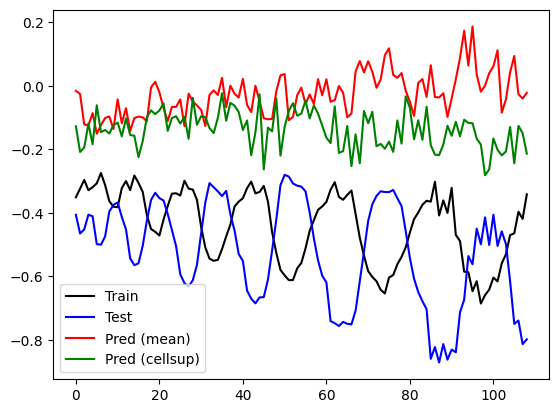

In [37]:
# z > y (of cellsup)
# _, y_pred_cellsup, _, _ = Preds.predict_catboost_multioutput(z_all_concat, y_all_aug, z_test_concat, y_test_scaled)


# x > y (direct pred)
# _, y_pred, catboost_loss, _ = Preds.predict_catboost_multioutput(X_L_2d, y_L, X_test_2d, y_test_scaled)
wafer_idx = 20
plt.plot(y_train_scaled[wafer_idx], '-', color='black', label='Train')
plt.plot(y_test_scaled[wafer_idx], '-', color='blue', label='Test')
plt.plot(y_pred[wafer_idx], '-', color='red', label='Pred (mean)')
plt.plot(y_pred_cellsup[wafer_idx], '-', color='green', label='Pred (cellsup)')
plt.legend()

print(y_train_scaled[wafer_idx].mean())
print(y_test_scaled[wafer_idx].mean())
print(y_pred[wafer_idx].mean())
print(y_pred_cellsup[wafer_idx].mean())


In [ ]:
"Saving to file"
RESULTS_FILE       = "results/results_numbers.json"
LATEX_RESULTS_FILE = "results/latex_results.txt"
WEBHOOK_URL        = messager_params["webhook_url"]

def send_discord_message(webhook_url: str, message: str) -> None:
    "send discord message via webhook"
    data = {"content": message}
    r = requests.post(webhook_url, json=data)
    r.raise_for_status()

def load_json_safely(path: str) -> dict:
    """Load JSON file or return empty dict if missing/empty/invalid."""
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return {}
    try:
        return json.load(open(path))
    except json.JSONDecodeError:
        return {}

def log_result_to_json(method: str, values: list[float]):
    """Append one run's list/tuple of metrics to results file."""
    data = load_json_safely(RESULTS_FILE)
    data.setdefault(method, []).append(list(values))
    json.dump(data, open(RESULTS_FILE, "w"), indent=2)

if params["run_console"]["direct_pred"] == True:
    log_result_to_json("mean(X)", mean_losses)
if params["run_console"]["timevae"] == True:
    log_result_to_json("TimeVAE", timevae_losses)
if params["run_console"]["ts2vec"] == True:
    log_result_to_json("TS2Vec", ts2vec_losses)
if params["run_console"]["moment"] == True:
    log_result_to_json("Moment", moment_losses)
if params["run_console"]["cellsup"] == True:
    log_result_to_json("Cellsup", cellsup_losses)
if params["run_console"]["barlow"] == True:
    log_result_to_json("BarlowCNN", barlow_cnn_losses)
if params["run_console"]["barlow"] == True:
    log_result_to_json("BarlowAE", barlow_ae_losses)
if params["run_console"]["barlow"] == True:
    log_result_to_json("BarlowAE_SSL", barlow_ae_ssl_loss)

# ---- Read JSON ----
data = load_json_safely(RESULTS_FILE)

# Check if all methods have a multiple-of-(num_runs) number of runs
if data and all(len(runs) % num_runs == 0 for runs in data.values()):  # change back to num_runs when ready
    with open(LATEX_RESULTS_FILE, "a") as f:  # <<< APPEND MODE
        timestamp = datetime.now().strftime("%H:%M")
        f.write(f"---- {desired_dataset}, {timestamp}, {data_splitting=}, {label_frac=} ----\n")
        for method, runs in data.items():
            arr = np.array(runs[-num_runs:])  # only last num_runs
            means, stds = arr.mean(axis=0), arr.std(axis=0)
            line = f"{method} & " + " & ".join(
                f"\\val{{{m:.3f}}}{{{std:.3f}}}" for m, std in zip(means, stds)) + "\n"
            f.write(line)
    print(f"Appended avg/std to {LATEX_RESULTS_FILE}")
else:
    print(f"Not enough runs yet (need multiple of {num_runs} per method).")

send_discord_message(WEBHOOK_URL, "Run finished")



In [ ]:
"======== code breaker ========"
1 > f


In [ ]:
"""[almost CORRECT, small issue] Headsup (no predictor q)"""

# once the missing fields are correct, then rely on the moved class in another file, import like so:
# from headsup import Headsup

# ===== init encoder model =====
if os.path.exists(TS2VEC_ENCODER_FILE):
    print("Loading cached TS2Vec encoder...")
    with open(TS2VEC_ENCODER_FILE, "rb") as f:
        ts2vec_encoder = pickle.load(f)
else:
    print("Training TS2Vec encoder...")
    ts2vec_encoder = TS2VecEncoder(z_pooling=z_pooling_method, device=device, patience=ts2vec_patience)
    if ts2vec_encoder._stop_early:
        print("Training stopped early due to no improvement.")
    ts2vec_encoder.fit(X_train, hidden_dims=ts2vec_hidden_dims, output_dims=ts2vec_latent_dims,
                       depth=ts2vec_depth, batch_size=ts2vec_batch_size, n_epochs=ts2vec_epochs)
    with open(TS2VEC_ENCODER_FILE, "wb") as f:
        pickle.dump(ts2vec_encoder, f)

encoder_torch  = TorchWrapper(ts2vec_encoder.ts_model).to(device)
proj_head      = ProjectionHead(input_dim=ts2vec_latent_dims, proj_dim=projection_dim).to(device)
decoder        = Decoder(latent_dim=ts2vec_latent_dims, output_shape=(X_train.shape[1], X_train.shape[2]),
                         hidden_sizes=decoder_hidden_dims).to(device) # doesnt belong to encoder
supervised_head= MLPHead(input_dim=ts2vec_latent_dims, output_dim=y_train_scaled.shape[1],
                         hidden_sizes=predictor_hidden_sizes, dropout=predictor_dropout, device=device)
# ===== run Headsup =====
class Headsup:
    def __init__(self, encoder, proj_head, decoder, supervised_head, device, contrast_temp: float = 0.5,
                 aug1: str = "jitter", aug2: str = "mag_warp", aug1_strength: float = 0.1, aug2_strength: float = 0.1,
                 last_block_lr: float = 1e-3, default_lr: float = 1e-4):
        """Wrapper for pretraining + fine-tuning an encoder with projection, decoder, and supervised head
            encoder: nn.Module
            proj_head: nn.Module
            decoder: nn.Module
            supervised_head: wrapper with .model attribute
            device: torch.device
            contrast_temp: float, temperature for NT-Xent loss
            jitter_strength: float, strength of jitter augmentation
            mag_warp_strength: float, strength of mag_warp augmentation
            last_block_lr: float, learning rate for last block when frac < 0.5
            default_lr: float, default learning rate for other params"""
        self.MIN_BATCH_SIZE   = 2 # for contrastive loss equation
        self.PRINT_EVERY      = 3
        self.lr_min           = 1e-5

        self.encoder          = encoder
        self.proj_head        = proj_head
        self.decoder          = decoder
        self.supervised_head  = supervised_head
        self.device           = device

        self.contrast_temp      = contrast_temp
        self.aug1               = aug1
        self.aug2               = aug2
        self.aug1_strength      = aug1_strength
        self.aug2_strength      = aug2_strength
        self.last_block_lr      = last_block_lr
        self.default_lr         = default_lr

    def _augment(self, X):
        X1 = make_augmentations(X, self.aug1, self.device, self.aug1_strength)
        X2 = make_augmentations(X, self.aug2, self.device, self.aug2_strength)
        return X1, X2

    def _early_stop_check(self, loss_total, best_loss, wait, patience):
        """Stop when loss isnt getting better. Returns updated best_loss, wait counter, and a boolean flag indicating whether to stop."""
        if loss_total < best_loss:
            best_loss = loss_total
            wait = 0
            stop = False
        else:
            wait += 1
            stop = wait >= patience
        return best_loss, wait, stop

    def _make_lr_cos_scheduler(self, optimizer, warmup_steps: int, total_steps: int, min_lr: float):
        """Cosine LR scheduler with linear warmup.
            - optimizer: torch optimizer
            - warmup_steps: steps to linearly ramp up LR
            - total_steps: total training steps
            - min_lr: minimum LR at the end of cosine decay"""
        schedulers = []
        for group in optimizer.param_groups:
            base_lr = group["lr"]

            def lr_lambda(step, base_lr=base_lr):
                if step < warmup_steps:
                    return step / float(max(1, warmup_steps))
                progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
                return (min_lr / base_lr) + (1 - min_lr / base_lr) * 0.5 * (1 + math.cos(math.pi * progress))
            schedulers.append(lr_lambda)
        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=schedulers)

    def _pretrain_single_epoch(self, X_train, batch_size, weights, optimizer, scheduler):
        """Runs one epoch of pretraining on the encoder."""
        loss_recon, loss_contrast, loss_total = 0, 0, 0
        for i in range(0, len(X_train), batch_size):
            X_batch = torch.tensor(X_train[i:i+batch_size], dtype=torch.float32, device=self.device)
            if X_batch.size(0) < self.MIN_BATCH_SIZE:
                continue

            X1, X2    = self._augment(X_batch)
            z1, z2    = self.encoder(X1), self.encoder(X2)
            h1, h2    = self.proj_head(z1).mean(dim=1), self.proj_head(z2).mean(dim=1)
            z1_pooled = z1.mean(dim=1)
            x_recon   = self.decoder(z1_pooled)

            loss_contrast = nt_xent_loss(h1, h2, temperature=self.contrast_temp)
            loss_recon    = F.mse_loss(x_recon, X_batch)
            loss_total    = weights["recon"] * loss_recon + weights["contrast"] * loss_contrast

            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()
            scheduler.step()
        return loss_recon.item(), loss_contrast.item(), loss_total.item()

    def pretrain(self, X_train, batch_size, epochs, warmup_frac_pretrain, weights=weights_pretrain, lr=lr_pretrain, patience = None):
        """Pretrains encoder with contrastive + reconstruction loss. Pretrain usually has lots of steps, and finetuning has few"""
        optimizer_pretrain = torch.optim.AdamW(list(self.encoder.parameters()) +
                                               list(self.proj_head.parameters()) +
                                               list(self.decoder.parameters()), lr=lr)
        max_steps          = train_epochs_pretrain * (len(X_train) // batch_size)
        warmup_steps       = int(warmup_frac_pretrain * max_steps)
        scheduler_pretrain = self._make_lr_cos_scheduler(optimizer_pretrain, warmup_steps=warmup_steps, total_steps=max_steps, min_lr=self.lr_min)

        best_loss, wait = float("inf"), 0
        for epoch in range(epochs):
            loss_recon, loss_contrast, loss_total = self._pretrain_single_epoch(X_train, batch_size, weights, optimizer_pretrain, scheduler_pretrain)
            if epoch % self.PRINT_EVERY == 0:
                print(f"[Pretrain] Epoch {epoch+1}/{epochs}: "
                      f"recon={loss_recon:.4f}, contrast={loss_contrast:.4f}, total={loss_total:.4f}")

            if patience is not None:
                best_loss, wait, stop_flag = self._early_stop_check(loss_total, best_loss, wait, patience)
                if stop_flag:
                    print(f"Early stopping triggered @ epoch {epoch+1}")
                    break
        return self.encoder, self.proj_head, self.decoder

    def _setup_encoder_optimizer(self, frac: float):
        """Sets encoder layers' requires_grad according to labeled fraction.
        Returns weights for the loss components and optimizer"""
        if frac == 1.0:
            for p in self.encoder.parameters():
                p.requires_grad = True # unfrozen encoder
            weights_train   = weights_train_100 #{"pred": 1.0, "recon": 0.5, "contrast": 0.5}
            params_to_opt   = list(self.encoder.parameters()) + list(self.proj_head.parameters()) + \
                              list(self.decoder.parameters()) + list(self.supervised_head.model.parameters())
            optimizer_train = torch.optim.AdamW(params_to_opt, lr=lr_train)
        elif frac >= 0.5:
            for p in self.encoder.parameters():
                p.requires_grad = False # frozen encoder
            weights_train   = weights_train_50 #{"pred": 1.0, "recon": 0.1, "contrast": 0.1}
            params_to_opt   = list(self.encoder.parameters()) + list(self.proj_head.parameters()) + \
                              list(self.decoder.parameters()) + list(self.supervised_head.model.parameters())
            optimizer_train = torch.optim.AdamW(params_to_opt, lr=lr_train)
        else:
            for name, p in self.encoder.named_parameters():
                p.requires_grad = False # frozen encoder
                if name.startswith("encoder_layers") and "last_block" in name:
                    p.requires_grad = True # unfreeze last block only
            weights_train = weights_train_other #{"pred": 2.0, "recon": 0.0, "contrast": 0.0}

            last_block_params = [p for n, p in self.encoder.named_parameters()
                                 if n.startswith("encoder_layers") and "last_block" in n]
            params_to_opt     = list(self.proj_head.parameters()) + list(self.decoder.parameters()) + \
                                list(self.supervised_head.model.parameters())
            optimizer_train   = torch.optim.AdamW([{"params": last_block_params, "lr": self.last_block_lr}, {"params": params_to_opt, "lr": self.default_lr}])
        return weights_train, optimizer_train

    def _train_single_epoch(self, X_L, y_L, X_train, optimizer_train, scheduler_train, batch_size, weights_train):
        """Runs one epoch of fine-tuning on labeled + unlabeled data (tensor conversion done once)."""
        X_L     = X_L.to(self.device) if not isinstance(X_L, torch.Tensor) else X_L
        y_L     = y_L.to(self.device) if not isinstance(y_L, torch.Tensor) else y_L
        X_train = torch.tensor(X_train, dtype=torch.float32, device=self.device) if not isinstance(X_train, torch.Tensor) else X_train

        loss_pred, loss_recon, loss_contrast, loss_total = 0, 0, 0, 0

        num_batches = (len(X_train) + batch_size - 1) // batch_size
        for i in range(num_batches):
            start = i * batch_size
            end_l = min(start + batch_size, len(X_L))
            end_u = min(start + batch_size, len(X_train))

            X_batch_l = X_L[start:end_l]
            y_batch_l = y_L[start:end_l]
            X_batch_u = X_train[start:end_u]

            if X_batch_l.size(0) < self.MIN_BATCH_SIZE or X_batch_u.size(0) < self.MIN_BATCH_SIZE:
                continue

            # encode
            z_l, z_u = self.encoder(X_batch_l), self.encoder(X_batch_u)
            z_l_pooled, z_u_pooled = z_l.mean(dim=1), z_u.mean(dim=1)

            # supervised loss
            y_hat     = self.supervised_head.model(z_l_pooled)
            loss_pred = F.mse_loss(y_hat, y_batch_l)

            # reconstruction loss
            x_recon_l, x_recon_u = self.decoder(z_l_pooled), self.decoder(z_u_pooled)
            loss_recon = (F.mse_loss(x_recon_l, X_batch_l) + F.mse_loss(x_recon_u, X_batch_u)) / 2

            # contrastive loss
            X1_L, X2_L = self._augment(X_batch_l)
            X1_U, X2_U = self._augment(X_batch_u)
            z1_L, z2_L = self.encoder(X1_L), self.encoder(X2_L)
            z1_U, z2_U = self.encoder(X1_U), self.encoder(X2_U)
            h1_L, h2_L = self.proj_head(z1_L).mean(dim=1), self.proj_head(z2_L).mean(dim=1)
            h1_U, h2_U = self.proj_head(z1_U).mean(dim=1), self.proj_head(z2_U).mean(dim=1)
            loss_contrast = (nt_xent_loss(h1_L, h2_L, self.contrast_temp) + nt_xent_loss(h1_U, h2_U, self.contrast_temp)) / 2

            # backward
            loss_total = weights_train["pred"] * loss_pred + weights_train["recon"] * loss_recon + weights_train["contrast"] * loss_contrast
            optimizer_train.zero_grad()
            loss_total.backward()
            optimizer_train.step()
            scheduler_train.step()
        return loss_pred.item(), loss_recon.item(), loss_contrast.item(), loss_total.item()

    def training_loop(self, X_train, y_train_scaled, X_test, y_test_scaled, batch_size, train_epochs_finetune, warmup_frac_train, label_fractions, patience = None):
        """Fine-tunes encoder + heads over all labeled fractions. Pretrain usually has lots of steps, and finetuning has few"""
        results_dict = {}
        z_train_dict = {}
        z_test_dict  = {}
        y_L_dict     = {}
        for frac in label_fractions:
            n_samples = int(len(X_train) * frac)
            X_L       = torch.tensor(X_train[:n_samples], dtype=torch.float32, device=self.device)
            y_L       = torch.tensor(y_train_scaled[:n_samples], dtype=torch.float32, device=self.device)

            weights_train, optimizer_train = self._setup_encoder_optimizer(frac)
            # scheduler_train = CosineAnnealingLR(optimizer_train, T_max=train_epochs_finetune * (len(X_train)//batch_size), eta_min=self.lr_min)
            max_steps       = train_epochs_finetune * (len(X_train) // batch_size)
            warmup_steps    = int(warmup_frac_train * max_steps)
            scheduler_train = self._make_lr_cos_scheduler(optimizer_train, warmup_steps=warmup_steps, total_steps=max_steps, min_lr=self.lr_min)

            best_loss, wait = float("inf"), 0
            for epoch in range(train_epochs_finetune):
                loss_pred, loss_recon, loss_contrast, loss_total = self._train_single_epoch(
                    X_L, y_L, X_train, optimizer_train, scheduler_train, batch_size, weights_train)
                if epoch % self.PRINT_EVERY == 0:
                    print(f"[Finetune {frac*100:.0f}%] Epoch {epoch+1}/{train_epochs_finetune}: "
                          f"pred={loss_pred:.4f}, recon={loss_recon:.4f}, "
                          f"contrast={loss_contrast:.4f}, total={loss_total:.4f}")
                if patience is not None:
                    best_loss, wait, stop_flag = self._early_stop_check(loss_total, best_loss, wait, patience)
                    if stop_flag:
                        print(f"Early stopping triggered @ epoch {epoch+1} (label frac={frac*100:.0f}%)")
                        break

            #  ====== internal evaluation ======
            self.encoder.eval()
            self.proj_head.eval()
            self.decoder.eval()
            self.supervised_head.model.eval()
            with torch.no_grad():
                z_test             = self.encoder(torch.tensor(X_test, dtype=torch.float32, device=self.device))
                z_test_pooled      = z_test.mean(dim=1)
                y_pred             = self.supervised_head.model(z_test_pooled).cpu().numpy()
                results_dict[frac] = root_mean_squared_error(y_test_scaled, y_pred)

                z_train            = self.encoder(X_L).mean(dim=1).cpu().numpy()
                z_train_dict[frac] = z_train
                z_test_dict[frac]  = z_test_pooled.cpu().numpy()
                y_L_dict[frac]     = y_L.cpu().numpy()
                print(f"Sup. head RMSE ({frac*100:.0f}% labels): {results_dict[frac]:.4f}")
        return results_dict, z_train_dict, z_test_dict, y_L_dict

headsup_model = Headsup(encoder_torch, proj_head, decoder, supervised_head, device,aug1=aug1,
                        aug1_strength=aug1_strength, aug2=aug2, aug2_strength=aug2_strength)
# ===== pretrain ======
if os.path.exists(PRETRAIN_ENCODER_FILE):
    checkpoint = torch.load(PRETRAIN_ENCODER_FILE)
    headsup_model.encoder.load_state_dict(checkpoint["encoder"])
    headsup_model.proj_head.load_state_dict(checkpoint["proj_head"])
    headsup_model.decoder.load_state_dict(checkpoint["decoder"])
    print("Loaded pretrained model.")
else:
    headsup_model.pretrain(X_train, batch_size=batch_size_pretrain, epochs=train_epochs_pretrain,
                           warmup_frac_pretrain=warmup_frac_pretrain, patience=patience_pretrain, weights = weights_pretrain)
    torch.save({"encoder": headsup_model.encoder.state_dict(), "proj_head": headsup_model.proj_head.state_dict(),
                "decoder": headsup_model.decoder.state_dict()}, PRETRAIN_ENCODER_FILE)
    print("Saved pretrained model.")

# ======== train =========
results_dict = {}

if os.path.exists(EMBEDDING_CACHE_FILE):
    with open(EMBEDDING_CACHE_FILE, "rb") as f:
        checkpoint = pickle.load(f)
    results_dict = checkpoint["results_dict"]
    z_train_dict = checkpoint["z_train_dict"]
    z_test_dict  = checkpoint["z_test_dict"]
    y_L_dict     = checkpoint["y_L_dict"]
    print("Loaded finetuned cached embeddings and results.")
else:
    results_dict, z_train_dict, z_test_dict, y_L_dict = headsup_model.training_loop(X_train, y_train_scaled, X_test, y_test_scaled,
                                                                                   batch_size=batch_size_train, patience=patience_train,
                                                                                   train_epochs_finetune=train_epochs_finetune,
                                                                                   warmup_frac_train=warmup_frac_train, label_fractions=label_fractions)
    with open(EMBEDDING_CACHE_FILE, "wb") as f:
        pickle.dump({"results_dict": results_dict, "z_train_dict": z_train_dict, "z_test_dict": z_test_dict, "y_L_dict": y_L_dict}, f)
    print("Saved embeddings and results.")

# ==== downstream / external inference ====
z_train   = z_train_dict[label_frac]
z_test_np = z_test_dict[label_frac]
y_L       = y_L_dict[label_frac]

headsup_loss = Preds.evaluate_models_on_dataset(z_train, y_L, z_test_np, y_test_scaled)

print(f"dataset: {desired_dataset}, method: ts2vec, label_frac: {label_frac}")
print("    RMSE     | LinReg | CatBoost | Cluster | RForest | ElasticNet | NN")
print(f"& Z (ts2vec) & {headsup_loss[0]:.4f} & {headsup_loss[1]:.4f}   & {headsup_loss[2]:.4f} \\\\")


In [ ]:
"[shortcut] MOMENT"

def predict_catboost_multioutput2(X_train: np.ndarray, y_train: np.ndarray,X_test: np.ndarray,
                                  y_test: np.ndarray) -> Tuple[Optional[MultiOutputRegressor], np.ndarray, float]:
    """Train multi-output CatBoost with random projection for speed and predict test set.
    Handles constant targets correctly.
    Returns:
        model: trained MultiOutputRegressor (or None if all targets constant)
        y_pred: predictions on test set
        rmse: RMSE across all targets"""
    y_pred = np.zeros_like(y_test, dtype=float)
    
    # Step 0: Identify non-constant targets
    non_constant_idx = [i for i in range(y_train.shape[1])
                        if not np.all(y_train[:, i] == y_train[0, i])]
    
    if non_constant_idx:
        # Step 1: Fast dimensionality reduction
        rp = GaussianRandomProjection(n_components=2048, random_state=42)
        X_train_rp = rp.fit_transform(X_train)
        X_test_rp  = rp.transform(X_test)
        
        # Step 2: Train minimal CatBoost
        model = MultiOutputRegressor(
            CatBoostRegressor(
                iterations=100,        # minimal for speed
                depth=4,             # shallow tree
                learning_rate=0.1,
                verbose=0,
                thread_count=-1      # all CPU cores
            ),
            n_jobs=-1               # parallel outputs
        )
        # iterations=500, learning_rate=0.1, depth=4

        model.fit(X_train_rp, y_train[:, non_constant_idx])
        y_pred[:, non_constant_idx] = model.predict(X_test_rp)
        
        # Step 3: Fill constant outputs
        for i in range(y_train.shape[1]):
            if i not in non_constant_idx:
                y_pred[:, i] = y_train[0, i]
    else:
        model = None
    
    rmse = root_mean_squared_error(y_test, y_pred)
    return model, y_pred, rmse

if params["run_console"]["moment"] == True:
    from sklearn.decomposition import PCA
    from sklearn.random_projection import GaussianRandomProjection

    linreg_loss       = Preds.predict_linreg(z_train, y_train_scaled, z_test, y_test_scaled)
    print("linreg", linreg_loss)
    model, y_pred, rmse = predict_catboost_multioutput2(z_train, y_train_scaled, z_test, y_test_scaled)
    print("RMSE:", rmse)

    unsupervised_rmse = Preds.cluster_and_label(z_train, y_train_scaled, z_test, y_test_scaled, n_clusters=5)
    print("cluster",unsupervised_rmse)

    # rf_rmse           = Preds.predict_rf_multioutput(z_train, y_train_scaled, z_test, y_test_scaled)
    # print("rf",rf_rmse)
    model  = MultiOutputRegressor(RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1))
    model = MultiOutputRegressor(RandomForestRegressor(
            n_estimators=10,    # reduced from 100 to speed up
            max_depth=15,       # limit tree depth to speed up
            min_samples_leaf=2, # prevents overfitting / speeds up slightly
            random_state=42, n_jobs=-1))
    model.fit(z_train, y_train_scaled)
    y_pred = model.predict(z_test)
    rf_rmse = root_mean_squared_error(y_test_scaled, y_pred)
    print("rf",rf_rmse)

    # _, _, el_rmse     = Preds.predict_elasticnet_multioutput(z_train, y_train_scaled, z_test, y_test_scaled, alpha=0.1, l1_ratio=0.5)
    # print("el", el_rmse)

    # predictor_lr      = 0.008
    # predictor_epochs  = 200
    # predictor_dropout = 0.05
    # predictor_hidden_sizes = [256, 128] # latent to y output

    # nn_predictor = MLPHead(input_dim=z_train.shape[1], output_dim=y_train_scaled.shape[1],
    #                            hidden_sizes=predictor_hidden_sizes, lr=predictor_lr,
    #                            epochs=predictor_epochs, dropout=predictor_dropout, device=device)
    # nn_predictor.train(z_train, y_train_scaled, z_test, y_test_scaled)
    # nn_rmse = nn_predictor.evaluate(z_test, y_test_scaled)
    # print("NN:", nn_rmse)


In [ ]:
"4 'ablation' scenarios"
# ===== Prepare 2D / embeddings =====
# # Scenario #1 & #4: direct X→y
X_train_mean = X_train.mean(axis=1).astype(np.float32)
X_test_mean  = X_test.mean(axis=1).astype(np.float32)

n_label = int(label_frac * len(X_train_mean))
X_L, y_L = X_train_mean[:n_label], y_train_scaled[:n_label]

# ===== Scenario #1: Direct supervised on 10% labels =====
linreg_1 = LinearRegression().fit(X_L, y_L)
y_pred_1 = linreg_1.predict(X_test_mean)
rmse_1 = np.sqrt(mean_squared_error(y_test_scaled, y_pred_1))

# ===== Scenario #4: Oracle supervised on 100% labels =====
linreg_4 = LinearRegression().fit(X_train_mean, y_train_scaled)
y_pred_4 = linreg_4.predict(X_test_mean)
rmse_4 = np.sqrt(mean_squared_error(y_test_scaled, y_pred_4))

# ===== Scenario #2: Linear probe on pretrained encoder =====
# Freeze encoder, extract embeddings
with torch.no_grad():
    z_train = custom_model.encoder(torch.tensor(X_train[:n_label], dtype=torch.float32, device=device)).mean(dim=1).cpu().numpy()
    z_test  = custom_model.encoder(torch.tensor(X_test, dtype=torch.float32, device=device)).mean(dim=1).cpu().numpy()

# Train simple predictor on embeddings
linreg_2 = LinearRegression().fit(z_train, y_L)
y_pred_2 = linreg_2.predict(z_test)
rmse_2 = np.sqrt(mean_squared_error(y_test_scaled, y_pred_2))

# ===== Scenario #3: Fine-tune pretrained encoder on 10% labels =====
for p in custom_model.encoder.parameters():
    p.requires_grad = True  # unfreeze encoder

results_dict, _, _, _ = custom_model.training_loop(
    X_train, y_train_scaled, X_test, y_test_scaled,
    batch_size=batch_size_train,
    train_epochs_finetune=train_epochs_finetune,
    warmup_frac_train=warmup_frac_train,
    label_fractions=[label_frac])
rmse_3 = results_dict[label_frac]

# ===== Print RMSE table =====
print(f"Scenario | RMSE")
# print(f"#1 Direct X→y (10% labels): {rmse_1:.4f}")
print(f"#2 Linear Probe (encoder frozen): {rmse_2:.4f}")
print(f"#3 Fine-tune (encoder trainable): {rmse_3:.4f}")
# print(f"#4 Oracle X→y (100% labels): {rmse_4:.4f}")


In [ ]:
# ===== heterogeneous encoders =====

class MLPEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim))

    def encode(self, x): return self.net(x)

class SmallConv1DEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        # For flattened input, reshape to (N, C=1, L=input_dim)
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(16, latent_dim)

    def encode(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)            # (N,1,L)
        c = self.conv(x)                 # (N,16,1)
        c = c.view(len(c), -1)
        return self.fc(c)

# Example create heterogeneous set
input_dim_flat = input_dim
encoders_dict  = {}

# 1) original AE (kept)
encoders_dict['AE_32']   = ae.FlexibleAutoencoder(layer_dims=[input_dim_flat, 64, 32], pred_dim=0).to(device)
# 2) MLP encoder (different inductive bias)
encoders_dict['MLP_32']  = MLPEncoder(input_dim_flat, 32).to(device)
# 3) small conv encoder
encoders_dict['Conv_16'] = SmallConv1DEncoder(input_dim_flat, 16).to(device)
# 4) denoising AE (keep if useful)
encoders_dict['denoiseAE'] = denoise_ae


In [ ]:
from scipy.stats import spearmanr

def latent_target_corr_multi(z: np.ndarray, y: np.ndarray, max_n: int = 3000) -> List[float]:
    """Compute Spearman correlation between pairwise distances in z
    and absolute differences in each y-dimension.
    z: (n, d) latent array
    y: (n, m) targets
    max_n: subsample size for speed
    
    Returns: list of correlations, length m"""
    n = len(y)
    if n > max_n:
        idx = np.random.choice(n, size=max_n, replace=False)
        z, y = z[idx], y[idx]
    # latent distances
    pdist = np.sqrt(((z[:, None, :] - z[None, :, :])**2).sum(-1)).ravel()
    corrs = []
    for j in range(y.shape[1]):
        ydist = np.abs(y[:, None, j] - y[None, :, j]).ravel()
        corr, _ = spearmanr(pdist, ydist)
        corrs.append(float(corr))
    return corrs

corrs = latent_target_corr_multi(z_train, y_L)
print(f"Median corr: {np.nanmedian(corrs):.4f}")
print(f"First 10 corrs: {corrs[:10]}")
# print(z_train.shape, y_L.shape, z_test.shape, y_test_scaled.shape)


In [ ]:
"[OLD] General Prediction"
label_frac = 1  # fraction of training data

print(f"dataset: {desired_dataset}_{page_frac}_{row_frac}, label_frac: {label_frac}")
print(f" RMSE ({label_frac*100}%) | LinReg | CatBoost | Cluster | RForest | ElasticNet")

# ====== X mean ======
X_train_2d = X_train.mean(axis=1).astype(np.float32)
X_test_2d  = X_test.mean(axis=1).astype(np.float32)
linreg_loss, catboost_loss, unsupervised_rmse, rf_rmse = Preds.evaluate_models_on_dataset(X_train_2d, y_train_scaled,
                                                                                          X_test_2d, y_test_scaled)
print(f"& mean(X)   & {linreg_loss:.4f} & {catboost_loss:.4f}   & {unsupervised_rmse:.4f}  & {rf_rmse:.4f} & - \\\\")

# ====== X last ======
X_train_2d = X_train[:, -1:, :].mean(axis=1).astype(np.float32)
X_test_2d  = X_test[:, -1:, :].mean(axis=1).astype(np.float32)
linreg_loss, catboost_loss, unsupervised_rmse, rf_rmse = Preds.evaluate_models_on_dataset(X_train_2d, y_train_scaled,
                                                                                          X_test_2d, y_test_scaled)
print(f"& last(X)   & {linreg_loss:.4f} & {catboost_loss:.4f}   & {unsupervised_rmse:.4f}  & {rf_rmse:.4f}  & - \\\\")

# ====== X random ======
n_train, rows, _ = X_train.shape
n_test     = X_test.shape[0]
train_idx  = np.random.randint(0, rows, size=n_train)
test_idx   = np.random.randint(0, rows, size=n_test)
X_train_2d = X_train[np.arange(n_train), train_idx, :].astype(np.float32)
X_test_2d  = X_test[np.arange(n_test), test_idx, :].astype(np.float32)
linreg_loss, catboost_loss, unsupervised_rmse, rf_rmse = Preds.evaluate_models_on_dataset(X_train_2d, y_train_scaled,
                                                                                          X_test_2d, y_test_scaled)
print(f"& random(X) & {linreg_loss:.4f} & {catboost_loss:.4f}   & {unsupervised_rmse:.4f}  & {rf_rmse:.4f}  & - \\\\")



In [ ]:
"CELLSUP: NO CLUSTERS"

# ===== params + prepare data =====
label_frac  = 1  # labelled fraction of training data
num_epochs  = 1
AE_lr       = 1e-3
weight_decay= 1e-5
dropout     = 0.1
n_samples   = int(label_frac * len(X_train))
X_L = X_train[:n_samples]  # labelled X
X_U = X_train[n_samples:]  # unlabelled X
y_L = y_train_scaled[:n_samples]  # labelled y

X_all     = np.concatenate([X_L, X_U], axis=0)
input_dim = X_all.shape[1] * X_all.shape[2] if X_all.ndim == 3 else X_all.shape[1]
X_tensor  = torch.tensor(X_train, dtype=torch.float32, device=device).reshape(len(X_train), -1)

# ===== pretrain section =====
# Pretraining step: each encoder learns X > z > X_recon. After pretraining, encoder is frozen for downstream tasks

# ===== pretrain AE variants =====
ae_encoders = {}
for latent_dim in [8, 16, 32]:
    ae_model = ae.FlexibleAutoencoder(layer_dims=[input_dim, 64, latent_dim], pred_dim=0).to(device)
    ae_model = train_ae_with_bootstraps(ae_model, X_train, num_epochs=num_epochs, lr=AE_lr, sample_frac=0.8, weight_decay=weight_decay, device=device)
    ae_encoders[f"AE_{latent_dim}"] = ae_model

# --- pretrain Denoising AE ---
denoise_ae    = ae.DenoisingAE(input_size=input_dim, hidden_dims=[64,16], latent_dim=8,
                               dropout_prob=0.05, noise_std=0.1).to(device)
optimizer_dae = torch.optim.AdamW(denoise_ae.parameters(), lr=AE_lr, weight_decay=weight_decay)
for epoch in range(num_epochs):
    optimizer_dae.zero_grad()
    X_recon = denoise_ae(X_tensor)
    loss    = F.mse_loss(X_recon, X_tensor)
    loss.backward()
    optimizer_dae.step()

# ===== assemble encoders =====
encoders_dict = {**ae_encoders,
                 "denoiseAE": denoise_ae,
                 }

# oooooooooo Add a suphead for each encoder oooooooooooo
sup_head_rmse = {}

for name, encoder in encoders_dict.items():
    rmse = train_sup_head_per_encoder(encoder, X_L, y_L, X_test, y_test_scaled, dropout, train_encoder=True, device=device, epochs=num_epochs)
    sup_head_rmse[name] = rmse
    print(f"{name}: RMSE = {rmse:.4f}")
# ooooooooooooooooooooooooooooooooooooooooooooooooooooooo

# rrrrrrrrrrr train/evaluate each encoder individually rrrrrrrrrrr
# For each encoder:
# 1. Encode X_L and X_test to z_train / z_test
# 2. Fit a predictor (CatBoost) from z_train -> y_L
# 3. Predict y_test from z_test using the frozen encoder
# This evaluates the predictive power of each encoder individually
print("Per-encoder CatBoost RMSE:")
for name, encoder in encoders_dict.items():
    z_train = get_latent_tensor(encoder, X_L, train_encoder=False, device=device).cpu().numpy()
    z_test  = get_latent_tensor(encoder, X_test, train_encoder=False, device=device).cpu().numpy()
    _, rmse = train_and_eval_catboost(z_train, y_L, z_test, y_test_scaled)
    print(f"   {name}: {rmse:.4f}")

# ===== Encoder weights =====
weight_encoding_method = "inverse_rmse"  # "uniform", "inverse_rmse", "softmax"
if weight_encoding_method == "uniform":
    encoder_weights = {name: 1.0 for name in encoders_dict.keys()}
    total           = sum(encoder_weights.values())
    encoder_weights = {k: v / total for k, v in encoder_weights.items()}
elif weight_encoding_method == "inverse_rmse": # RMSE-based weights: better encoders get higher weight
    encoder_weights = {name: 1/rmse for name, rmse in sup_head_rmse.items()}
    total           = sum(encoder_weights.values())
    encoder_weights = {k: v/total for k,v in encoder_weights.items()}
elif weight_encoding_method == "softmax": # softmax-based weights
    inv_rmse        = np.array([1/r for r in sup_head_rmse.values()])
    weights_softmax = np.exp(inv_rmse) / np.sum(np.exp(inv_rmse))
    encoder_weights = {name: w for name, w in zip(sup_head_rmse.keys(), weights_softmax)}

# ===== ensemble clustering =====
# After pretraining, we encode X_all with all encoders
# Each encoder’s latent z is clustered via KMeans → produces soft assignment vector q_i
# Soft assignments (probabilities) from all encoders are combined (weighted average) 
# → this is the ensemble cluster_prob_matrix (shape: n_samples x n_clusters)
# This cluster_prob_matrix is the central piece for downstream prediction (frozen; no backprop)

# ===== train predictor + evaluate =====
# Use the ensemble cluster probability matrix as features X -> predict y
# Encoders are frozen; predictor (CatBoost or Linear) is trained on top of ensemble features
# Inference for one sample X1:
#   1. Encode X1 via each encoder → z_i
#   2. Map z_i → cluster probabilities q_i
#   3. Fuse q_i across encoders → prob_vector
#   4. Predict y1 = predictor(prob_vector)

# uuuuuuuuuuuuuuuuuuuuuuuuuuuuuuu
print("-------- predict on latents")
def get_concat_latents(encoders_dict, X, device="cpu"):
    """Return concatenated latent vectors from all encoders for X."""
    latents = []
    for name, encoder in encoders_dict.items():
        z = get_latent_tensor(encoder, X, train_encoder=False, device=device).cpu().numpy()
        latents.append(z)
    return np.concatenate(latents, axis=1)  # shape (N, sum(latent_dims))

z_train_concat = get_concat_latents(encoders_dict, X_L, device=device)
z_test_concat  = get_concat_latents(encoders_dict, X_test, device=device)

_, rmse = train_and_eval_catboost(z_train_concat, y_L, z_test_concat, y_test_scaled)
print(f"latent CatBoost RMSE: {rmse:.4f}")

linreg_loss, catboost_loss, unsupervised_rmse, rf_rmse, el_rmse = \
    Preds.evaluate_models_on_dataset(z_train_concat, y_train_scaled, z_test_concat, y_test_scaled, label_frac=label_frac)
print(f"Ensemble clustering results: dataset: {desired_dataset}")
print("    RMSE       | LinReg | CatBoost | Cluster | RForest | ElasticNet")
print(f"& Z (concat z) & {linreg_loss:.4f} & {catboost_loss:.4f}   & {unsupervised_rmse:.4f}  & {rf_rmse:.4f}  & {el_rmse:.4f} \\\\")


In [ ]:
"popeye"
"""Cellsup: clustering encoder ensemble"""

def get_latent_from_encoder(encoder, X, device="cpu"):
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    if type(encoder).__name__ in ["FlexibleAutoencoder", "AE", "VAE", "DenoisingAE"]:
        if X_tensor.ndim > 2:
            X_tensor = X_tensor.reshape(X_tensor.shape[0], -1)
        if type(encoder).__name__ == "VAE":
            mu, _ = encoder.encode(X_tensor)
            z = mu
        else:
            z = encoder.encode(X_tensor)
        z = z.detach().cpu().numpy()
    elif type(encoder).__name__ == "TS2VecEncoder":
        z = encoder.encode(X)
    else:
        raise ValueError(f"Unknown encoder type: {type(encoder).__name__}")
    return z

def bootstrap_sample(X, sample_frac=0.8):
    """Draw a bootstrap sample from X with replacement. Used to approximate sampling variability when the
    true population dist is unknown
        - X: Input array of shape (n_samples, ...).
        - sample_frac: Fraction of samples to draw (default=0.8).
        - returns: bootstrap sample array of shape (int(n_samples * sample_frac), ...)"""
    idx = np.random.choice(len(X), size=int(len(X)*sample_frac), replace=True)
    return X[idx]

class Cellsup:
    """Ensemble clustering across multiple encoders."""
    def __init__(self, encoders_dict: dict, n_clusters: int = 5, device: str = "cpu"):
        self.cluster_prob_matrix   = None
        self.encoders_dict = encoders_dict
        self.n_clusters    = n_clusters
        self.device        = device
        self.clusterers    = {}  # stores KMeans per encoder

    def fit_kmeans_on_encoder_latents(self, X: np.ndarray, encoder_weights: dict = None):
        probs_list = []
        for name, encoder in self.encoders_dict.items():
            z = get_latent_from_encoder(encoder, X, device=self.device)
            kmeans = KMeans(n_clusters=self.n_clusters, random_state=42).fit(z)
            labels = kmeans.labels_
            prob   = np.eye(self.n_clusters)[labels]
            if encoder_weights is not None:
                prob = prob * encoder_weights.get(name, 1.0)
            probs_list.append(prob)
            self.clusterers[name] = kmeans
        # combine soft assignments
        # self.cluster_prob_matrix = np.mean(probs_list, axis=0) if encoder_weights is None else np.sum(probs_list, axis=0)
        self.cluster_prob_matrix = np.concatenate(probs_list, axis=1)
        return self

    def apply_kmeans_to_new_data(self, X: np.ndarray) -> np.ndarray:
        probs_list = []
        for name, encoder in self.encoders_dict.items():
            z = get_latent_from_encoder(encoder, X, device=self.device)
            kmeans = self.clusterers[name]
            labels = kmeans.predict(z)
            prob = np.eye(self.n_clusters)[labels]
            probs_list.append(prob)
        # return np.mean(probs_list, axis=0)
        return np.concatenate(probs_list, axis=1)

# ===== params + prepare data =====
label_frac = 1  # labelled fraction of training data
n_samples  = int(label_frac * len(X_train))
X_L = X_train[:n_samples]  # labelled X
X_U = X_train[n_samples:]  # unlabelled X
y_L = y_train_scaled[:n_samples]  # labelled y

X_all     = np.concatenate([X_L, X_U], axis=0)
input_dim = X_all.shape[1] * X_all.shape[2] if X_all.ndim == 3 else X_all.shape[1]

# ===== pretrain section =====
# Pretraining step: each encoder learns X -> z -> X_recon
# Only this encoder's weights are updated (no ensemble info yet)
# After pretraining, encoder is frozen for downstream tasks

# ===== pretrain AE variants =====
num_AE_runs = 5
ae_encoders = {}
for latent_dim in [8, 16, 32]:
    ae_model      = ae.FlexibleAutoencoder(layer_dims=[input_dim, 64, latent_dim], pred_dim=0).to(device)
    optimizer_ae  = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
    X_boot        = bootstrap_sample(X_train, 0.8)
    X_tensor_boot = torch.tensor(X_boot, dtype=torch.float32, device=device).reshape(len(X_boot), -1)
    for epoch in range(num_AE_runs):
        optimizer_ae.zero_grad()
        X_recon = ae_model(X_tensor_boot)
        loss    = F.mse_loss(X_recon, X_tensor_boot)
        loss.backward()
        optimizer_ae.step()
    ae_encoders[f"AE_{latent_dim}"] = ae_model

# --- pretrain AE1 ---
num_AE_runs = 5
AE_lr       = 1e-3
ae_model1    = ae.FlexibleAutoencoder(layer_dims=[input_dim, 64, 16], pred_dim=0).to(device)
optimizer_ae = torch.optim.Adam(ae_model1.parameters(), lr=AE_lr)
X_tensor     = torch.tensor(X_train, dtype=torch.float32, device=device).reshape(len(X_train), -1)
for epoch in range(num_AE_runs):
    optimizer_ae.zero_grad()
    X_recon = ae_model1(X_tensor)
    loss    = F.mse_loss(X_recon, X_tensor)
    loss.backward()
    optimizer_ae.step()

# --- pretrain Denoising AE ---
num_DAE_runs = 5
denoise_ae    = ae.DenoisingAE(input_size=input_dim, hidden_dims=[64,16], latent_dim=8,
                               dropout_prob=0.05, noise_std=0.1).to(device)
optimizer_dae = torch.optim.AdamW(denoise_ae.parameters(), lr=AE_lr)
for epoch in range(num_DAE_runs):
    optimizer_dae.zero_grad()
    X_recon = denoise_ae(X_tensor)
    loss    = F.mse_loss(X_recon, X_tensor)
    loss.backward()
    optimizer_dae.step()

# --- pretrain VAE ---
num_VAE_runs   = 5
kl_loss_weight = 1e-3
vae_model      = ae.VAE(input_size=input_dim, hidden_dim=64, latent_dim=16).to(device)
optimizer_vae  = torch.optim.Adam(vae_model.parameters(), lr=1e-3)
for epoch in range(num_VAE_runs):
    optimizer_vae.zero_grad()
    mu, logvar = vae_model.encode(X_tensor)
    z          = vae_model.reparameterize(mu, logvar)
    X_recon    = vae_model.decode(z)
    recon_loss = F.mse_loss(X_recon, X_tensor)
    kl_loss    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss       = recon_loss + kl_loss_weight * kl_loss
    loss.backward()
    optimizer_vae.step()

# --- train/load ts2vec ---
ts2vec_encoder = TS2VecEncoder(z_pooling=z_pooling_method, device=device, patience=ts2vec_patience)
ts2vec_encoder.fit(X_train, hidden_dims=ts2vec_hidden_dims, output_dims=ts2vec_latent_dims,
                   depth=ts2vec_depth, batch_size=ts2vec_batch_size, n_epochs=5)

# ===== assemble encoders =====
encoders_dict = {**ae_encoders,
                 "flexibleAE": ae_model1,
                 "vae": vae_model,
                #  "ts2vec": ts2vec_encoder,
                 "denoiseAE": denoise_ae,
                 }
# ===== optional: encoder weights =====
encoder_weights = {name: 1.0 for name in encoders_dict.keys()}
total           = sum(encoder_weights.values())
encoder_weights = {k: v / total for k, v in encoder_weights.items()}

# zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz
n_clusters = 8
# Make a copy of the original encoders dict
encoders_test = encoders_dict.copy()

# Replace AE1 with a completely untrained AE
untrained_ae = ae.FlexibleAutoencoder(layer_dims=[input_dim, 64, 16], pred_dim=0).to(device)
encoders_test["flexibleAE_untrained"] = untrained_ae

# Remove the pretrained AE1 if you want a clean comparison
# encoders_test.pop("flexibleAE")

# Re-run ensemble clustering with the modified encoders
ensemble_cluster_test = Cellsup(encoders_dict=encoders_test, n_clusters=n_clusters, device=device)
train_probs_test = ensemble_cluster_test.fit_kmeans_on_encoder_latents(X_all, encoder_weights=encoder_weights).cluster_prob_matrix
test_probs_test  = ensemble_cluster_test.apply_kmeans_to_new_data(X_test)

train_probs_L_test = train_probs_test[:len(y_L)]
# Train CatBoost on latent probs of labeled data
catboost_model_test, y_test_pred_test, catboost_rmse_test, _ = \
    Preds.predict_catboost_multioutput(train_probs_L_test, y_L, test_probs_test, y_test_scaled)

print(f"CatBoost RMSE with untrained AE in ensemble: {catboost_rmse_test:.4f}")
# zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz

# ===== train/evaluate each encoder individually =====
# For each encoder:
# 1. Encode X_L and X_test to z_train / z_test
# 2. Fit a predictor (CatBoost) from z_train -> y_L
# 3. Predict y_test from z_test using the frozen encoder
# This evaluates the predictive power of each encoder individually
print("Per-encoder RMSE on X_L vs X_test:")
for name, encoder in encoders_dict.items():
    z_train = get_latent_from_encoder(encoder, X_L, device=device)
    z_test  = get_latent_from_encoder(encoder, X_test, device=device)

    # identify non-constant columns in y_train (on labeled fraction)
    mask         = [i for i in range(y_L.shape[1]) if not np.all(y_L[:, i] == y_L[0, i])]
    const_values = {i: y_L[0, i] for i in range(y_L.shape[1]) if i not in mask}

    y_pred = np.zeros_like(y_test_scaled, dtype=float)  # shape = test labels
    model  = None
    if mask:
        model = MultiOutputRegressor(CatBoostRegressor(iterations=500, learning_rate=0.1, depth=4,random_seed=42, verbose=0))
        model.fit(z_train, y_L[:, mask])
        y_pred[:, mask] = model.predict(z_test)  # now matches y_test_scaled shape

    # fill constant columns
    for i, v in const_values.items():
        y_pred[:, i] = v

    rmse = root_mean_squared_error(y_test_scaled, y_pred)
    print(f"  {name}: {rmse:.4f}")

# ===== ensemble clustering =====
# After pretraining, we encode X_all with all encoders
# Each encoder’s latent z is clustered via KMeans → produces soft assignment vector q_i
# Soft assignments (probabilities) from all encoders are combined (weighted average) 
# → this is the ensemble cluster_prob_matrix (shape: n_samples x n_clusters)
# This cluster_prob_matrix is the central piece for downstream prediction (frozen; no backprop)
n_clusters = 8
ensemble_cluster = Cellsup(encoders_dict=encoders_dict, n_clusters=n_clusters, device=device)
# train_probs_all  = ensemble_cluster.fit_kmeans_on_encoder_latents(X_all, encoder_weights=encoder_weights).cluster_prob_matrix
train_probs_all  = ensemble_cluster.fit_kmeans_on_encoder_latents(X_train, encoder_weights=encoder_weights).cluster_prob_matrix
test_probs       = ensemble_cluster.apply_kmeans_to_new_data(X_test)

train_probs_L = train_probs_all[:len(y_L)]
train_probs_U = train_probs_all[len(y_L):]

# ===== train predictor + evaluate =====
# Use the ensemble cluster probability matrix as features X -> predict y
# Encoders are frozen; predictor (CatBoost or Linear) is trained on top of ensemble features
# Inference for one sample X1:
#   1. Encode X1 via each encoder → z_i
#   2. Map z_i → cluster probabilities q_i
#   3. Fuse q_i across encoders → prob_vector
#   4. Predict y1 = predictor(prob_vector)
catboost_model, y_test_pred, catboost_rmse, non_const_idx = \
    Preds.predict_catboost_multioutput(train_probs_L, y_L, test_probs, y_test_scaled)
print(f"label_frac: {label_frac}, CatBoost RMSE (on X_L only): {catboost_rmse:.4f}")

linreg_loss, catboost_loss, unsupervised_rmse, rf_rmse, el_rmse = \
    Preds.evaluate_models_on_dataset(train_probs_all, y_train_scaled, test_probs, y_test_scaled, label_frac=1.0)

print(f"Ensemble clustering results:")
print("    RMSE       | LinReg | CatBoost | Cluster | RForest | ElasticNet")
print(f"& Z (ensemble) & {linreg_loss:.4f} & {catboost_loss:.4f}   & {unsupervised_rmse:.4f}  & {rf_rmse:.4f}  & {el_rmse:.4f} \\\\")


In [ ]:
"""[old] Loop Headsup"""
# params
train_epochs = 150
batch_size   = 16
warmup_steps = 1000
max_steps    = train_epochs * (len(X_train) // batch_size)
step         = 0

decoder_hidden_dims = [16, 64, 128]
optimizer_lr   = 1e-3
projection_dim = 16

# init methods
encoder = TS2VecEncoder(z_pooling=z_pooling_method, device=device)
encoder.fit(X_train, hidden_dims=ts2vec_hidden_dims, output_dims=ts2vec_latent_dims,
            depth=ts2vec_depth, batch_size=ts2vec_batch_size, n_epochs=ts2vec_epochs)

proj_head   = ProjectionHead(input_dim=ts2vec_latent_dims, proj_dim=projection_dim).to(device)
predictor   = ProjectionHead(input_dim=projection_dim, proj_dim=projection_dim).to(device)
decoder     = Decoder(latent_dim=ts2vec_latent_dims, output_shape=(X_train.shape[1], X_train.shape[2]),
                      hidden_sizes=decoder_hidden_dims).to(device)
supervised_head = MLPHead(input_dim=ts2vec_latent_dims, output_dim=y_train_scaled.shape[1], hidden_sizes=predictor_hidden_sizes,
                          lr=predictor_lr, epochs=1, dropout=predictor_dropout, device=device)#.to(device)
# joint optimizer
params = (list(proj_head.parameters()) +
          list(predictor.parameters()) +
          list(decoder.parameters()) +
          list(supervised_head.model.parameters()))
optimizer = torch.optim.AdamW(params, lr=optimizer_lr)

for epoch in range(train_epochs):
    for i in range(0, len(X_train), batch_size):
        step   += 1
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train_scaled[i:i+batch_size]

        # 1. Augment
        X1 = make_augmentations(torch.tensor(X_batch, dtype=torch.float32, device=device), "jitter", device, 0.1)
        X2 = make_augmentations(torch.tensor(X_batch, dtype=torch.float32, device=device), "mag_warp", device, 0.1)

        # 2. Encode
        z1 = torch.tensor(encoder.encode(X1.cpu().numpy()), dtype=torch.float32, device=device)
        z2 = torch.tensor(encoder.encode(X2.cpu().numpy()), dtype=torch.float32, device=device)

        # 3. Projections
        h1, h2 = proj_head(z1), proj_head(z2)
        p1     = predictor(h1)

        # 4. Losses
        loss_contrast = compute_byol_loss(p1, h2.detach())
        x_recon       = decoder(z1)
        loss_recon    = F.mse_loss(x_recon, torch.tensor(X_batch, dtype=torch.float32, device=device))

        y_batch_t = torch.tensor(y_batch, dtype=torch.float32, device=device)
        y_hat     = supervised_head.model(z1)
        loss_pred = F.mse_loss(y_hat, y_batch_t)

        # 5. Weighted total loss
        weights = get_loss_weights(step, warmup_steps, max_steps)
        # weights = {"pred": 1.0, "recon": 0.0, "contrast": 0.0}
        loss    = (weights["recon"] * loss_recon + weights["contrast"] * loss_contrast + weights["pred"] * loss_pred)

        # 6. Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{train_epochs}: "
          f"pred={loss_pred.item():.4f}, recon={loss_recon.item():.4f}, "
          f"contrast={loss_contrast.item():.4f}, total loss={loss.item():.4f}")

# ===== Inference =====
proj_head.eval()
predictor.eval()
decoder.eval()
supervised_head.model.eval()

with torch.no_grad():
    # encode test set once with frozen encoder
    z_test = torch.tensor(ts2vec_encoder.encode(X_test), dtype=torch.float32, device=device)
    y_pred = supervised_head.model(z_test).cpu().numpy()

rmse = root_mean_squared_error(y_test_scaled, y_pred)
print(f"Headsup RMSE: {rmse:.4f}")



In [ ]:
"[to remove] Run Headsup with TS2Vec encoder"
# 0. params
w_pred, w_recon, w_contrast = 0.5, 0.2, 0.3
decoder_hidden_dims = [16, 64, 128]
optimizer_lr   = 9e-3
projection_dim = 16
proj_input_dim = projection_dim

# 1. augment X
X_1 = make_augmentations(torch.tensor(X_train, dtype=torch.float32, device=device), "jitter", device, 0.1)
X_2 = make_augmentations(torch.tensor(X_train, dtype=torch.float32, device=device), "mag_warp", device, 0.1)

# 2. fit TS2Vec on train data
ts2vec_encoder = TS2VecEncoder(z_pooling=z_pooling_method, device=device)
ts2vec_encoder.fit(X_train, hidden_dims=ts2vec_hidden_dims, output_dims=ts2vec_latent_dims,
                   depth=ts2vec_depth, batch_size=ts2vec_batch_size, n_epochs=ts2vec_epochs)

# encode augmented views (X → z)
z_1 = torch.tensor(ts2vec_encoder.encode(X_1.cpu().numpy()), dtype=torch.float32, device=device)
z_2 = torch.tensor(ts2vec_encoder.encode(X_2.cpu().numpy()), dtype=torch.float32, device=device)

# encode full train/test set for supervised loss
z_train   = torch.tensor(ts2vec_encoder.encode(X_train), dtype=torch.float32, device=device)
z_test    = torch.tensor(ts2vec_encoder.encode(X_test), dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

# 3. projection head
proj_head = ProjectionHead(input_dim=z_1.shape[1], proj_dim=projection_dim).to(device)
h_1 = proj_head(z_1)
h_2 = proj_head(z_2)

# 4. predictor for BYOL contrast
predictor = ProjectionHead(input_dim=proj_input_dim, proj_dim=projection_dim).to(device)
p_1 = predictor(h_1)

# 5. BYOL contrastive loss
loss_contrast = compute_byol_loss(p_1, h_2.detach())

# 6. optional decoder
decoder = Decoder(latent_dim=z_1.shape[1], output_shape=(X_train.shape[1], X_train.shape[2]),
                  hidden_sizes= decoder_hidden_dims).to(device)
x_recon = decoder(z_1)
loss_recon = F.mse_loss(x_recon, torch.tensor(X_train, dtype=torch.float32, device=device))

# 7. supervised predictor head
supervised_head = MLPHead(input_dim=z_1.shape[1], output_dim=y_train_scaled.shape[1],
                          hidden_sizes=predictor_hidden_sizes, lr=predictor_lr,
                          epochs=predictor_epochs, dropout=predictor_dropout, device=device)

# forward pass for supervised prediction
y_hat_train = supervised_head.model(z_train)
loss_pred   = F.mse_loss(y_hat_train, y_train_t)

# 8. combine losses
# total_loss = w_pred * loss_pred + w_recon * loss_recon + w_contrast * loss_contrast
weights = get_loss_weights(step, warmup_steps, max_steps)
loss    = (weights["recon"] * loss_recon + weights["contrast"] * loss_contrast + weights["pred"] * loss_pred)
print(f"Loss: pred={loss_pred.item():.4f}, recon={loss_recon.item():.4f}, contrast={loss_contrast.item():.4f}, total={loss.item():.4f}")

# 9. backprop and joint optimization
optimizer = torch.optim.AdamW(list(proj_head.parameters()) +
                              list(predictor.parameters()) +
                              list(decoder.parameters()) +
                              list(supervised_head.model.parameters()),
                              lr=optimizer_lr)
optimizer.zero_grad()
loss.backward()
optimizer.step()

"Predictions"
# 1️⃣ Encode test data with TS2Vec (frozen encoder)
z_test = torch.tensor(ts2vec_encoder.encode(X_test), dtype=torch.float32, device=device)

# 2️⃣ Predict with supervised MLPHead
y_pred = supervised_head.predict(z_test) # changes done to supervised_head

rmse  = root_mean_squared_error(y_test_scaled, y_pred)
print(f"Headsup RMSE: {rmse:.4f}")


In [ ]:
"old cellsup"

"""Cellsup: clustering encoder ensemble"""
from scipy.special import softmax

# old
def XXX_get_latent_from_encoder(encoder, X, device="cpu"):
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    if type(encoder).__name__ in ["FlexibleAutoencoder", "AE", "VAE", "DenoisingAE"]:
        if X_tensor.ndim > 2:
            X_tensor = X_tensor.reshape(X_tensor.shape[0], -1)
        if type(encoder).__name__ == "VAE":
            mu, _ = encoder.encode(X_tensor)
            z = mu
        else:
            z = encoder.encode(X_tensor)
        z = z.detach().cpu().numpy()
    elif type(encoder).__name__ == "TS2VecEncoder":
        z = encoder.encode(X)
    else:
        raise ValueError(f"Unknown encoder type: {type(encoder).__name__}")
    return z

def get_latent_from_encoder(encoder, X, device="cpu") -> np.ndarray:
    """Return latent z for any encoder type with shape (N, latent_dim)."""
    if isinstance(encoder, nn.Module):
        X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
        if X_tensor.ndim > 2:
            X_tensor = X_tensor.reshape(len(X_tensor), -1)
        if type(encoder).__name__ == "VAE":
            mu, _ = encoder.encode(X_tensor)
            z     = mu.detach().cpu().numpy()
        else: # AE / DAE: return latent layer instead of reconstruction
            z = encoder.encode(X_tensor).detach().cpu().numpy()
    elif type(encoder).__name__ == "TS2VecEncoder":
        z = encoder.encode(X)  # returns (N, T, latent_dim)
        z = z.mean(axis=1)      # temporal pooling
    else:
        raise ValueError(f"Unknown encoder type: {type(encoder).__name__}")
    return z

def bootstrap_sample(X, sample_frac=0.8):
    """Draw a bootstrap sample from X with replacement. Used to approximate sampling variability when the
    true population dist is unknown
        - X: Input array of shape (n_samples, ...).
        - sample_frac: Fraction of samples to draw (default=0.8).
        - returns: bootstrap sample array of shape (int(n_samples * sample_frac), ...)"""
    idx = np.random.choice(len(X), size=int(len(X)*sample_frac), replace=True)
    return X[idx]

def build_Q_concat(clusterers: Dict[str, KMeans], zs: Dict[str, np.ndarray], weights: Dict[str, float] | None = None) -> np.ndarray:
    """Convert encoder latents into concatenated cluster one-hots.
    Args:
        clusterers: dict[name] -> fitted KMeans (K clusters).
        zs: dict[name] -> latent array for that encoder, shape (N, D_z).
        weights: optional dict[name] -> scalar weight for that encoder.
    Returns:
        Q_concat: np.ndarray of shape (N, E*K), concatenated per-encoder one-hots."""
    blocks: List[np.ndarray] = []
    for name, kmeans in clusterers.items():
        z = zs[name]                        # (N, D_z)
        labels = kmeans.predict(z)          # (N,)
        K = kmeans.n_clusters
        q = np.eye(K)[labels]               # (N, K) hard one-hot
        if weights is not None:
            q = q * float(weights.get(name, 1.0))
        blocks.append(q)
    return np.concatenate(blocks, axis=1)   # (N, E*K)


class SupHead(nn.Module):
    """Small supervised head: maps latent z -> target y"""
    def __init__(self, input_dim: int, output_dim: int, hidden_sizes=[64, 32]):
        super().__init__()
        layers, prev_dim = [], input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

class Cellsup:
    """Ensemble clustering across multiple encoders."""
    def __init__(self, encoders_dict: dict, n_clusters: int = 5, device: str = "cpu", cluster_assignment: str = "soft"):
        self.encoders_dict      = encoders_dict
        self.n_clusters         = n_clusters
        self.device             = device
        self.cluster_assignment = cluster_assignment
        self.cluster_prob_matrix= None
        self.clusterers         = {}  # stores KMeans per encoder

    def fit_kmeans_on_encoder_latents(self, X: np.ndarray, encoder_weights: dict = None):
        probs_list = []
        for name, encoder in self.encoders_dict.items():
            z      = get_latent_from_encoder(encoder, X, device=self.device)
            kmeans = KMeans(n_clusters=self.n_clusters, random_state=42).fit(z)
            labels = kmeans.labels_
            if self.cluster_assignment == "soft":
                distances = kmeans.transform(z)  # shape (n_samples, n_clusters)
                prob      = softmax(-distances, axis=1)  # convert distance → probability
            elif self.cluster_assignment == "hard":
                prob = np.eye(self.n_clusters)[labels]
            if encoder_weights is not None:
                prob *= encoder_weights.get(name, 1.0)
            probs_list.append(prob)
            self.clusterers[name] = kmeans
        # # combine soft assignments
        # self.cluster_prob_matrix = np.mean(probs_list, axis=0) if encoder_weights is None else np.sum(probs_list, axis=0)
        # return self

        # FIX: concatenate horizontally instead of averaging
        self.cluster_prob_matrix = np.concatenate(probs_list, axis=1)  # (N, E*K)
        return self

    def apply_kmeans_to_new_data(self, X: np.ndarray) -> np.ndarray:
        probs_list = []
        for name, encoder in self.encoders_dict.items():
            z      = get_latent_from_encoder(encoder, X, device=self.device)
            kmeans = self.clusterers[name]
            labels = kmeans.predict(z)
            if self.cluster_assignment == "soft":
                distances = kmeans.transform(z)  # shape (n_samples, n_clusters)
                prob      = softmax(-distances, axis=1)  # convert distance → probability
            elif self.cluster_assignment == "hard":
                prob = np.eye(self.n_clusters)[labels]
            probs_list.append(prob)
        # return np.mean(probs_list, axis=0)

        # fix
        return np.concatenate(probs_list, axis=1)  # (N, E*K)

# ===== params + prepare data =====
label_frac = 0.5  # labelled fraction of training data
n_samples  = int(label_frac * len(X_train))
X_L = X_train[:n_samples]  # labelled X
X_U = X_train[n_samples:]  # unlabelled X
y_L = y_train_scaled[:n_samples]  # labelled y

X_all     = np.concatenate([X_L, X_U], axis=0)
input_dim = X_all.shape[1] * X_all.shape[2] if X_all.ndim == 3 else X_all.shape[1]

# ===== pretrain section =====
# Pretraining step: each encoder learns X -> z -> X_recon
# Only this encoder's weights are updated (no ensemble info yet)
# After pretraining, encoder is frozen for downstream tasks

# ===== pretrain AE variants =====
num_AE_runs = 5
ae_encoders = {}
for latent_dim in [8, 16, 32]:
    ae_model      = ae.FlexibleAutoencoder(layer_dims=[input_dim, 64, latent_dim], pred_dim=0).to(device)
    optimizer_ae  = torch.optim.AdamW(ae_model.parameters(), lr=1e-3)
    X_boot        = bootstrap_sample(X_train, 0.8)
    X_tensor_boot = torch.tensor(X_boot, dtype=torch.float32, device=device).reshape(len(X_boot), -1)
    for epoch in range(num_AE_runs):
        optimizer_ae.zero_grad()
        X_recon = ae_model(X_tensor_boot)
        loss    = F.mse_loss(X_recon, X_tensor_boot)
        loss.backward()
        optimizer_ae.step()
    ae_encoders[f"AE_{latent_dim}"] = ae_model

# --- pretrain AE1 ---
num_AE_runs = 5
AE_lr       = 1e-3
ae_model1    = ae.FlexibleAutoencoder(layer_dims=[input_dim, 64, 16], pred_dim=0).to(device)
optimizer_ae = torch.optim.AdamW(ae_model1.parameters(), lr=AE_lr)
X_tensor     = torch.tensor(X_train, dtype=torch.float32, device=device).reshape(len(X_train), -1)
for epoch in range(num_AE_runs):
    optimizer_ae.zero_grad()
    X_recon = ae_model1(X_tensor)
    loss    = F.mse_loss(X_recon, X_tensor)
    loss.backward()
    optimizer_ae.step()

# --- pretrain Denoising AE ---
num_DAE_runs = 5
denoise_ae    = ae.DenoisingAE(input_size=input_dim, hidden_dims=[64,16], latent_dim=8,
                               dropout_prob=0.05, noise_std=0.1).to(device)
optimizer_dae = torch.optim.AdamW(denoise_ae.parameters(), lr=AE_lr)
for epoch in range(num_DAE_runs):
    optimizer_dae.zero_grad()
    X_recon = denoise_ae(X_tensor)
    loss    = F.mse_loss(X_recon, X_tensor)
    loss.backward()
    optimizer_dae.step()

# --- pretrain VAE ---
num_VAE_runs   = 5
kl_loss_weight = 1e-3
vae_model      = ae.VAE(input_size=input_dim, hidden_dim=64, latent_dim=16).to(device)
optimizer_vae  = torch.optim.AdamW(vae_model.parameters(), lr=1e-3)
for epoch in range(num_VAE_runs):
    optimizer_vae.zero_grad()
    mu, logvar = vae_model.encode(X_tensor)
    z          = vae_model.reparameterize(mu, logvar)
    X_recon    = vae_model.decode(z)
    recon_loss = F.mse_loss(X_recon, X_tensor)
    kl_loss    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss       = recon_loss + kl_loss_weight * kl_loss
    loss.backward()
    optimizer_vae.step()

# --- train/load ts2vec ---
# n_epochs = 1 # change back to 5 when done debugging
# ts2vec_encoder = TS2VecEncoder(z_pooling=z_pooling_method, device=device, patience=ts2vec_patience)
# ts2vec_encoder.fit(X_train, hidden_dims=ts2vec_hidden_dims, output_dims=ts2vec_latent_dims,
#                    depth=ts2vec_depth, batch_size=ts2vec_batch_size, n_epochs=n_epochs)

# ===== assemble encoders =====
encoders_dict = {**ae_encoders,
                 "flexibleAE": ae_model1,
                 "vae": vae_model,
                #  "ts2vec": ts2vec_encoder,
                 "denoiseAE": denoise_ae,
                 }
# ===== optional: encoder weights =====
encoder_weights = {name: 1.0 for name in encoders_dict.keys()}
total           = sum(encoder_weights.values())
encoder_weights = {k: v / total for k, v in encoder_weights.items()}

# encoder_weights = {name: 1/rmse for name, rmse in sup_head_rmse.items()}
# total = sum(encoder_weights.values())
# encoder_weights = {k: v/total for k,v in encoder_weights.items()}


# ooooooooooooooooooooooooooooooooooooooooooooooooooooooo
trainable_encoders = ["FlexibleAutoencoder", "AE", "VAE", "DenoisingAE"]
sup_head_rmse = {}

for name, encoder in encoders_dict.items():
    train_encoder = isinstance(encoder, nn.Module) and type(encoder).__name__ in trainable_encoders

    # ----- sample latent to get input_dim -----
    # Get the latent representation of a sample to determine the input dimension for SupHead.
    # Put the encoder in eval mode to handle BatchNorm layers with batch_size=1
    if train_encoder:
        encoder.eval()
    
    z_sample_L = get_latent_from_encoder(encoder, X_L[:2], device=device) # Use a batch of size 2
    if isinstance(z_sample_L, np.ndarray):
        z_sample_L = torch.tensor(z_sample_L, dtype=torch.float32, device=device)
    
    # Switch back to train mode if needed
    if train_encoder:
        encoder.train()
    
    latent_dim = z_sample_L.shape[-1]
    sup_head = SupHead(input_dim=latent_dim, output_dim=y_L.shape[1]).to(device)

    # ----- optimizer -----
    params = list(sup_head.parameters())
    if train_encoder:
        params += list(encoder.parameters())
    optimizer = torch.optim.AdamW(params, lr=1e-3)

    # ----- training -----
    for epoch in range(5):
        sup_head.train()
        if train_encoder:
            encoder.train()
            # The .encode() method must be called to get the latent space
            X_tensor = torch.tensor(X_L, dtype=torch.float32, device=device).reshape(len(X_L), -1)
            z = encoder.encode(X_tensor)
            if isinstance(z, tuple):
                z = z[0]
            # Ensure z is 2D
            if z.ndim > 2:
                z = z.mean(axis=1)
        else:
            with torch.no_grad():
                z = get_latent_from_encoder(encoder, X_L, device=device)
                if z.ndim > 2:
                    z = z.mean(axis=1)
                if isinstance(z, np.ndarray):
                    z = torch.tensor(z, dtype=torch.float32, device=device)

        if z.ndim == 1:
            z = z[:, None]

        print(f"{name} SupHead input: {z.shape}")
        y_pred = sup_head(z)
        y_tensor = torch.tensor(y_L, dtype=torch.float32, device=device)
        loss = F.mse_loss(y_pred, y_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch #{epoch}: loss={loss.item():.4f}")

    # ----- evaluation -----
    sup_head.eval()
    with torch.no_grad():
        if train_encoder:
            encoder.eval()
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
            if X_test_tensor.ndim > 2:
                 X_test_tensor = X_test_tensor.reshape(len(X_test_tensor), -1)
            z_test = encoder.encode(X_test_tensor)
            if isinstance(z_test, tuple):
                z_test = z_test[0]
        else:
            z_test = get_latent_from_encoder(encoder, X_test, device=device)
            
        if z_test.ndim > 2:
            z_test = z_test.mean(axis=1)
        if isinstance(z_test, np.ndarray):
            z_test = torch.tensor(z_test, dtype=torch.float32, device=device)
        if z_test.ndim == 1:
            z_test = z_test[:, None]

        y_pred_test = sup_head(z_test).cpu().numpy()
        rmse = root_mean_squared_error(y_test_scaled, y_pred_test)
        sup_head_rmse[name] = rmse
        print(f"{name}: RMSE = {rmse:.4f}")
# ooooooooooooooooooooooooooooooooooooooooooooooooooooooo

# ===== train/evaluate each encoder individually =====
# For each encoder:
# 1. Encode X_L and X_test to z_train / z_test
# 2. Fit a predictor (CatBoost) from z_train -> y_L
# 3. Predict y_test from z_test using the frozen encoder
# This evaluates the predictive power of each encoder individually
print("Per-encoder RMSE on X_L vs X_test:")
for name, encoder in encoders_dict.items():
    z_train = get_latent_from_encoder(encoder, X_L, device=device)
    z_test  = get_latent_from_encoder(encoder, X_test, device=device)

    # identify non-constant columns in y_train (on labeled fraction)
    mask         = [i for i in range(y_L.shape[1]) if not np.all(y_L[:, i] == y_L[0, i])]
    const_values = {i: y_L[0, i] for i in range(y_L.shape[1]) if i not in mask}

    y_pred = np.zeros_like(y_test_scaled, dtype=float)  # shape = test labels
    model  = None
    if mask:
        model = MultiOutputRegressor(CatBoostRegressor(iterations=500, learning_rate=0.1, depth=4, verbose=0))
        model.fit(z_train, y_L[:, mask])
        y_pred[:, mask] = model.predict(z_test)  # now matches y_test_scaled shape

    # fill constant columns
    for i, v in const_values.items():
        y_pred[:, i] = v

    rmse = root_mean_squared_error(y_test_scaled, y_pred)
    print(f"  {name}: {rmse:.4f}")

# ===== ensemble clustering =====
# After pretraining, we encode X_all with all encoders
# Each encoder’s latent z is clustered via KMeans → produces soft assignment vector q_i
# Soft assignments (probabilities) from all encoders are combined (weighted average) 
# → this is the ensemble cluster_prob_matrix (shape: n_samples x n_clusters)
# This cluster_prob_matrix is the central piece for downstream prediction (frozen; no backprop)
n_clusters = 8
ensemble_cluster = Cellsup(encoders_dict=encoders_dict, n_clusters=n_clusters, device=device)
train_probs_all  = ensemble_cluster.fit_kmeans_on_encoder_latents(X_all, encoder_weights=encoder_weights).cluster_prob_matrix
test_probs       = ensemble_cluster.apply_kmeans_to_new_data(X_test)

train_probs_L = train_probs_all[:len(y_L)]
train_probs_U = train_probs_all[len(y_L):]

# ===== train predictor + evaluate =====
# Use the ensemble cluster probability matrix as features X -> predict y
# Encoders are frozen; predictor (CatBoost or Linear) is trained on top of ensemble features
# Inference for one sample X1:
#   1. Encode X1 via each encoder → z_i
#   2. Map z_i → cluster probabilities q_i
#   3. Fuse q_i across encoders → prob_vector
#   4. Predict y1 = predictor(prob_vector)
catboost_model, y_test_pred, catboost_rmse, non_const_idx = \
    Preds.predict_catboost_multioutput(train_probs_L, y_L, test_probs, y_test_scaled)
print(f"label_frac: {label_frac}, CatBoost RMSE (on X_L only): {catboost_rmse:.4f}")

linreg_loss, catboost_loss, unsupervised_rmse, rf_rmse, el_rmse = \
    Preds.evaluate_models_on_dataset(train_probs_all, y_train_scaled, test_probs, y_test_scaled, label_frac=1.0)

print(f"Ensemble clustering results:")
print("    RMSE       | LinReg | CatBoost | Cluster | RForest | ElasticNet")
print(f"& Z (ensemble) & {linreg_loss:.4f} & {catboost_loss:.4f}   & {unsupervised_rmse:.4f}  & {rf_rmse:.4f}  & {el_rmse:.4f} \\\\")


In [ ]:
# pages, rows, cols = X_train.shape
# plt.figure(figsize=(15, 6))
# for i in range(cols):
#     plt.plot(X_train[4,:,i])
#     break
# plt.show()

rows, cols = y_train_scaled.shape
plt.figure(figsize=(15, 6))
for i in range(rows):
    plt.plot(y_train_scaled[i,:])
    if i >10:
        break
plt.show()


In [ ]:
"Logging results"
CSV_LOG_NAME  = f"runs_log.csv"
JSON_LOG_NAME = f"runs_log.jsonl"
CSV_LOG_FILE  = Path(f"results/{CSV_LOG_NAME}")
JSON_LOG_FILE = Path(f"results/{JSON_LOG_NAME}")

params  = {"pretrain_epochs": train_epochs_pretrain, "train_epochs": train_epochs_finetune,
           "batch_size_pretrain": batch_size_pretrain, "batch_size_train": batch_size_train,
           "decoder_hidden_dims": decoder_hidden_dims, "projection_dim": projection_dim,
           "lr_pretrain": lr_pretrain, "lr_train": lr_train}

formatted_results_dict = {k: f"{v:.4f}" for k, v in results_dict.items()}
results = {"results": formatted_results_dict,
           "linreg_rmse": f"{linreg_loss:.4f}","catboost_rmse": f"{catboost_loss:.4f}",
           "unsupervised_rmse": f"{unsupervised_rmse:.4f}", "rf_rmse": f"{rf_rmse:.4f}",
           "el_rmse": f"{el_rmse:.4f}"}

top_metrics = {"linreg_rmse": linreg_loss,
               "catboost_rmse": catboost_loss,
               "unsupervised_rmse": unsupervised_rmse,
               "rf_rmse": rf_rmse,
               "el_rmse": el_rmse}

LogRunResults.log_run_in_csv(params, results, CSV_LOG_FILE)
LogRunResults.log_run_json(params, results_dict, top_metrics, JSON_LOG_FILE)


In [ ]:
# ===== Headsup for CatBoost =====
# doesnt work well, catboost doesnt backprop

class HeadsCatboost(Headsup):
    def __init__(self, encoder, proj_head, decoder, device, catboost_params=None):
        super().__init__(encoder, proj_head, decoder, supervised_head=None, device=device)
        self.catboost_params = catboost_params or dict(iterations=500, learning_rate=0.05, depth=6, verbose=0)
        self.catboost_model = None
        self.non_constant_idx = []

    def pretrain_encoder(self, X_train, batch_size, epochs):
        """Run only the pretraining stage."""
        self.pretrain(X_train, batch_size=batch_size, epochs=epochs)

    def predict_catboost_multioutput(self, X_train: np.ndarray, y_train: np.ndarray, 
                                     X_test: np.ndarray, y_test: np.ndarray) -> Tuple[Optional[MultiOutputRegressor], np.ndarray, float, list]:
        """Train multi-output CatBoost and return predictions, RMSE, and non-constant indices."""
        y_pred = np.zeros_like(y_test, dtype=float)
        non_constant_idx = [i for i in range(y_train.shape[1])
                            if not np.all(y_train[:, i] == y_train[0, i])]
        if non_constant_idx:
            model = MultiOutputRegressor(CatBoostRegressor(**self.catboost_params))
            model.fit(X_train, y_train[:, non_constant_idx])
            y_pred[:, non_constant_idx] = model.predict(X_test)
            for i in range(y_train.shape[1]):
                if i not in non_constant_idx:
                    y_pred[:, i] = y_train[0, i]
        else:
            model = None
        rmse = root_mean_squared_error(y_test, y_pred)
        return model, y_pred, rmse, non_constant_idx

    def train_supervised(self, X_train, y_train_scaled, X_test, y_test_scaled, label_fractions):
        """Train CatBoost on frozen encoder features for multiple label fractions."""
        results_dict, z_train_dict, z_test_dict, y_L_dict = {}, {}, {}, {}

        self.encoder.eval()
        self.proj_head.eval()
        self.decoder.eval()

        for frac in label_fractions:
            n_samples = int(len(X_train) * frac)
            X_L, y_L = X_train[:n_samples], y_train_scaled[:n_samples]

            # Frozen encoder features
            with torch.no_grad():
                z_train = self.encoder(torch.tensor(X_L, dtype=torch.float32, device=self.device)).mean(dim=1).cpu().numpy()
                z_test  = self.encoder(torch.tensor(X_test, dtype=torch.float32, device=self.device)).mean(dim=1).cpu().numpy()

            # Train CatBoost
            model, y_pred, rmse, non_constant_idx = self.predict_catboost_multioutput(z_train, y_L, z_test, y_test_scaled)
            self.catboost_model = model
            self.non_constant_idx = non_constant_idx

            results_dict[frac]  = rmse
            z_train_dict[frac]  = z_train
            z_test_dict[frac]   = z_test
            y_L_dict[frac]      = y_L
            print(f"RMSE with {frac*100:.0f}% labeled (CatBoost): {rmse:.4f}")

        return results_dict, z_train_dict, z_test_dict, y_L_dict

    def predict(self, X, y_ref=None):
        """Predict using trained CatBoost on pooled latent features."""
        self.encoder.eval()
        with torch.no_grad():
            z = self.encoder(torch.tensor(X, dtype=torch.float32, device=self.device)).mean(dim=1).cpu().numpy()

        if self.catboost_model is None:
            raise ValueError("CatBoost model not trained yet.")

        n_targets = y_ref.shape[1] if y_ref is not None else max(self.non_constant_idx)+1
        y_pred_full = np.zeros((len(X), n_targets))

        if self.non_constant_idx:
            y_pred_full[:, self.non_constant_idx] = self.catboost_model.predict(z)

        if y_ref is not None:
            for i in range(n_targets):
                if i not in self.non_constant_idx:
                    y_pred_full[:, i] = y_ref[0, i]

        return y_pred_full

# ===== Example usage =====
custom_model_cb = HeadsCatboost(encoder_torch, proj_head, decoder, device)
custom_model_cb.pretrain_encoder(X_train, batch_size=batch_size, epochs=1)
results_dict_cb, z_train_dict_cb, z_test_dict_cb, y_L_dict_cb = custom_model_cb.train_supervised(X_train, y_train_scaled, X_test,
                                                                                                 y_test_scaled, label_fractions)
# # inference
# frac      = 1.0
# y_pred_cb = custom_model_cb.predict(X_test, y_ref=y_test_scaled)
# rmse_cb   = root_mean_squared_error(y_test_scaled, y_pred_cb)
# print(f"CatBoost RMSE on {frac*100:.0f}% labeled: {rmse_cb:.4f}")


In [ ]:
"""Headsup for AE"""
class HeadsupAE(Headsup):
    """Wrapper for FlexibleAutoencoder with projection + supervised head.
    - Encoder/decoder work on sequences [B, T, F].
    - Decoder reconstructs full sequence.
    - Supervised head works on pooled latent (mean over time).
    """
    def __init__(self, ae_model, device: torch.device,
                 contrast_temp: float = 0.5, jitter_strength: float = 0.1,
                 mag_warp_strength: float = 0.1, last_block_lr: float = 5e-4,
                 default_lr: float = 1e-4, supervised_head=None):

        if supervised_head is None:
            supervised_head = TorchWrapper(ae_model.prediction_head)

        super().__init__(
            encoder=None,  # we override
            proj_head=ae_model.projection_head,
            decoder=ae_model.decoder,
            supervised_head=supervised_head,
            device=device,
            contrast_temp=contrast_temp,
            jitter_strength=jitter_strength,
            mag_warp_strength=mag_warp_strength,
            last_block_lr=last_block_lr,
            default_lr=default_lr)
        self.ae_model = ae_model
        self.encoder  = ae_model.encoder

    def _encode(self, X: torch.Tensor) -> torch.Tensor:
        """Encode each timestep independently to satisfy BN layers"""
        B, T, F = X.shape
        Z_list = [self.ae_model.encoder(X[:, t, :]) for t in range(T)]  # list of [B, H]
        Z = torch.stack(Z_list, dim=1)  # [B, T, H]
        return Z

    def _pool_latents(self, Z: torch.Tensor) -> torch.Tensor:
        """Pool latent sequence for supervised head (mean over time)."""
        return Z.mean(dim=1)  # [B, H]

    def _pretrain_single_epoch(self, X_train, batch_size, weights, optimizer, scheduler):
        loss_recon, loss_contrast, loss_total = 0, 0, 0
        for i in range(0, len(X_train), batch_size):
            X_batch = torch.tensor(X_train[i:i+batch_size], dtype=torch.float32, device=self.device)
            if X_batch.size(0) < self.MIN_BATCH_SIZE:
                continue

            # augmentations
            X1, X2 = self._augment(X_batch)

            # encode sequences
            z1, z2 = self._encode(X1), self._encode(X2)

            # project pooled
            h1, h2 = self.proj_head(self._pool_latents(z1)), self.proj_head(self._pool_latents(z2))

            # reconstruct sequence
            x_recon = self.decoder(z1)

            # losses
            loss_contrast = nt_xent_loss(h1, h2, temperature=self.contrast_temp)
            loss_recon    = F.mse_loss(x_recon, X_batch)
            loss_total    = weights["recon"]*loss_recon + weights["contrast"]*loss_contrast

            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()
            scheduler.step()
        return loss_recon.item(), loss_contrast.item(), loss_total.item()

    def pretrain(self, X_train, batch_size, epochs,
                 weights={"recon":0.1,"contrast":1.0}, lr=1e-3):
        optimizer_pretrain = torch.optim.AdamW(
            list(self.ae_model.encoder.parameters()) +
            list(self.proj_head.parameters()) +
            list(self.decoder.parameters()),
            lr=lr
        )
        max_steps = epochs * (len(X_train)//batch_size)
        scheduler_pretrain = CosineAnnealingLR(
            optimizer_pretrain, T_max=max_steps, eta_min=self.lr_min
        )

        for epoch in range(epochs):
            loss_recon, loss_contrast, loss_total = self._pretrain_single_epoch(
                X_train, batch_size, weights, optimizer_pretrain, scheduler_pretrain
            )
            if epoch % self.PRINT_EVERY == 0:
                print(f"[Pretrain] Epoch {epoch+1}/{epochs}: "
                      f"recon={loss_recon:.4f}, contrast={loss_contrast:.4f}, total={loss_total:.4f}")
        return self.ae_model.encoder, self.proj_head, self.decoder

    def _setup_encoder_optimizer(self, frac: float, lr_train: float = 1e-4):
        """Freeze/unfreeze encoder depending on labeled fraction."""
        if frac == 1.0:
            for p in self.ae_model.encoder.parameters(): p.requires_grad = True
            weights_train = {"pred": 1.0, "recon": 0.5, "contrast": 0.5}
            params = list(self.ae_model.encoder.parameters()) + list(self.proj_head.parameters()) + list(self.decoder.parameters())
            if self.supervised_head: params += list(self.supervised_head.parameters())
            opt = torch.optim.AdamW(params, lr=lr_train)
        elif frac >= 0.5:
            for p in self.ae_model.encoder.parameters(): p.requires_grad = False
            weights_train = {"pred": 1.0, "recon": 0.1, "contrast": 0.1}
            params = list(self.proj_head.parameters()) + list(self.decoder.parameters())
            if self.supervised_head: params += list(self.supervised_head.parameters())
            opt = torch.optim.AdamW(params, lr=lr_train)
        else:
            for p in self.ae_model.encoder.parameters(): p.requires_grad = False
            weights_train = {"pred": 2.0, "recon": 0.0, "contrast": 0.0}
            params = list(self.proj_head.parameters())
            if self.supervised_head: params += list(self.supervised_head.parameters())
            opt = torch.optim.AdamW(params, lr=self.default_lr)
        return weights_train, opt

    def _train_single_epoch(self, X_L, y_L, X_train, optimizer_train, scheduler_train, batch_size, weights_train):
        loss_pred, loss_recon, loss_contrast, loss_total = 0, 0, 0, 0
        for i in range(0, len(X_train), batch_size):
            X_batch_l = X_L[i:i+batch_size]
            y_batch_l = y_L[i:i+batch_size]
            if X_batch_l.size(0) < self.MIN_BATCH_SIZE: continue

            start_unlab = i % len(X_train)
            X_batch_u = torch.tensor(X_train[start_unlab:start_unlab+batch_size], dtype=torch.float32, device=self.device)
            if X_batch_u.size(0) < self.MIN_BATCH_SIZE: continue

            # encode sequences
            z_l, z_u = self._encode(X_batch_l), self._encode(X_batch_u)

            # supervised prediction
            if self.supervised_head:
                y_hat = self.supervised_head(self._pool_latents(z_l))
                loss_pred = F.mse_loss(y_hat, y_batch_l)

            # reconstruction
            x_recon_l, x_recon_u = self.decoder(z_l), self.decoder(z_u)
            loss_recon = (F.mse_loss(x_recon_l, X_batch_l) + F.mse_loss(x_recon_u, X_batch_u)) / 2

            # contrastive
            X1_l, X2_l = self._augment(X_batch_l)
            X1_u, X2_u = self._augment(X_batch_u)
            z1_l, z2_l = self._encode(X1_l), self._encode(X2_l)
            z1_u, z2_u = self._encode(X1_u), self._encode(X2_u)
            h1_l, h2_l = self.proj_head(self._pool_latents(z1_l)), self.proj_head(self._pool_latents(z2_l))
            h1_u, h2_u = self.proj_head(self._pool_latents(z1_u)), self.proj_head(self._pool_latents(z2_u))
            loss_contrast = (nt_xent_loss(h1_l, h2_l, self.contrast_temp) +
                             nt_xent_loss(h1_u, h2_u, self.contrast_temp)) / 2

            # total loss
            loss_total = (weights_train["pred"]*loss_pred +
                          weights_train["recon"]*loss_recon +
                          weights_train["contrast"]*loss_contrast)

            optimizer_train.zero_grad()
            loss_total.backward()
            optimizer_train.step()
            scheduler_train.step()
        return loss_pred.item(), loss_recon.item(), loss_contrast.item(), loss_total.item()

# --- model setup ---
input_dim = X_train.shape[2]
layer_dims = [input_dim, 16]  # encoder dims per timestep
ae_model = ae.FlexibleAutoencoder(layer_dims=layer_dims, pred_dim=y_train_scaled.shape[1],
                                  dropout_prob=0.05, projection_dim=16)
# --- run ---
headsup_model = HeadsupAE(ae_model, device=device, supervised_head=TorchWrapper(ae_model.prediction_head))
headsup_model.pretrain(X_train, batch_size=32, epochs=300)
results_dict, z_train_dict, z_test_dict, y_L_dict = headsup_model.training_loop(X_train, y_train_scaled, X_test, y_test_scaled,
                                                                               batch_size=32, train_epochs_finetune=300,
                                                                               label_fractions=[1.0, 0.5, 0.25, 0.1])
# ==== downstream / external inference ====
frac      = 1.0  # choose fraction to evaluate
z_train   = z_train_dict[frac]
z_test_np = z_test_dict[frac]
y_L       = y_L_dict[frac]

linreg_loss, catboost_loss, unsupervised_rmse, \
    rf_rmse, el_rmse = Preds.evaluate_models_on_dataset(z_train, y_L, z_test_np, y_test_scaled, label_frac=frac)

print(f"dataset: {desired_dataset}, method: ts2vec")
print("  RMSE   | LinReg | CatBoost | Cluster | RForest | ElasticNet | NN")
print(f"& Z (AE) & {linreg_loss:.4f} & {catboost_loss:.4f} & {unsupervised_rmse:.4f} & {rf_rmse:.4f} & {el_rmse:.4f} \\")



In [ ]:
"best results stored here!!!"

"option 1: Loop2 Headsup (no predictor q)"

# ===== params =====
set_seed(42)
train_epochs_pretrain= 150
train_epochs_finetune= 150
batch_size           = 16
decoder_hidden_dims  = [16, 64, 128]
optimizer_lr         = 1e-3
projection_dim       = 16

label_fractions = [1.0, 0.5, 0.25, 0.01]
results_dict    = {}
cb_results_dict = {}

# ===== init models =====
encoder   = TS2VecEncoder(z_pooling=z_pooling_method, device=device)
encoder.fit(X_train, hidden_dims=ts2vec_hidden_dims, output_dims=ts2vec_latent_dims,
            depth=ts2vec_depth, batch_size=ts2vec_batch_size, n_epochs=ts2vec_epochs)

proj_head = ProjectionHead(input_dim=ts2vec_latent_dims, proj_dim=projection_dim).to(device)
decoder   = Decoder(latent_dim=ts2vec_latent_dims, output_shape=(X_train.shape[1], X_train.shape[2]),
                    hidden_sizes=decoder_hidden_dims).to(device)
sup_head  = MLPHead(input_dim=ts2vec_latent_dims, output_dim=y_train_scaled.shape[1],
                    hidden_sizes=predictor_hidden_sizes, dropout=predictor_dropout, device=device)

# ===== optimizer =====
params    = list(proj_head.parameters()) + list(decoder.parameters()) + list(sup_head.model.parameters())
optimizer = torch.optim.AdamW(params, lr=optimizer_lr)
max_steps = train_epochs_pretrain * (len(X_train) // batch_size)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_steps, eta_min=1e-5)

# ===== 1) Pretraining loop (contrastive + optional recon) =====
weights = {"pred": 0.0, "recon": 0.1, "contrast": 1.0}
for epoch in range(train_epochs_pretrain):
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]

        # augment
        X1 = make_augmentations(torch.tensor(X_batch, dtype=torch.float32, device=device), "jitter", device, 0.1)
        X2 = make_augmentations(torch.tensor(X_batch, dtype=torch.float32, device=device), "mag_warp", device, 0.1)

        # encode
        z1 = torch.tensor(encoder.encode(X1.cpu().numpy()), dtype=torch.float32, device=device)
        z2 = torch.tensor(encoder.encode(X2.cpu().numpy()), dtype=torch.float32, device=device)

        # projection
        h1, h2 = proj_head(z1), proj_head(z2)

        # losses
        loss_contrast = nt_xent_loss(h1, h2, temperature=0.5)
        x_recon       = decoder(z1)
        loss_recon    = F.mse_loss(x_recon, torch.tensor(X_batch, dtype=torch.float32, device=device))

        # total weighted loss (no pred loss in pretrain)
        loss = weights["recon"]*loss_recon + weights["contrast"]*loss_contrast

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

    if epoch % 5 == 0:
        print(f"[Pretrain] Epoch {epoch+1}/{train_epochs_pretrain}: recon={loss_recon.item():.4f}, "
              f"contrast={loss_contrast.item():.4f}, total={loss.item():.4f}")

# ===== 2) Fine-tuning loop (combined labeled + unlabeled) =====
weights = {"pred": 1.0, "recon": 0.5, "contrast": 0.5}

for frac in label_fractions:
    n_samples = int(len(X_train) * frac)
    X_L = X_train[:n_samples]
    y_L = y_train_scaled[:n_samples]

    for epoch in range(train_epochs_finetune):
        for i in range(0, len(X_train), batch_size):
            # --- Labeled subset in batch ---
            X_batch_l = X_L[i:i+batch_size]
            y_batch_l = y_L[i:i+batch_size]
            if len(X_batch_l) == 0: #skip empty batches
                continue

            # --- Unlabeled subset in batch (fill to batch_size) ---
            start_unlab = i % len(X_train)  # rotate over full dataset
            X_batch_u   = X_train[start_unlab:start_unlab + batch_size]
            if len(X_batch_u) == 0: #skip empty batches
                continue

            # Encode
            z_l = torch.tensor(encoder.encode(X_batch_l), dtype=torch.float32, device=device)
            z_u = torch.tensor(encoder.encode(X_batch_u), dtype=torch.float32, device=device)

            # Supervised loss on labeled
            y_hat     = sup_head.model(z_l)
            loss_pred = F.mse_loss(y_hat, torch.tensor(y_batch_l, dtype=torch.float32, device=device))

            # Reconstruction + contrastive on labeled + unlabeled
            x_recon_l  = decoder(z_l)
            x_recon_u  = decoder(z_u)
            loss_recon = (F.mse_loss(x_recon_l, torch.tensor(X_batch_l, dtype=torch.float32, device=device)) +
                          F.mse_loss(x_recon_u, torch.tensor(X_batch_u, dtype=torch.float32, device=device))) / 2

            # Contrastive
            X1_l = make_augmentations(torch.tensor(X_batch_l, dtype=torch.float32, device=device), "jitter", device, 0.1)
            X2_l = make_augmentations(torch.tensor(X_batch_l, dtype=torch.float32, device=device), "mag_warp", device, 0.1)
            X1_u = make_augmentations(torch.tensor(X_batch_u, dtype=torch.float32, device=device), "jitter", device, 0.1)
            X2_u = make_augmentations(torch.tensor(X_batch_u, dtype=torch.float32, device=device), "mag_warp", device, 0.1)

            z1_l = torch.tensor(encoder.encode(X1_l.cpu().numpy()), dtype=torch.float32, device=device)
            z2_l = torch.tensor(encoder.encode(X2_l.cpu().numpy()), dtype=torch.float32, device=device)
            z1_u = torch.tensor(encoder.encode(X1_u.cpu().numpy()), dtype=torch.float32, device=device)
            z2_u = torch.tensor(encoder.encode(X2_u.cpu().numpy()), dtype=torch.float32, device=device)

            h1_l, h2_l = proj_head(z1_l), proj_head(z2_l)
            h1_u, h2_u = proj_head(z1_u), proj_head(z2_u)
            loss_contrast = (nt_xent_loss(h1_l, h2_l, temperature=0.5) +
                             nt_xent_loss(h1_u, h2_u, temperature=0.5)) / 2

            # Weighted total
            loss = weights["pred"]*loss_pred + weights["recon"]*loss_recon + weights["contrast"]*loss_contrast

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

        if epoch % 5 == 0:
            print(f"[Finetune {frac*100:.0f}%] Epoch {epoch+1}/{train_epochs_finetune}: "
                  f"pred={loss_pred.item():.4f}, recon={loss_recon.item():.4f}, "
                  f"contrast={loss_contrast.item():.4f}, total={loss.item():.4f}")

    # ===== inference =====
    proj_head.eval()
    decoder.eval()
    sup_head.model.eval()
    with torch.no_grad():
        z_test = torch.tensor(encoder.encode(X_test), dtype=torch.float32, device=device)
        y_pred = sup_head.model(z_test).cpu().numpy()
        results_dict[frac] = root_mean_squared_error(y_test_scaled, y_pred)
        print(f"RMSE with {frac*100:.0f}% labeled: {results_dict[frac]:.4f}")

        # ==========
        # Encode labeled data for CatBoost training
        z_train = torch.tensor(encoder.encode(X_L), dtype=torch.float32, device=device).cpu().numpy()
        z_test  = z_test.cpu().numpy()  # move to numpy for CatBoost

        # Train & predict with CatBoost
        cb_model, y_pred_cb, rmse_cb, non_constant_idx = Preds.predict_catboost_multioutput(z_train, y_L, z_test, y_test_scaled)
        print(f"RMSE with {frac*100:.0f}% labeled (CatBoost): {rmse_cb:.4f}")
        cb_results_dict[frac] = rmse_cb
        # =======

# --- Display nicely ---
print("\nRMSE for different labeled fractions:")
for frac, rmse_val in results_dict.items():
    print(f"  {int(frac*100):>3}% label: RMSE = {rmse_val:.4f}")

for frac, rmse_val in cb_results_dict.items():
    print(f"  {int(frac*100):>3}% label (CB): RMSE = {rmse_val:.4f}")



# """option 2 (old): Loop2 Headsup (no predictor q)"""

# set_seed(42)

# # ===== params =====
# train_epochs = 50
# batch_size   = 16
# warmup_steps = 1000
# max_steps    = train_epochs * (len(X_train) // batch_size)
# step         = 0

# decoder_hidden_dims = [16, 64, 128]
# optimizer_lr        = 1e-3
# projection_dim      = 16  # smaller than z

# # ===== init models =====
# encoder   = TS2VecEncoder(z_pooling=z_pooling_method, device=device)
# encoder.fit(X_train, hidden_dims=ts2vec_hidden_dims, output_dims=ts2vec_latent_dims,
#             depth=ts2vec_depth, batch_size=ts2vec_batch_size, n_epochs=ts2vec_epochs)

# proj_head = ProjectionHead(input_dim=ts2vec_latent_dims, proj_dim=projection_dim).to(device)
# decoder   = Decoder(latent_dim=ts2vec_latent_dims, output_shape=(X_train.shape[1], X_train.shape[2]),
#                     hidden_sizes=decoder_hidden_dims).to(device)
# sup_head  = MLPHead(input_dim=ts2vec_latent_dims, output_dim=y_train_scaled.shape[1],
#                     hidden_sizes=predictor_hidden_sizes,
#                     lr=predictor_lr, epochs=1, dropout=predictor_dropout, device=device)

# # ===== optimizer =====
# params    = list(proj_head.parameters()) + list(decoder.parameters()) + list(sup_head.model.parameters())
# optimizer = torch.optim.AdamW(params, lr=optimizer_lr, weight_decay=1e-1) #1e-1 = 0.8586
# # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_steps, eta_min=1e-5)

# # ===== training loop =====
# for epoch in range(train_epochs):
#     # predictor_lr = schedule_learning_rate(step, max_steps, lr_0=1e-3, lr_end=1e-5, schedule_type="linear")
#     for i in range(0, len(X_train), batch_size):
#         step += 1
#         X_batch, y_batch = X_train[i:i+batch_size], y_train_scaled[i:i+batch_size]

#         # augment
#         X1 = make_augmentations(torch.tensor(X_batch, dtype=torch.float32, device=device), "jitter", device, 0.1)
#         X2 = make_augmentations(torch.tensor(X_batch, dtype=torch.float32, device=device), "mag_warp", device, 0.1)

#         # encode
#         z1 = torch.tensor(encoder.encode(X1.cpu().numpy()), dtype=torch.float32, device=device)
#         z2 = torch.tensor(encoder.encode(X2.cpu().numpy()), dtype=torch.float32, device=device)

#         # projections
#         h1, h2 = proj_head(z1), proj_head(z2)

#         # losses
#         loss_contrast = compute_byol_loss(h1, h2.detach())  # no predictor q
#         x_recon       = decoder(z1)
#         loss_recon    = F.mse_loss(x_recon, torch.tensor(X_batch, dtype=torch.float32, device=device))
#         y_hat         = sup_head.model(z1)
#         loss_pred     = F.mse_loss(y_hat, torch.tensor(y_batch, dtype=torch.float32, device=device))

#         # weighted total loss
#         weights = {"pred": 1.0, "recon": 0.0, "contrast": 0.0}
#         loss = weights["pred"]*loss_pred + weights["recon"]*loss_recon + weights["contrast"]*loss_contrast

#         # backprop
#         optimizer.zero_grad()
#         loss.backward()
#         # torch.nn.utils.clip_grad_norm_(params, 1.0)
#         # torch.nn.utils.clip_grad_norm_(list(sup_head.model.parameters()), max_norm=1.0)
#         optimizer.step()
#         # scheduler.step()

#     print(f"Epoch {epoch+1}/{train_epochs}: "
#           f"pred={loss_pred.item():.4f}, recon={loss_recon.item():.4f}, "
#           f"contrast={loss_contrast.item():.4f}, total={loss.item():.4f}")

# # ===== inference =====
# proj_head.eval()
# decoder.eval()
# sup_head.model.eval()

# with torch.no_grad():
#     z_test = torch.tensor(encoder.encode(X_test), dtype=torch.float32, device=device)
#     y_pred = sup_head.model(z_test).cpu().numpy()

# rmse = root_mean_squared_error(y_test_scaled, y_pred)
# print(f"Headsup RMSE: {rmse:.4f}")


In [ ]:
"""[real data] Conditional VAE. Train on train set, inference on test set"""
should_we_include_X = True
batch_size = 32

# === Model parameters ===
hidden_dim = 64
latent_dim = 10
dropout    = 0.05

# === Training parameters ===
epochs              = 100
learning_rate       = 1e-3
weight_decay        = 1e-5
scheduler_patience  = 5
early_stop_patience = 20
save_path           = f"{encoders_folder}/best_cvae.pth"

# === Dataset from df (downsample + split) ===
df_small = df.sample(frac=0.1, random_state=42)  # keep 10%
X = df_small.drop(columns=y_cols + [time_col_name], errors="ignore").values
y = df_small[y_cols].values

# === dont use traintestsplit for timeseries (it randomly shuffles, breaking temporal order)
split_idx       = int(len(df_small) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# === Scaling ===
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train  = x_scaler.fit_transform(X_train)
X_test   = x_scaler.transform(X_test)
y_train  = y_scaler.fit_transform(y_train)
y_test   = y_scaler.transform(y_test)

# === Convert to tensors ===
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)
y_dim   = y_train.shape[1]
x_dim   = X_train.shape[1]

# === Datasets + Loaders ===
train_dataset = TensorDataset(y_train, X_train)
test_dataset  = TensorDataset(y_test, X_test)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, drop_last=True)
val_loader    = DataLoader(test_dataset,  batch_size=batch_size, drop_last=True)

# === Model + Optimizer + Scheduler===
cond_vae  = ae.ConditionalVAE(y_dim=y_dim, x_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim, dropout=dropout).to(device)
optimizer = torch.optim.AdamW(cond_vae.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)

# === Trainer ===
trainer   = train_ae.TrainConditionalVAE()
best_loss = trainer.train_cvae(device=device, cvae=cond_vae, epochs=epochs,train_loader=train_loader, optimizer=optimizer,
                               scheduler=scheduler, val_loader=val_loader, patience=early_stop_patience, save_path=save_path)
print(f"Best validation loss: {best_loss:.4f}")

# === inference ===
cond_vae.load_state_dict(torch.load(save_path))
cond_vae.eval()

# === Full test set prediction ===
batch_size_pred   = 64  # adjust based on memory
all_y_pred_scaled = []

with torch.no_grad():
    for batch in range(0, len(X_test), batch_size_pred):
        x_batch = X_test[batch : batch + batch_size_pred].to(device)
        if not should_we_include_X:
            x_batch = torch.zeros(x_batch.size(0), x_dim).to(device)
        z_batch             = torch.randn(x_batch.size(0), latent_dim).to(device)
        y_batch_pred_scaled = cond_vae.decode(z_batch, x=x_batch)
        all_y_pred_scaled.append(y_batch_pred_scaled.cpu())

# Concatenate all batches + MSE
y_pred_scaled = torch.cat(all_y_pred_scaled, dim=0).numpy()
mse = mean_squared_error(y_test, y_pred_scaled)
mae = mean_absolute_error(y_test, y_pred_scaled)
print(f"Scaled y: test MSE = {mse:.4f}, test MAE = {mae:.4f}")

y_pred      = y_scaler.inverse_transform(y_pred_scaled)
y_true_orig = y_scaler.inverse_transform(y_test.numpy())

plt.plot(y_true_orig, label="True")
plt.plot(y_pred, label="Predicted")
plt.title(f"Cond. VAE ('{desired_dataset}' dataset)")
plt.xlabel("Timestep")
plt.ylabel("y value")
plt.legend()
plt.show()


# NOTE: consider this repo for Conditional VAE (https://github.com/unnir/cVAE/blob/master/cvae.py)
# or https://freedium.cfd/https://medium.com/@sofeikov/implementing-conditional-variational-auto-encoders-cvae-from-scratch-29fcbb8cb08f

In [ ]:
"""Multistep LSTM predictor"""
import torch.optim as optim
from forecasting_module import BaseForecaster

class FlexibleLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, output_dim: int):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last step only

class FlexibleLSTMTrainer:
    def __init__(self, model, lr=1e-3, epochs=30, device="cpu"):
        self.model = model.to(device)
        self.lr = lr
        self.epochs = epochs
        self.device = device
        self.loss_fn = nn.MSELoss()

    def _make_batches(self, y, X, seq_len, horizon):
        """Convert timeseries to (X_seq, y_future) windows."""
        data = y if X is None else np.concatenate([y, X], axis=1)
        X_batches, y_batches = [], []
        for i in range(len(data) - seq_len - horizon):
            X_batches.append(data[i:i+seq_len])
            y_batches.append(y[i+seq_len:i+seq_len+horizon])
        return (torch.tensor(np.stack(X_batches), dtype=torch.float32),
                torch.tensor(np.stack(y_batches), dtype=torch.float32),)

    def fit(self, y_train, X_train, seq_len, horizon, y_val=None, X_val=None):
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        Xb, yb = self._make_batches(y_train, X_train, seq_len, horizon)
        Xb, yb = Xb.to(self.device), yb.to(self.device)

        for epoch in range(self.epochs):
            self.model.train()
            optimizer.zero_grad()
            preds = self.model(Xb)
            loss  = self.loss_fn(preds, yb[:, -1, :])  # predict horizon last-step
            loss.backward()
            optimizer.step()
            if (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1}, loss={loss.item():.4f}")

    def predict_seq2seq(self, y_test, X_test, seq_len, horizon):
        Xb, yb = self._make_batches(y_test, X_test, seq_len, horizon)
        self.model.eval()
        with torch.no_grad():
            preds = self.model(Xb.to(self.device)).cpu().numpy()
        return preds

    def predict_autoreg(self, y_test, X_test, seq_len, horizon):
        """Step-by-step forecasting with feedback of predictions."""
        data  = y_test if X_test is None else np.concatenate([y_test, X_test], axis=1)
        preds = []
        self.model.eval()
        with torch.no_grad():
            for i in range(len(data) - seq_len - horizon):
                window = torch.tensor(data[i:i+seq_len], dtype=torch.float32).unsqueeze(0).to(self.device)
                pred   = self.model(window).cpu().numpy()
                preds.append(pred)
                # feed prediction back only into y part (not exogenous)
                data[i+seq_len] = np.concatenate([pred[0], data[i+seq_len, y_test.shape[1]:]])
        return np.array(preds)


class LSTMForecaster(BaseForecaster):
    def __init__(self, df, time_col: str, y_cols: list[str],
                 use_exogenous: bool = False, seq_len: int = 30, horizon: int = 10,
                 hidden_size: int = 64, epochs: int = 30, lr: float = 1e-3):
        super().__init__(df, time_col, y_cols)
        self.use_exogenous = use_exogenous
        self.seq_len = seq_len
        self.horizon = horizon
        self.hidden_size = hidden_size
        self.epochs = epochs
        self.lr = lr

        # Exogenous columns = all columns minus time + y
        if self.use_exogenous:
            self.X_cols = [c for c in df.columns if c not in [time_col] + y_cols]
        else:
            self.X_cols = []

    def _prepare_data(self, df):
        """Return tensors for y (and X if exogenous)."""
        y = df[self.y_cols].values.astype(np.float32)
        if self.use_exogenous and self.X_cols:
            X = df[self.X_cols].values.astype(np.float32)
        else:
            X = None
        return y, X

    def fit(self, df_train, df_val=None):
        y_train, X_train = self._prepare_data(df_train)
        y_val, X_val = (None, None) if df_val is None else self._prepare_data(df_val)

        self.model = FlexibleLSTM(
            input_dim=len(self.y_cols) + (X_train.shape[1] if X_train is not None else 0),
            hidden_size=self.hidden_size,
            output_dim=len(self.y_cols))

        trainer = FlexibleLSTMTrainer(self.model, lr=self.lr, epochs=self.epochs)
        trainer.fit(y_train, X_train, self.seq_len, self.horizon,
                    y_val=y_val, X_val=X_val)
        self.trainer = trainer

    def predict(self, df_test, autoregressive: bool = False):
        y_test, X_test = self._prepare_data(df_test)
        if autoregressive:
            return self.trainer.predict_autoreg(y_test, X_test, self.seq_len, self.horizon)
        else:
            return self.trainer.predict_seq2seq(y_test, X_test, self.seq_len, self.horizon)

    def forecast_lstm(self, train_df, test_df, horizon: int,
                      use_exogenous: bool = True, stepwise: bool = False):
        """Train + forecast like SARIMAX.
        Args:
            train_df, test_df: pandas DataFrames
            horizon: forecast horizon
            use_exogenous: toggle exogenous features
            stepwise: if True → autoregressive, else → direct multi-step
        Returns:
            forecast_dict: {y_col: np.array predictions}
            y_true: true target values (scaled)"""
        # override exogenous toggle for this run
        self.use_exogenous = use_exogenous
        if use_exogenous:
            self.X_cols = [c for c in train_df.columns if c not in [self.time_col] + self.y_cols]
        else:
            self.X_cols = []

        self.fit(train_df)
        preds = self.predict(test_df, autoregressive=stepwise)
        y_true, _ = self._prepare_data(test_df)

        if preds.ndim == 1:
            preds = preds.reshape(-1, 1)

        forecast_dict = {col: preds[:, i] for i, col in enumerate(self.y_cols)}
        self.forecast_dfs = {col: forecast_dict[col] for col in self.y_cols}
        return forecast_dict, y_true


"""LSTM run"""
n_windows = 5
horizon = 10       # prediction steps
seq_len = 30       # past steps
# min_window_len = seq_len + horizon  # ensure each window is long enough

logging.basicConfig(level=logging.INFO)

forecaster = LSTMForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols, seq_len=seq_len)

print("==== single window evaluation ====")
# forecast_dict, y_true_scaled = forecaster.forecast_lstm(
#     df_train, df_test, horizon,
#     use_exogenous=True,   # or False
#     stepwise=False)        # sequence prediction (False) or step-by-step (True)

# forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

print("==== multi window evaluation ====")
all_forecasts, mae_list, sizes = {}, [], []
windows_list = ForecastUtils.make_windows(
    df_uniform, n_windows=n_windows, horizon_len=horizon,
    horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train {train_df.shape}, test {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_lstm(
        train_df, test_df, horizon,
        use_exogenous=True,
        stepwise=True)
    all_forecasts[f"window_{i}"] = forecast_dict

    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j]
        y_pred = forecast_dict[target]
        mae = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# ---- Weighted MAE ----
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")


In [ ]:
"""TimesFM"""
from timesfm import TimesFmHparams, TimesFm, TimesFmCheckpoint

# Hyperparameters
hparams = TimesFmHparams(
    backend="jax",
    per_core_batch_size=32,
    horizon_len=128,
    num_layers=20,
    context_len=512,
    use_positional_embedding=True,)

# Local checkpoint folder containing 'checkpoint'
checkpoint = TimesFmCheckpoint(local_dir="interim_data")

# Initialize model
model = TimesFm(hparams=hparams, checkpoint=checkpoint)

# Load manually (if needed)
# model.load_from_checkpoint("interim_data/checkpoint", checkpoint_type=CheckpointType.FLAX)
model.load_from_checkpoint(repo_id="google/timesfm-1.0-200m")#, checkpoint_type=CheckpointType.FLAX)

# Forecast example
y = np.arange(100)
forecast = model.forecast(y, horizon=10)
print(forecast)


In [ ]:
"""Conditional VAE. Train on train set, inference on test set"""

# === Data parameters ===
n_samples  = 1000
y_dim      = 1
x_dim      = 10  # optional
batch_size = 32

# === Model parameters ===
hidden_dim = 64
latent_dim = 10
dropout    = 0.05

# === Training parameters ===
epochs              = 100
learning_rate       = 1e-3
weight_decay        = 1e-5
scheduler_patience  = 5
early_stop_patience = 10
save_path           = f"{encoders_folder}/best_cvae.pth"

# === Dataset ===
y_data  = torch.randn(n_samples, y_dim)
x_data  = torch.randn(n_samples, x_dim)
dataset = TensorDataset(y_data, x_data)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(dataset, batch_size=batch_size)

cond_vae  = ae.ConditionalVAE(y_dim=y_dim, x_dim=x_dim, hidden_dim=hidden_dim,
                              latent_dim=latent_dim, dropout=dropout).to(device)

# === Optimizer + Scheduler ===
optimizer = torch.optim.AdamW(cond_vae.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)

# === Trainer ===
trainer   = train_ae.TrainConditionalVAE()
best_loss = trainer.train_cvae(device=device, cvae=cond_vae, epochs=epochs, train_loader=train_loader, optimizer=optimizer,
                               scheduler=scheduler, val_loader=val_loader, patience=early_stop_patience, save_path=save_path)
print(f"Best validation loss: {best_loss:.4f}")

# === Load best model for inference ===
cond_vae.load_state_dict(torch.load(save_path))
cond_vae.eval()

# === Example inference ===
n_rows_gen   = 5
z_sample     = torch.randn(n_rows_gen, latent_dim).to(device)
is_x_present = True
if is_x_present:
    x_sample = torch.randn(n_rows_gen, x_dim).to(device)
else:
    x_sample = torch.zeros(n_rows_gen, x_dim).to(device)

y_sample = cond_vae.decode(z_sample, x=x_sample)
print(f"Generated y sample: {y_sample}")


In [ ]:
"""Applying metrics on X vs z"""

# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # Split your original data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Encode train/test via VAE
# z_train = vae.encoder.predict(X_train)  # shape (num_samples, latent_dim)
# z_test  = vae.encoder.predict(X_test)

# # --- Predictor on raw X ---
# model_X = LinearRegression()
# model_X.fit(X_train.reshape(X_train.shape[0], -1), y_train)  # flatten if needed
# y_pred_X = model_X.predict(X_test.reshape(X_test.shape[0], -1))

# # --- Predictor on latent z ---
# model_z = LinearRegression()
# model_z.fit(z_train, y_train)
# y_pred_z = model_z.predict(z_test)

# # --- Metrics ---
# def print_metrics(y_true, y_pred, name):
#     mse = mean_squared_error(y_true, y_pred)
#     mae = mean_absolute_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     print(f"{name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# print_metrics(y_test, y_pred_X, "Predictor on X")
# print_metrics(y_test, y_pred_z, "Predictor on z")


In [ ]:
from downsampling import LTTBDownsampler, OtherDownsamplers

def df_plotter(df, df_downsampled, col_to_plot: int, time_col: str) -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(df[time_col], df.iloc[:, col_to_plot], alpha=0.8, linewidth=2)
    plt.plot(df_downsampled[time_col], df_downsampled.iloc[:, col_to_plot], alpha=0.8, linewidth=1)
    plt.legend(['Original', 'Downsampled'])
    plt.tight_layout()
    plt.show()

def _add_time_features(df: pd.DataFrame, y_col: str, time_col: str = 'Datetime', lag_amount: int = 1, rolling_window: int = 3) -> pd.DataFrame:
    df = df.copy()
    df.loc[:, 'hour']      = df[time_col].dt.hour
    df.loc[:, 'dayofweek'] = df[time_col].dt.dayofweek
    df.loc[:, f'lag_{lag_amount}'] = df[y_col].shift(lag_amount)
    df.loc[:, f'rolling_mean_{rolling_window}'] = df[y_col].rolling(rolling_window).mean()
    return df.dropna()


class SplitterScaler:
    @staticmethod
    def split_X_and_y(df, time_col: str, y) -> tuple:
        X = df.drop([time_col]+ y, axis=1)
        y = df[y]
        return X, y
        # y1= df[['PowerConsumption_Zone1']]
        # y2= df[['PowerConsumption_Zone2']]
        # y3= df[['PowerConsumption_Zone3']]
        # return X, y, y1, y2, y3

    @staticmethod
    def traintest_split_then_scale(X: pd.DataFrame, y: pd.Series) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        scaler_X       = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled  = scaler_X.transform(X_test)

        scaler_y       = StandardScaler()
        y_train_scaled = scaler_y.fit_transform(y_train)
        y_test_scaled  = scaler_y.transform(y_test)
        return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_y

    @staticmethod
    def scale_X_and_y(X: pd.DataFrame, y: pd.DataFrame):
        """Scale features X and target y using StandardScaler.
        Returns scaled arrays and fitted scalers"""
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)
        return X_scaled, y_scaled, (scaler_X, scaler_y)

    @staticmethod
    def scale_X_and_y_latents(X_train: pd.DataFrame | np.ndarray, X_valid: pd.DataFrame | np.ndarray,
                            y_train: pd.DataFrame | np.ndarray, y_valid: pd.DataFrame | np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler, StandardScaler]:
        """Fit scalers on X_train and y_train, transform both train and valid sets.
        Returns scaled X_train, X_valid, y_train, y_valid, scaler_X, scaler_y"""
        scaler_X  = StandardScaler().fit(X_train)
        X_train_s = scaler_X.transform(X_train)
        X_valid_s = scaler_X.transform(X_valid)

        y_train   = np.asarray(y_train).reshape(-1, 1)
        y_valid   = np.asarray(y_valid).reshape(-1, 1)
        scaler_y  = StandardScaler().fit(y_train)
        y_train_s = scaler_y.transform(y_train)
        y_valid_s = scaler_y.transform(y_valid)

        return X_train_s, X_valid_s, y_train_s, y_valid_s, scaler_X, scaler_y


class TrainerAndEvaluator:

    @staticmethod
    def train_catboost_model(X_train_scaled, y_train_scaled):
        model = CatBoostRegressor(iterations=1300, depth=8, learning_rate=0.15, l2_leaf_reg=2, loss_function='RMSE',
                                  random_seed=42, verbose=0, early_stopping_rounds=100, task_type='CPU', bagging_temperature=3)
        model.fit(X_train_scaled, y_train_scaled.ravel())
        return model

    @staticmethod
    def train_and_evaluate_model(train_df: Optional[pd.DataFrame] = None, test_df: Optional[pd.DataFrame] = None,
                                 X_train: Optional[np.ndarray] = None, X_test: Optional[np.ndarray] = None,
                                 y_train: Optional[np.ndarray] = None, y_test: Optional[np.ndarray] = None,
                                 scaler_X: Optional[StandardScaler] = None) -> Tuple[float, float]:
        """Train and evaluate CatBoost. If X/y provided, use them directly.
        Otherwise, extract features from train_df/test_df"""
        
        if X_train is None or y_train is None:
            # Mode 1: from DataFrames
            X, y = SplitterScaler.split_X_and_y(train_df, time_col_name, y_cols)
            X_train_s, X_test_s, y_train_s, y_test_s, _ = SplitterScaler.traintest_split_then_scale(X, y)
        else:
            # Mode 2: from arrays
            if scaler_X:
                X_train_s = scaler_X.transform(X_train)
                X_test_s  = scaler_X.transform(X_test)
            else:
                X_train_s, X_test_s = X_train, X_test  # already scaled
            y_train_s, y_test_s = y_train, y_test

        model  = TrainerAndEvaluator.train_catboost_model(X_train_s, y_train_s)
        y_pred = model.predict(X_test_s)

        # --- metrics ---
        if y_test_s.ndim == 1 or y_test_s.shape[1] == 1:
            rmse  = float(np.sqrt(mean_squared_error(y_test_s, y_pred)))
            nrmse = float(rmse / (y_test_s.max() - y_test_s.min()))
        else:
            rmses = [np.sqrt(mean_squared_error(y_test_s[:, i], y_pred[:, i]))
                     for i in range(y_test_s.shape[1])]
            rmse  = float(np.mean(rmses))
            nrmse = float(np.mean([
                r / (y_test_s[:, i].max() - y_test_s[:, i].min())
                for i, r in enumerate(rmses)]))
        return rmse, nrmse

def downsample_and_evaluate(df, new_points_per_col, compression_ratio_list, rmse_list, nrmse_list, method, rdp_epsilon=0.1):
    """Downsample df, evaluate model on original and compressed, store metrics."""
    if method == "union_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_union(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "intersection_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_intersection(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "union_lttb_with_spikes":
        df_downsampled = LTTBDownsampler.downsample_lttb_union_with_spikes(df, time_col=time_col_name, max_points_per_col=new_points_per_col,\
                                                                           spike_thresh=4, spike_method='mad')
    elif method == "union_rdp":
        df_downsampled = OtherDownsamplers.downsample_using_rdp_union(df, time_col=time_col_name, epsilon=rdp_epsilon)
    else:
        raise ValueError(f"Unknown downsampling method: {method}")

    rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(df)
    # print(f"orig. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

    compression_ratio = len(df) / len(df_downsampled)
    # print(f"data compressed {compression_ratio:.2f}x")
    rmse_c, nrmse_c = TrainerAndEvaluator.train_and_evaluate_model(df_downsampled)
    # print(f"compress. RMSE: {rmse_c:.3f}, norm RMSE: {nrmse_c:.3%}")

    compression_ratio_list.append(compression_ratio)
    rmse_list.append(rmse_c)
    nrmse_list.append(nrmse_c)
    return compression_ratio_list, rmse_list, nrmse_list


In [ ]:
"""timeVAE preprocessing (windowing)"""

def create_windows(data: np.ndarray, window_size: int, step_size: int) -> np.ndarray:
    N      = (data.shape[0] - window_size) // step_size + 1
    windows= np.array([data[i*step_size:i*step_size+window_size] for i in range(N)])
    return windows

X_raw    = df.drop(columns=[time_col_name] + y_cols).values
y_raw    = df[y_cols].values

# scale + Transform
scaler_X = StandardScaler().fit(X_raw)
scaler_y = StandardScaler().fit(y_raw)
X_scaled = scaler_X.transform(X_raw)
y_scaled = scaler_y.transform(y_raw)

window_size = 20
step_size   = window_size // 4
X_windows   = create_windows(X_scaled, window_size, step_size)
y_windows   = create_windows(y_scaled, window_size, step_size)

print("X_win shape:", X_windows.shape, "y_win shape:", y_windows.shape)

# Save to ./data/ + timeVAE repo
should_we_save_in_timeVAE = True
if should_we_save_in_timeVAE:
    os.makedirs(interim_data_loc, exist_ok=True)
    np.savez_compressed(f"{interim_data_loc}/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))
    # np.savez_compressed(f"{interim_data_loc}/{desired_dataset}.npz", data=X_windows, target=y_windows)
    np.savez_compressed(f"../../timeVAE/data/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))
print(f"saved {desired_dataset} info to {interim_data_loc}/{desired_dataset}.npz")


In [ ]:
"""predicting y on latents z"""
z_train = np.load(f"{interim_data_loc}/z_train_{desired_dataset}.npy")
z_valid = np.load(f"{interim_data_loc}/z_valid_{desired_dataset}.npy")
print(f"z_train shape: {z_train.shape}, z_valid shape: {z_valid.shape}")

y_squeezed = y_windows[:, -1, 0].reshape(-1, 1)

# y train/valid shaped like z_train/valid
n_train = z_train.shape[0]
n_valid = z_valid.shape[0]
y_train = y_squeezed[:n_train]
y_valid = y_squeezed[n_train:n_train + n_valid]

print("y_train/y_valid shapes:", y_train.shape, y_valid.shape)

# z_train_df = pd.DataFrame(z_train, columns=[f"z{i}" for i in range(z_train.shape[1])])
# z_valid_df = pd.DataFrame(z_valid, columns=[f"z{i}" for i in range(z_valid.shape[1])])

rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(X_train=z_train, X_test=z_valid,
                                                           y_train=y_train, y_test=y_valid)
print(f"RMSE: {rmse:.4f}, NRMSE: {nrmse:.4f}")


In [ ]:
"""catch22"""

def catch22_features_from_windows(X_windows: np.ndarray, y_windows: np.ndarray, which_y: str) -> tuple[np.ndarray, np.ndarray]:
    """Apply catch22 to each window/channel and return (features, targets).
    X_windows: shape (n_windows, window_size, n_channels)
    y_windows: shape (n_windows, window_size, n_targets)"""
    
    n_windows, _, n_channels = X_windows.shape
    feats = np.empty((n_windows, n_channels * 22), dtype=float)
    
    for i in range(n_windows):
        channel_feats = [catch22_all(X_windows[i, :, ch])['values']
                         for ch in range(n_channels)]
        feats[i] = np.concatenate(channel_feats)
    
    # Take last value in each target window
    if which_y == "last":
        y_out = y_windows[:, -1, :]
    elif which_y == "mean":
        y_out = np.mean(y_windows, axis=1)
    return feats, y_out

X_c22, y_c22 = catch22_features_from_windows(X_windows, y_windows, which_y="last")
X_train, X_test, y_train, y_test = train_test_split(X_c22, y_c22, test_size=0.2, random_state=42)
print(f"shapes: X_train {X_train.shape}, X_test {X_test.shape}, y_train {y_train.shape}, y_test {y_test.shape}")

# X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, _ = SplitterScaler.traintest_split_then_scale(X_c22, y_c22)

if y_train.shape[1] == 1:
    rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(X_train=X_train, X_test=X_test,
                                                               y_train=y_train.ravel(), y_test=y_test.ravel())
    print(f"Train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")
else:
    rmses   = []
    nrmse_s = []
    for i in range(y_train.shape[1]):
        rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(
            X_train=X_train,
            X_test=X_test,
            y_train=y_train[:, i],
            y_test=y_test[:, i])
        rmses.append(rmse)
        nrmse_s.append(nrmse)
    print("Mean RMSE:", np.mean(rmses))
    print("Mean NRMSE:", np.mean(nrmse_s))


In [ ]:
"""(outdated) Evaluate downsampling methods"""
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=False)
rmse, nrmse       = TrainerAndEvaluator.train_and_evaluate_model(df_train, df_test)
print(f"Original train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

N_VW   = 10

N_LTTB = 2
spike_method      = 'zscore' # 'zscore' or 'mad'
spike_method_thres= 3

rdp_epsilon       = 1
subsampling_ratio = 100
N_last_rows       = 100

lttb_union_train = LTTBDownsampler.downsample_using_lttb_union(df_train, time_col=time_col_name,
                                                               max_points_per_col=len(df_train) // N_LTTB)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_union_train, df_test)
print(f"LTTB union ({N_LTTB=})")
print(f"data compressed {len(df_train)/len(lttb_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

lttb_intersect_train = LTTBDownsampler.downsample_using_lttb_intersection(df_train, time_col=time_col_name,
                                                                          max_points_per_col=len(df_train) // N_LTTB)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_intersect_train, df_test)
print("LTTB intersection")
print(f"data compressed {len(df_train)/len(lttb_intersect_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

lttb_union_spikes_train = LTTBDownsampler.downsample_lttb_union_with_spikes(df_train, time_col=time_col_name,
                                                                            max_points_per_col=len(df_train) // N_LTTB,
                                                                            spike_thresh=spike_method_thres, spike_method=spike_method)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_union_spikes_train, df_test)
print(f"LTTB union +spikes ({spike_method=})")
print(f"data compressed {len(df_train)/len(lttb_union_spikes_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

rdp_union_train = OtherDownsamplers.downsample_using_rdp_union(df_train, time_col=time_col_name, epsilon=rdp_epsilon)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(rdp_union_train, df_test)
print(f"RDP union ({rdp_epsilon=})")
print(f"data compressed {len(df_train)/len(rdp_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

vw_union_train = OtherDownsamplers.downsample_using_vw_union(df_train, time_col=time_col_name, target_points=len(df_train) // N_VW)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(vw_union_train, df_test)
print(f"VW union ({N_VW=})")
print(f"data compressed {len(df_train)/len(vw_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

subsample_train = OtherDownsamplers.subsample_timeseries(df_train, subsampling_ratio=subsampling_ratio)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(subsample_train, df_test)
print(f"Subsample ({subsampling_ratio=})")
print(f"data compressed {len(df_train)/len(subsample_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

last_N_rows_train = OtherDownsamplers.get_last_N_rows(df_train, N_rows=N_last_rows)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(last_N_rows_train, df_test)
print(f"Last N rows ({N_last_rows=})")
print(f"data compressed {len(df_train)/len(last_N_rows_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

# df_plotter(df, lttb_union_train, 1, time_col_name)

In [ ]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

def plot_corr_matrix(df: pd.DataFrame, title: str = "Feature Correlation Matrix") -> None:
    """Plot heatmap of Pearson correlation matrix for the DataFrame features"""
    corr = df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_autocorr(series: pd.Series, lags: int = 40, title: str = None) -> None:
    """Plot autocorrelation function (ACF) for a pandas Series"""
    plt.figure(figsize=(8, 4))
    plot_acf(series.dropna(), lags=lags, alpha=0.05)
    plt.title(title or f"Autocorrelation (up to {lags} lags)")
    plt.tight_layout()
    plt.show()

# plot_corr_matrix(df)
# plot_corr_matrix(df_downsampled)
# plot_corr_matrix(df_downsampled2)

plot_autocorr(df['act_still'], lags=10)
plot_autocorr(df_downsampled['act_still'], lags=10)
plot_autocorr(df_downsampled2['act_still'], lags=10)

In [ ]:
"""LSTM"""
# ===== Example usage =====
n_samples  = 100
n_rows     = 10
n_features = 15
X = torch.randn(n_samples, n_rows, n_features)
y = torch.randn(n_samples, 1)

# Train/val split
train_size = 80
train_X, val_X = X[:train_size], X[train_size:]
train_y, val_y = y[:train_size], y[train_size:]

# Model/optimizer/loss
model     = LSTMModel(input_size=n_features, hidden_size=64, num_layers=2, output_size=1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Train
trainer = LSTMTrainer(model, optimizer, criterion)
trainer.fit(train_X, train_y, val_X, val_y, epochs=300)

# Inference
new_seq    = torch.randn(1, n_rows, n_features)  # batch=1, seq=10, features=15
prediction = trainer.predict(new_seq)
print("Prediction:", prediction)


In [ ]:
"""Seq2seq LSTM"""

import torch
import torch.nn as nn

class Seq2SeqLSTM(nn.Module):
    """
    Encoder-decoder LSTM for multi-step forecasting.
    Auto-regressive: generates one step at a time.
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size, device='cpu'):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.device = device

        # Encoder LSTM
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # Decoder LSTM (one step at a time)
        self.decoder = nn.LSTM(output_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_input, horizon):
        """
        encoder_input: (batch, seq_len, input_size)
        horizon: number of future steps to predict
        returns: (batch, horizon, output_size)
        """
        batch_size = encoder_input.size(0)
        # Encode
        _, (h, c) = self.encoder(encoder_input)

        # Initialize decoder input as last step of encoder
        decoder_input = encoder_input[:, -1:, :]  # shape: (batch, 1, input_size)
        outputs = []

        for t in range(horizon):
            out, (h, c) = self.decoder(decoder_input, (h, c))
            step_pred = self.fc(out)  # (batch, 1, output_size)
            outputs.append(step_pred)
            decoder_input = step_pred  # feed prediction as next input

        return torch.cat(outputs, dim=1)  # (batch, horizon, output_size)

# toy data
batch_size, seq_len, n_features = 4, 10, 3
horizon = 5
X = torch.randn(batch_size, seq_len, n_features)

model = Seq2SeqLSTM(input_size=n_features, hidden_size=32, num_layers=1, output_size=n_features)
preds = model(X, horizon)  # shape: (batch, horizon, n_features)
print(preds.shape)


In [ ]:
"""Make scatterplot of compressions vs rmse"""
compression_ratio_list, rmse_list, nrmse_list = [], [], []
new_points_per_col_ratio = list(range(2, 10, 8))
new_points_per_col = [int(len(df) / ratio) for ratio in new_points_per_col_ratio]

for i, point_n in enumerate(new_points_per_col):
    compression_ratio_list, rmse_list, nrmse_list = downsample_and_evaluate(
        df, point_n, compression_ratio_list, rmse_list, nrmse_list, rdp_epsilon=0.1, method="union_rdp")

rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(df)

plt.figure(figsize=(8, 5))
# plt.scatter(compression_ratio_list, nrmse_list, label="Norm. RMSE", marker="o")
# plt.scatter(1, nrmse, label="original")

plt.scatter(compression_ratio_list, rmse_list, label="RMSE", marker="x")
plt.scatter(1, rmse, label="original")

plt.xlabel("Compression Ratio")
plt.ylabel("RMS error")
plt.title("Error vs Compression Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# """Choose good epsilon for RDP"""
# for col in df.columns:
#     if col == time_col_name:
#         continue
#     if pd.api.types.is_datetime64_any_dtype(df[time_col_name]):
#         x_vals = df[time_col_name].astype("int64")
#     else:
#         x_vals = df[time_col_name].values

#     coords = np.column_stack((x_vals, df[col].values))
#     eps1 = OtherDownsamplers.choose_rdp_epsilon(coords, method="mad", factor=1.0)
#     eps2 = OtherDownsamplers.choose_rdp_epsilon(coords, method="std", factor=1.0)
#     eps3 = OtherDownsamplers.choose_rdp_epsilon(coords, method="fraction", factor=1e-3)

#     print(f"RDP epsilon (mad): {eps1:.3f}, (std): {eps2:.3f}, (fraction): {eps3:.3f}")

In [ ]:
def plot_time_deltas(df: pd.DataFrame, time_col: str) -> None:
    """Calculate time diff between consecutive datetime entries in the specified column,
    and plot these time deltas"""
    df[time_col]= pd.to_datetime(df[time_col])
    diffs       = df[time_col].diff().dropna()
    plt.plot(diffs.dt.total_seconds())
    plt.ylabel('Time delta (s)')
    plt.title('Time diff Between Consecutive datetimes')
    plt.show()

datasets = {"GDELT_USA_LAB":      {"path": "Time-IMM/GDELT_USA_LAB",       "time_col": "date_time", "y": ["AvgTone"]},
            # "ClusterTrace_707":   {"path": "Time-IMM/ClusterTrace_707",    "time_col": "date_time", "y": ["cpu", "memory"]},
            "EPA_air_los_angeles":{"path": "Time-IMM/EPA_air_los_angeles", "time_col": "date_time", "y": ["ozone"]},
            "FNSPID_EXPE":        {"path": "Time-IMM/FNSPID_EXPE",         "time_col": "date_time", "y": ["adj close"]},
            # "ILINet":             {"path": "Time-IMM/ILINet",              "time_col": "date_time", "y": ["TOTAL PATIENTS"]},
            "repohealth_facebook":{"path": "Time-IMM/repohealth_facebook", "time_col": "date_time", "y": ["new_issues"]},
            "studentlife_fc7337": {"path": "Time-IMM/studentlife_fc7337",  "time_col": "date_time", "y": ["sleep_duration"]},
            "power_consumption":  {"path": "power_consumption",            "time_col": "Datetime",  "y": ["PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3"]},
            "appliances_energy":  {"path": "appliances_energy",            "time_col": "date",      "y": ["rv1", "rv2"]},
            
            "india_catchment": {"path": "india_catchments"},
            "argoverse":       {"path": "argoverse_forecasting"},
            "weather_bench2":  {"path": "?"},
            "PTB_ECG":         {"path": "ptb-xl-1.0.3"},
            }

desired_dataset= "india_catchment"

df             = pd.read_csv(f"../public_datasets/2D/{datasets[desired_dataset]['path']}.csv")
time_col_name  = datasets[desired_dataset]["time_col"]

"""Pre-processing each dataset"""
try:
    if desired_dataset == "GDELT_USA_LAB":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ClusterTrace_707":
        pass
    elif desired_dataset == "EPA_air_los_angeles":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "FNSPID_EXPE":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ILINet":
        df.drop(["record_id"], axis=1, inplace=True)
        df = df.drop_duplicates(subset=['date_time'], keep='first').reset_index(drop=True) #some rows have same time
    elif desired_dataset == "repohealth_facebook":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "studentlife_fc7337":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "power_consumption":
        df.drop(["PowerConsumption_Zone2", "PowerConsumption_Zone3"], axis=1, inplace=True)
    elif desired_dataset == "appliances_energy":
        df.drop(["rv2"], axis=1, inplace=True)
except Exception as e:
    pass

y_cols = [col for col in datasets[desired_dataset]["y"] if col in df.columns]
df = df.fillna(0)

plot_time_deltas(df, time_col_name)


In [ ]:
"""Common pre-processing steps"""

# interpolate irregular timestamps first
time_delta = df[time_col_name].diff().dropna()
if time_delta.nunique() == 1: # timestamps uniform, skip PCHIP
    df_uniform = df.copy()
else:
    freq       = ForecastUtils.infer_dominant_freq(df, time_col_name)
    df_uniform = ForecastUtils.apply_pchip_interpolation(df, time_col_name, freq)

horizon  = ForecastUtils.compute_horizon(len(df_uniform), fixed_points=20, pct=0.01)
n_train  = len(df_uniform) - horizon
df_train = df_uniform.iloc[:n_train].copy()
df_test  = df_uniform.iloc[n_train:].copy()

n_windows     = 5    # windows to create 
horizon       = 10   # prediction horizon for each window
horizon_frac  = 0.01 # frac of ENTIRE series length
min_window_len= 1008 # len of smallest window (1008 is timeGPT default)


In [ ]:
"""TimeGPT"""
NIXTLA_API_KEY = 'nixak-TnuMDCHsSM4hajkuXycqZZrNxwtAIoT9O9H7Q8ZwKl2JuJlazRqIPknwJW1AVHX2yB3yfCAwmAogugqQ'
logging.getLogger("nixtla").setLevel(logging.WARNING)

forecaster = TimeGPTForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols, api_key=NIXTLA_API_KEY)

"""single window evaluation"""
print("==== single window evaluation ====")
forecast_dict, _ = forecaster.forecast_timegpt(df_train, df_test, horizon, use_exogenous_cols=True)
forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

"""Multi-window evaluation"""
print("==== multi window evaluation ====")
use_exogenous_cols=True
windows_list  = ForecastUtils.make_windows(df_uniform, n_windows=n_windows, horizon_len=horizon, 
                                           horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)
all_forecasts, mae_list, sizes = {}, [], []

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train shape {train_df.shape}, test shape {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_timegpt(train_df, test_df, horizon_len=horizon, use_exogenous_cols=use_exogenous_cols)
    all_forecasts[f"window_{i}"] = forecast_dict

    # Compute MAE per window
    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j] # shape = H
        y_pred = forecast_dict[target]
        mae    = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# Step 3: compute weighted MAE across windows (horizon = weight)
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")

# # Plot:
# client.plot(df, forecast_df, time_col=time_col_name, target_col=y_cols[0], level=[80,90])

# show last 2% of the history + all predictions
# n = int(len(df) * 0.02)
# df_tail = df.tail(n)
# forecast_tail = forecast_df[forecast_df[time_col_name] >= df_tail[time_col_name].iloc[0]]
# client.plot(df_tail,forecast_tail,time_col=time_col_name,target_col=y_cols[0],level=[80, 90])


In [ ]:
"""SARIMAX"""
logging.basicConfig(level=logging.INFO)

forecaster = SARIMAXForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols)

print("==== single window evaluation ====")
forecast_dict, y_true_scaled = forecaster.forecast_sarimax(df_train, df_test, horizon, 
                                                           order=(1, 0, 0), seasonal_order=(0, 0, 0, 0))
forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

print("==== multi window evaluation ====")
use_exogenous_cols = False
windows_list = ForecastUtils.make_windows(df_uniform, n_windows=n_windows, horizon_len=horizon, 
                                          horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)
all_forecasts, mae_list, sizes = {}, [], []

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train shape {train_df.shape}, test shape {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_sarimax(train_df, test_df, horizon, order=(1, 0, 0),
                                                               seasonal_order=(0, 0, 0, 0), use_exogenous_cols=use_exogenous_cols)
    all_forecasts[f"window_{i}"] = forecast_dict

    # Compute MAE per window
    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j]
        y_pred = forecast_dict[target]
        mae    = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# ---- Weighted MAE ----
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")


In [ ]:
"""[maybe delete?] run AE"""

# === Example params ===
input_rows        = 1000
input_cols        = 20
layer1_dim        = 64
layer2_dim        = 32
latent_dim        = 8
dropout_prob      = 0.1
layer_dims        = [input_cols, 64, 32, latent_dim]  # for FlexibleAE
pred_dim          = 0
projection_dim    = 0
batch_size        = 32
epochs            = 100
lr                = 1e-3
weight_decay      = 1e-5
scheduler_patience= 5
# === Dummy dataset ===
x_train      = torch.randn(input_rows, input_cols)
train_loader = DataLoader(list(zip(x_train, x_train)), batch_size=batch_size, shuffle=True)

# === Simple AE ===
# simple_ae   = ae.SimpleAutoencoder(input_cols, layer1_dim, layer2_dim, latent_dim, dropout_prob).to(device)
# optimizer = torch.optim.AdamW(simple_ae.parameters(), lr=lr, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)
trainer   = train_ae.TrainAutoencoder()
# best_loss = trainer.train_autoencoder(device, simple_ae, epochs, train_loader, optimizer, scheduler)
# print("Best training loss (SimpleAE):", best_loss)

# === FlexibleAE example ===
# flexible_ae = ae.FlexibleAutoencoder(layer_dims, pred_dim, dropout_prob, projection_dim, pred_hidden_dim=32, mode="reconstruct").to(device)
# optimizer = torch.optim.AdamW(flexible_ae.parameters(), lr=lr, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)
# best_loss = trainer.train_autoencoder(device, flexible_ae, epochs, train_loader, optimizer, scheduler)
# print(f"Best training loss (FlexibleAE): {best_loss:.3f}")

# === VAE ===
val_loader= DataLoader(list(zip(x_train, x_train)), batch_size=batch_size)  # create validation loader
vae       = ae.VAE(input_cols, hidden_dim=64, latent_dim=latent_dim, dropout_prob=dropout_prob).to(device)
optimizer = torch.optim.AdamW(vae.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)
trainer   = train_ae.TrainVAE()
best_loss = trainer.train_vae(device, vae, epochs, train_loader, optimizer, scheduler, val_loader=val_loader)
print(f"Best training loss (VAE): {best_loss:.3f}")

In [ ]:
# Dataset: https://timeseriesclassification.com/description.php?Dataset=BasicMotions
from scipy.io import arff

location = "/Users/fouadabiad/Downloads/BasicMotions/BasicMotions_TRAIN.arff"
data, meta = arff.loadarff(location)
df = pd.DataFrame(data)

df.head(60)


In [ ]:
# Dataset: ?

from scipy.io import arff

dataset = "/Users/fouadabiad/Downloads/wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset/wisdm-dataset/arff_files/phone/accel/data_1602_accel_phone.arff"
data, meta = arff.loadarff(dataset)
df = pd.DataFrame(data)

df.head(60)
# df.columns

# dump: activity
# predict: resultant

